<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC2</p>
<p style="margin: 0; text-align:right;">2025-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 2: Métodos no supervisados

En esta práctica exploraremos el <strong>aprendizaje no supervisado</strong> con un caso real: el análisis y agrupamiento de miles de recetas. A partir de datos textuales y de ingredientes, crearemos distintas representaciones (desde <strong><em>embeddings</em> semánticos de modelos de lenguaje</strong> hasta vectores <strong><em>one-hot</em></strong>) para descubrir patrones sin etiquetas. Usaremos <strong>UMAP</strong> para reducir dimensionalidad y distintas técnicas de <strong><em>clustering</em></strong> para segmentar, observando cómo la elección de representación y métrica de distancia condiciona las estructuras detectadas y su interpretación.

La PEC consta de dos ejercicios:

 - **Clustering con distintas estrategias**: k-means y regla del codo, basadas en densidad y jerárquicas.
 - **Aplicación**: clustering y reducción de dimensionalidad culinaria, distintas maneras de descubrir grupos de recetas en base a sus metadatos.

**Importante**: cada uno de los ejercicios puede suponer varios minutos de ejecución, por lo que la entrega debe hacerse en formato notebook y en formato html, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a html desde el menú File → Download as → HTML.

**Importante**: existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de cada PEC. Para cambiar el tipo de celda a este tipo, elegid en el menú: Cell → Cell Type → Markdown.

**Importante**: la solución planteada no debe utilizar métodos, funciones o parámetros declarados "deprecated" en futuras versiones.

**Importante**: es conveniente que utilicéis una semilla con un valor fijo (en este Notebook se os propone la variable seed inicializada a 100) en todos aquellos métodos o funciones que contengan alguna componente aleatoria para aseguraros de que obtendréis siempre el mismo resultado en las distintas ejecuciones de vuestro código.

**Importante**: si la ejecución de una celda toma más de 20 minutos puedes reducir el número de filas del dataframe para agilizar el proceso.

**Importante**: no olvidéis poner vuestro nombre y apellidos en la siguiente celda.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Nombre y apellidos: JULIO UBEDA QUESADA</strong>
</div>

---

Para ello vamos a necesitar las siguientes librerías:

In [1]:
import ast
from collections import Counter
import random
import pickle
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sentence_transformers import SentenceTransformer
from sklearn import cluster
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth, AgglomerativeClustering
from scipy.spatial.distance import cdist
import hdbscan
from sklearn import datasets
from sklearn import manifold
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.preprocessing import MultiLabelBinarizer
import tqdm
import umap.umap_ as umap
from urllib.parse import unquote
import re
import time

import warnings
warnings.filterwarnings("ignore")

## 1. Métodos de *clustering* (4 puntos)

Este ejercicio trata de explorar distintas técnicas de agrupamiento ajustándolas a distintos conjuntos de datos.

El objetivo es doble: entender la influencia de los parámetros en su comportamiento, y conocer sus limitaciones en la búsqueda de estructuras de datos.

### Generación de los conjuntos de datos

In [ ]:
X_blobs, y_blobs = datasets.make_blobs(n_samples=1000, n_features=2, centers=4, cluster_std=1.6, random_state=42)
X_moons, y_moons = datasets.make_moons(n_samples=1000, noise=.07, random_state=42)
X_circles, y_circles = datasets.make_circles(n_samples=1000, factor=.5, noise=.05, random_state=42)

Cada dataset tiene 2 variables: una variable *X* que contiene 2 features (columnas) y tantas filas como muestras. Y una variable *y* que alberga las etiquetas que identifican cada cluster.

A lo largo del ejercicio no se usará la variable *y* (sólo con el objetivo de visualizar). El objetivo es a través de los distintos modelos de *clustering* conseguir encontrar las estructuras descritas por las variables *y*.

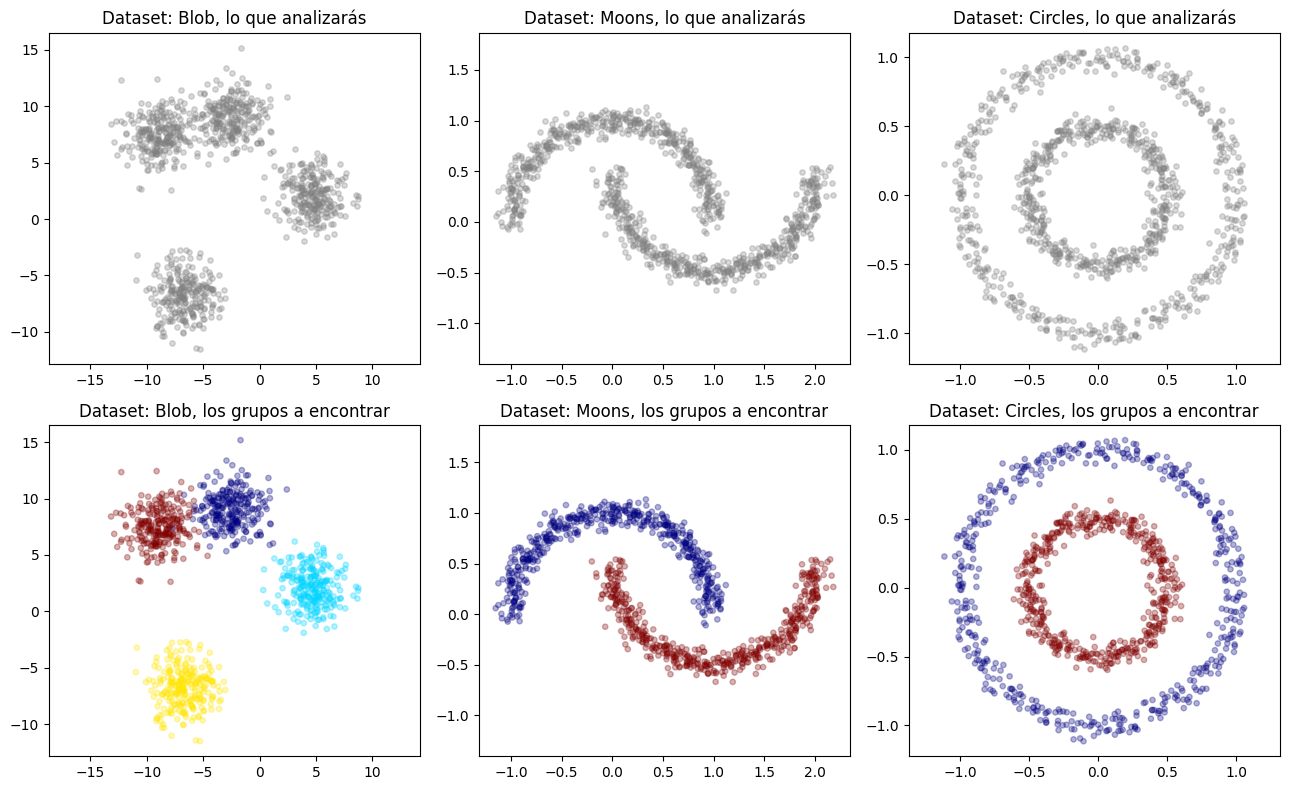

In [4]:
fig, axis = plt.subplots(2, 3, figsize=(13, 8))
for i, (X, y, ax, name) in enumerate(zip([X_blobs, X_moons, X_circles] * 2,
                                         [None] * 3 + [y_blobs, y_moons, y_circles],
                                         axis.reshape(-1),
                                         ['Blob', 'Moons', 'Circles'] * 2)):
    ax.set_title('Dataset: {}, '.format(name) + ('lo que analizarás' if i < 3 else 'los grupos a encontrar'))
    if y is not None:
        ax.scatter(X[:,0], X[:,1], s=15, c=y, alpha=.3, cmap='jet')
    else:
        ax.scatter(X[:,0], X[:,1], s=15, c='gray', alpha=.3, cmap='jet')
    ax.axis('equal')
plt.tight_layout()

### 1 a. K-means

En este apartado se pide probar el algoritmo *k-means* sobre los tres datasets presentados anteriormente ajustando con los parámetros adecuados y analizar sus resultados.

In [5]:
X, y = X_blobs, y_blobs

Para estimar el número de clusters a detectar por *k-means*. Una técnica para estimar $k$ es, como se explica en la teoría:
> Los criterios anteriores (minimización de distancias intra grupo o maximización de distancias inter grupo) pueden usarse para establecer un valor adecuado para el parámetro k. Valores k para los que ya no se consiguen mejoras significativas en la homogeneidad interna de los segmentos o la heterogeneidad entre segmentos distintos, deberían descartarse.

Lo que popularmente se conocer como *regla del codo*.

Primero es necesario calcular la suma de los errores cuadráticos ([*SSE*](https://bl.ocks.org/rpgove/0060ff3b656618e9136b)) que consiste en la suma de todos los errores (distancia de cada punto a su centroide asignado) al cuadrado.

$$SSE = \sum_{i=1}^{K} \sum_{x \in C_i} euclidean(x, c_i)^2$$

Donde $K$ es el número de clusters a buscar por *k-means*, $x \in C_i$ son los puntos que pertenecen a i-ésimo cluster, $c_i$ es el centroide del cluster $C_i$ (al que pertenece el punto $x$), y $euclidean$ es la [distancia euclídea](https://en.wikipedia.org/wiki/Euclidean_distance).

Este procedimiento realizado para cada posible valor $k$, resulta en una función monótona decreciente, donde el eje $x$ representa los distintos valores de $k$, y el eje $y$ el $SSE$. Intuitivamente se podrá observar un significativo descenso del error, que indicará el valor idóneo de $k$.

**Se pide realizar la representación gráfica de la regla del codo junto a su interpretación, utilizando la librería ```matplotlib``` y la implementación en scikit-learn de [*k-means*](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Blobs.
</div>

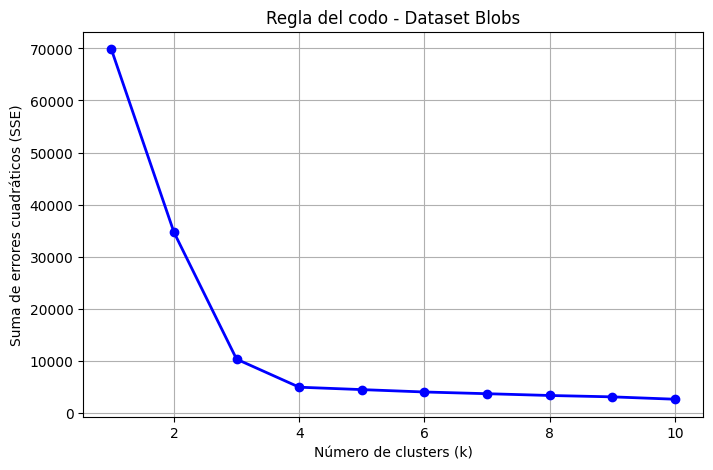

In [6]:
# =============================================================
# Cálculo y visualización de la regla del codo
# =============================================================

# Semilla para reproducibilidad
seed = 42

# Rango de posibles valores de k
k_values = range(1, 11)

# Lista para almacenar los valores SSE (inertia_ en sklearn)
sse = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_ = suma de distancias cuadradas (SSE)

# Representación gráfica
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Blobs')
plt.grid(True)
plt.savefig(r'../Visualizaciones/regla_del_codo_blobs.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La gráfica muestra la **Suma de Errores Cuadráticos (SSE)** en función del número de clusters ($k$). 

Se observa:  

- **Decrecimiento pronunciado**: Entre $k$ = 1 y $k$ = 4, el SSE disminuye drásticamente (de ~70,000 a ~5,000).
- **"Codo" en $k$ = 4:** A partir de $k$ = 4, la reducción del error se vuelve mucho más gradual y marginal.
- **Estabilización**: Desde $k$ = 5 en adelante, la mejora es prácticamente imperceptible.

Por lo tanto, el punto óptimo está claramente en **$k$ = 4**, ya que añadir más clusters no proporciona una reducción significativa del error. Este es el "codo" de la curva, donde se equilibra la complejidad del modelo con la calidad del agrupamiento.

Además de la regla del codo, se podría utilizar:

- **Método del Silhouette Score**: Mide qué tan bien está asignado cada punto a su cluster comparado con otros clusters (valores entre -1 y 1, siendo 1 óptimo). Es decir, que tan buena es la separación entre clústeres.
- **Método de Gap Statistic**: Compara la SSE observada con la esperada bajo una distribución de referencia aleatoria.

> Estos dos últimos métodos se pueden revisar más a fondo en: https://openaccess.uoc.edu/server/api/core/bitstreams/859ca353-d4f7-4448-a284-6454decfc950/content

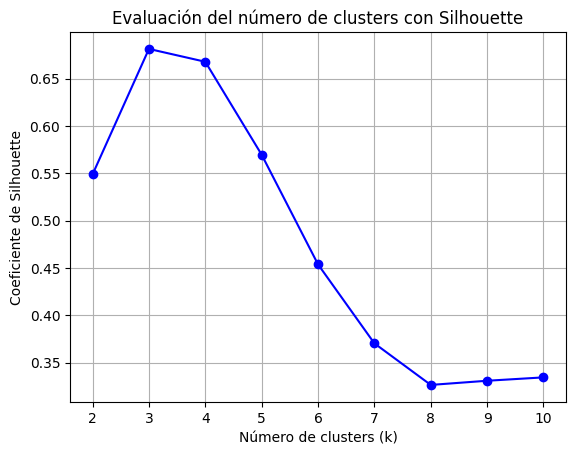

In [7]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(K, silhouette_scores, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Evaluación del número de clusters con Silhouette")
plt.grid(True)
plt.show()

El gráfico del Silhoutte Score en conjunto con el del método del codo, confirma que el número de clusters óptimos está entre 3 y 4.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Blobs.
</div>

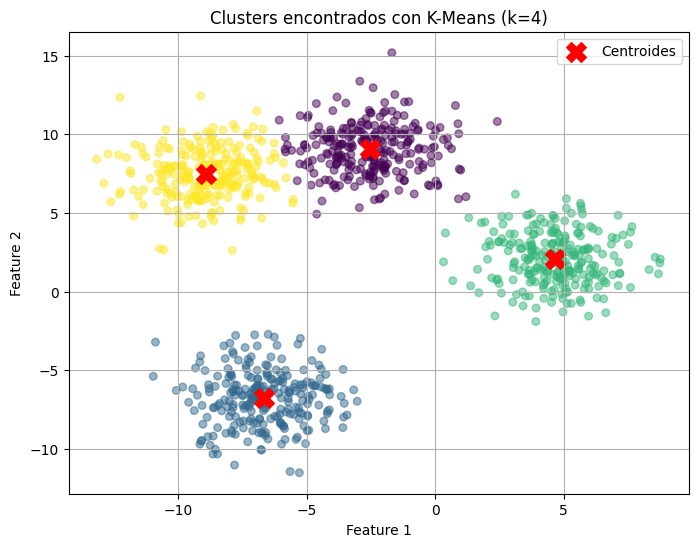

In [7]:
# ==========================================================
# Cálculo y visualización de los grupos
# ==========================================================

# Aplicamos KMeans con el k óptimo (4)
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)

# Obtenemos los centroides
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.savefig(r'../Visualizaciones/clusters_kmeans_blobs.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El algoritmo **K-Means** ha identificado **cuatro grupos claramente diferenciados**: uno amarillo al noroeste (~-9, 7), uno morado en la zona superior (~-2, 9), uno verde hacia el centro-derecha (~5, 2) y uno azul en el suroeste (~-7, -7). Los **centroides**, marcados con cruces rojas, se ubican de forma precisa en el corazón de cada agrupación.

El rendimiento de K-Means en este caso es **excelente**. Los grupos están bien separados, con fronteras limpias y sin solapamientos. Su forma casi esférica encaja perfectamente con el supuesto de distancias euclidianas que utiliza el algoritmo. Además, los clusters tienen tamaños y densidades similares, lo que evita sesgos hacia grupos más grandes o más densos.

Esto no es casualidad: el dataset procede de `make_blobs`, un generador diseñado para producir clusters gaussianos bien definidos, justo el escenario ideal para K-Means. En cambio, en datos reales —donde los grupos pueden tener formas irregulares, densidades desiguales o ruido— sería más adecuado recurrir a métodos como **DBSCAN** o el **clustering jerárquico**.

In [8]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Moons.
</div>

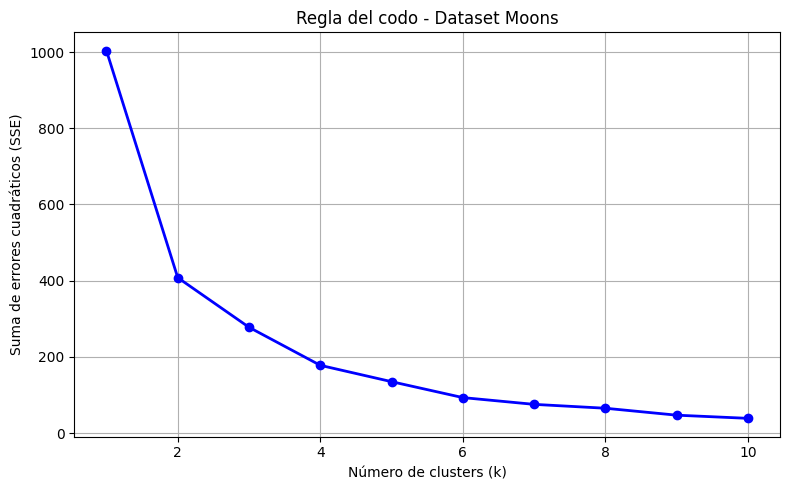

In [9]:
# ==========================================================
# Regla del codo - Dataset Moons
# ==========================================================

# Rango de valores posibles para k
k_values = range(1, 11)
sse = []

# Calcular SSE para cada k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Moons')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/regla_del_codo_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La gráfica revela un patrón muy distinto al observado en el caso de *blobs*. El **SSE** desciende de manera suave y continua, pasando de unos ~1000 con (k = 1) a cerca de 40 con (k = 10), **sin mostrar un codo claro** que marque un punto de mejora significativa. Esa falta de inflexión hace difícil decidir el número óptimo de clusters: valores como (k = 2), (k = 3) o (k = 4) podrían parecer razonables, pero ninguno destaca de forma evidente. La mayor parte de la reducción ocurre antes de (k = 4), y después las mejoras son marginales.

Esta ausencia de un “codo” pronunciado sugiere que **K-Means no se ajusta bien a los datos**, ya que la estructura subyacente no parece esférica ni convexa. En este tipo de distribuciones, métricas como el **Silhouette Score** probablemente serían bajas, confirmando que el algoritmo no captura bien la forma de los grupos. Una simple visualización en 2D dejaría ver que los datos adoptan una forma de “lunas” o curvas, claramente no compatible con los supuestos de K-Means.

En resumen, los resultados del gráfico indican que **este dataset requiere otro enfoque de clustering**, y que el criterio del codo no es útil aquí. Métodos como **DBSCAN** o el **clustering jerárquico** serían alternativas más adecuadas.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Moons.
</div>

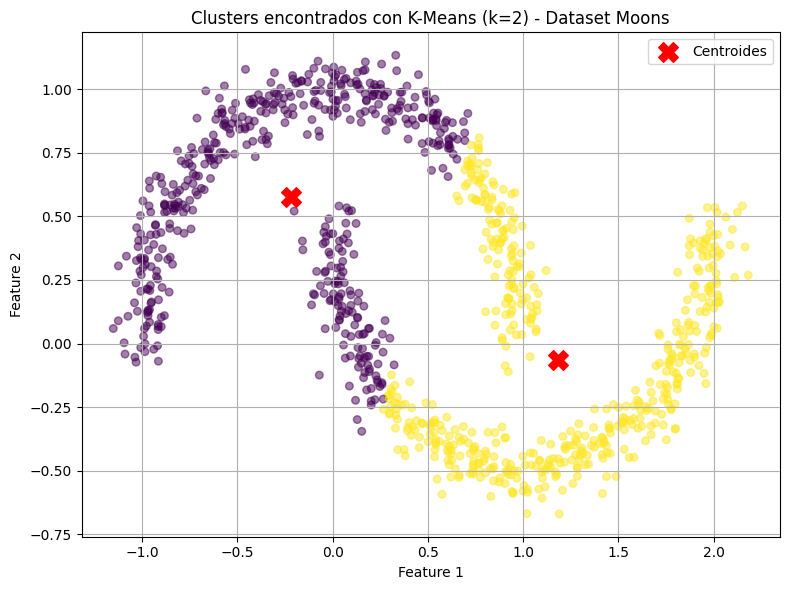

In [10]:
# ==========================================================
# Visualización de clusters - Dataset Moons
# ==========================================================

# Suponemos que la regla del codo sugiere k=2 (aunque K-means no agrupa bien este dataset)
k_optimo = 2

kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=2) - Dataset Moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/clusters_kmeans_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El resultado de **K-Means con (k = 2)** es claramente **insatisfactorio**. El algoritmo ha dividido el conjunto en dos grupos artificiales: un **cluster morado** que combina la parte superior de ambas lunas junto con parte de la izquierda, y un **cluster amarillo** que reúne la zona inferior y derecha. Los centroides, ubicados cerca de (~-0.3, 0.6) y (~1.2, -0.1), trazan una **frontera casi vertical** que corta las dos lunas en lugar de seguir su forma natural.

La visualización deja clara la discrepancia: los datos tienen una estructura real compuesta por **dos lunas entrelazadas**, curvas y cóncavas, mientras que K-Means impone una separación lineal que no respeta esa geometría.

Las causas están en las **limitaciones inherentes del algoritmo**. K-Means parte del supuesto de que los clusters son **convexos y aproximadamente esféricos**, algo que las lunas no cumplen. Además, utiliza la **distancia euclidiana**, que mide en línea recta la cercanía a los centroides. En este contexto, los puntos situados en el centro del espacio quedan equidistantes de ambas lunas, lo que provoca asignaciones arbitrarias y una pérdida total de la **conectividad topológica** entre los datos.

A esto se suma que las **fronteras de decisión** de K-Means son siempre **lineales**, lo que lo incapacita para separar estructuras no lineales como las lunas. Por último, al optimizar en función de la distancia al centroide, el algoritmo tiende a crear grupos esféricos y de tamaño similar, algo incompatible con la forma alargada y curvada de este dataset.

> Fuente [Tecnicas de clustering](https://openaccess.uoc.edu/server/api/core/bitstreams/859ca353-d4f7-4448-a284-6454decfc950/content)

In [11]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Circles.
</div>

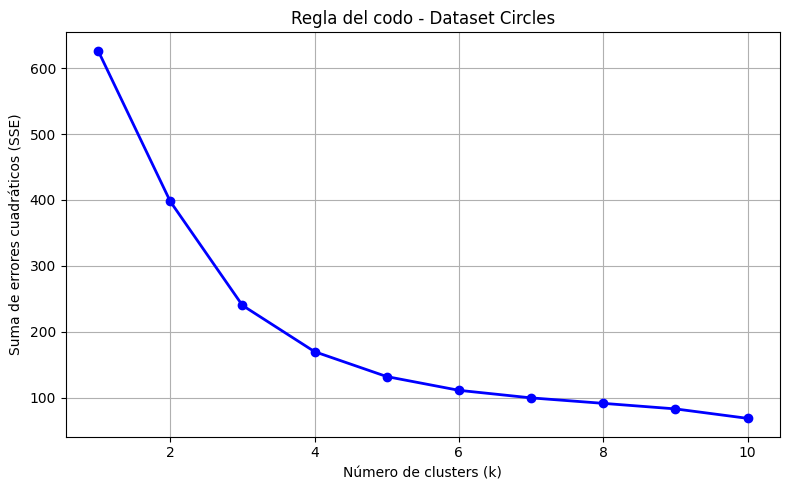

In [12]:
# ==========================================================
# Regla del codo - Dataset Circles
# ==========================================================

# Rango de valores posibles para k
k_values = range(1, 11)
sse = []

# Calcular SSE (inercia) para cada k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X_circles)
    sse.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Circles')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/regla_del_codo_circles.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La **curva del codo** muestra un descenso **suave y continuo** del SSE, que pasa de unos ~625 con (k = 1) a unos ~65 con (k = 10). No aparece un codo claro que marque un punto de inflexión, solo una ligera disminución de la pendiente alrededor de (k = 2) o (k = 3), tras la cual la reducción sigue siendo notable incluso hasta (k = 7) u (8). Ese comportamiento persistente es una señal de que el modelo **no logra capturar una estructura natural** en los datos.

Si nos guiáramos únicamente por la gráfica, (k = 2) podría parecer una elección razonable —coherente con la idea de un círculo interior y otro exterior—, pero el patrón de la curva sugiere que **K-Means está forzando una partición artificial** más que reflejando grupos reales.

Para validar esto, sería útil complementar el análisis con otros métodos. El **Silhouette Score** probablemente mostraría valores bajos para (k = 2), indicando solapamientos y clusters mal definidos bajo la métrica euclidiana. Además, una **visualización 2D** bastaría para ver que los datos forman **círculos concéntricos**, una estructura no convexa y, por tanto, poco adecuada para K-Means.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Circles.
</div>

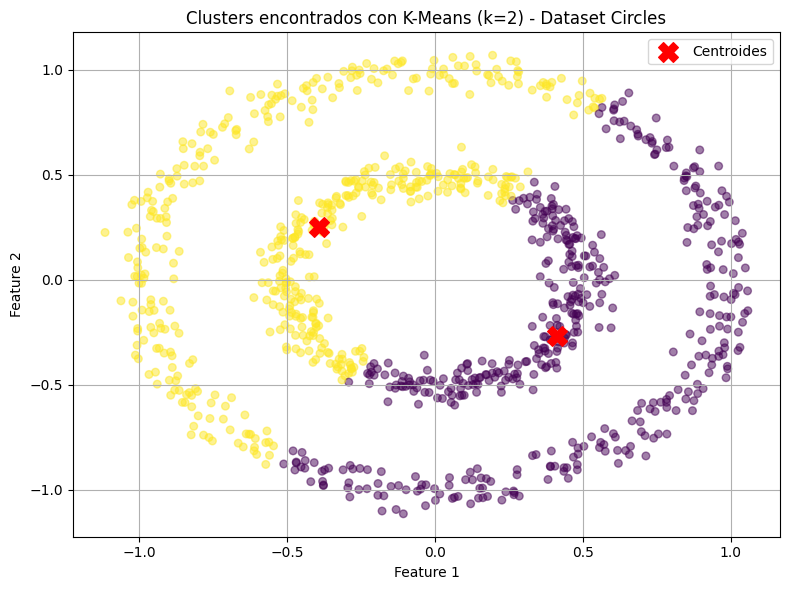

In [13]:
# ==========================================================
# Visualización de clusters - Dataset Circles
# ==========================================================

# La regla del codo podría sugerir k=2 (pero no representa bien los círculos)
k_optimo = 2

kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=2) - Dataset Circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/clusters_kmeans_circles.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El resultado de **K-Means con (k = 2)** es **claramente erróneo**. El algoritmo ha dividido los datos en dos mitades casi simétricas: un **cluster amarillo** a la izquierda y un **cluster morado** a la derecha. Los centroides, situados cerca de (-0.4, 0.25) y (0.4, -0.25), trazan una **frontera vertical** que corta ambos círculos por la mitad. En otras palabras, el modelo ha ignorado por completo la estructura real del conjunto: **un círculo interior pequeño y un anillo exterior concéntrico**.

Este es uno de los escenarios más desfavorables para K-Means. Su problema principal es **geométrico**: al basarse en la **distancia euclidiana a los centroides**, el algoritmo no puede distinguir correctamente entre puntos de un círculo interior y de uno exterior. Muchos puntos quedan equidistantes de ambos centroides, lo que hace imposible una separación coherente de los círculos.

Además, K-Means solo puede crear **fronteras lineales**, lo que lo incapacita para dividir estructuras **no convexas y anidadas** como los círculos concéntricos. Sus centroides se ubican en el centro de masa de los puntos asignados, optimizando el error cuadrático (SSE), pero sin reflejar la verdadera organización espacial.

A esto se suma una **falsa simetría**: la distribución radial hace que cualquier línea que pase por el centro produzca un error similar, por lo que K-Means termina convergiendo a una partición arbitraria determinada por la inicialización.


### 1 b. Algoritmos basados en densidad: DBScan

En este apartado se pide aplicar clustering por densidad como [DBSCAN](https://en.wikipedia.org/wiki/DBSCAN) a los datasets anteriores para detectar los grupos subyacentes.

In [14]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="http://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html">DBSCAN en scikit-learn</a> jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Blobs.
</div>

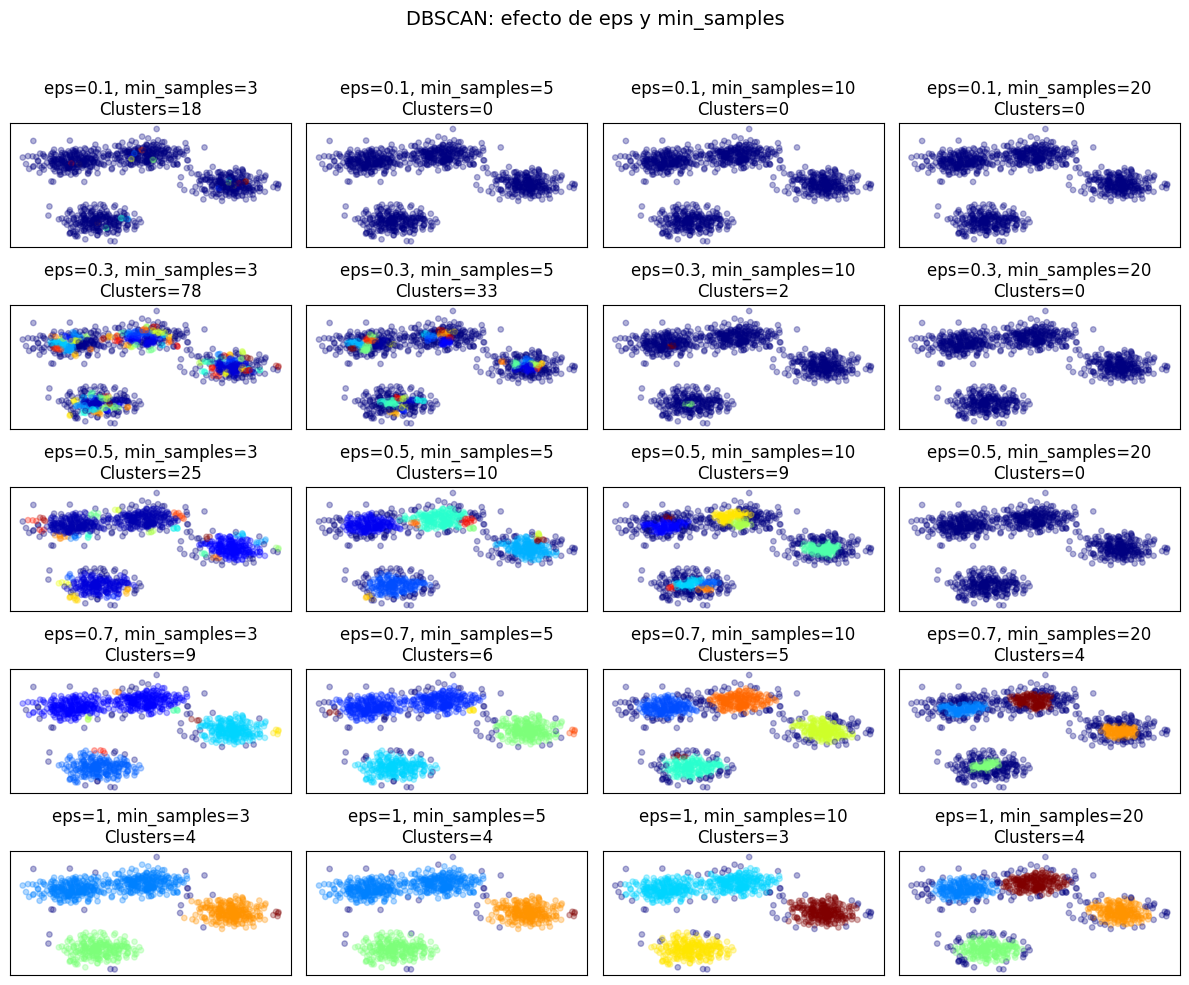

In [8]:
# ==========================================================
# DBSCAN - Dataset Blobs
# ==========================================================

# Aplicamos DBSCAN con parámetros personalizados
eps_values = [0.1, 0.3, 0.5, 0.7, 1]
min_samples_values = [3, 5, 10, 20]

# Visualizamos el efecto sobre la clsuterinzacion en combinaciones de parametros
fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(12, 10))
fig.suptitle("DBSCAN: efecto de eps y min_samples", fontsize=14)

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        axes[i, j].scatter(X[:, 0], X[:, 1], c=labels, cmap="jet", s=15, alpha=0.3)
        axes[i, j].set_title(f"eps={eps}, min_samples={min_s}\nClusters={n_clusters}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(r'../Visualizaciones/dbscan_blobs.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El resultado  de comprobar como afectanlos parámetros `eps` (radio de vecindad) y `min_samples` (mínimo número de puntos para formar un núcleo) al comportamiento del algoritmo DBSCAN es muy ilustrativo. Con valores bajos de `eps` (0.1 o 0.3), el algoritmo apenas logra conectar puntos entre sí: la mayoría quedan etiquetados como ruido y, en algunos casos, aparecen decenas de pequeños micro-clusters que no tienen sentido real. Es decir, el radio es tan pequeño que DBSCAN interpreta cada punto o pequeño grupo como una estructura independiente.

Cuando aumento `eps` a valores intermedios (0.5–0.7), los resultados mejoran notablemente. Aquí el algoritmo empieza a captar la verdadera estructura de los datos: los puntos dentro de cada blob se conectan correctamente y los clusters se definen de forma más coherente. Aun así, se observa que si `min_samples` es demasiado bajo, el modelo tiende a dividir un mismo grupo en varios sub-clusters; al elevarlo, la segmentación se estabiliza y aparecen los cuatro grupos originales.

Por último, al llegar a `eps=1`, el radio de vecindad se vuelve tan amplio que diferentes blobs comienzan a fusionarse. DBSCAN deja de distinguir entre grupos cercanos y acaba mezclando regiones que deberían estar separadas, reduciendo el número de clusters detectados.

En conjunto, el experimento demuestra claramente la sensibilidad de DBSCAN a la elección de sus parámetros: un `eps` demasiado pequeño fragmenta los datos, y uno demasiado grande los fusiona. La combinación de `eps` entre 0.5 y 0.7, con un `min_samples` moderado, ofrece el equilibrio adecuado para capturar las cuatro agrupaciones presentes en el dataset.


In [10]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Moons.
</div>

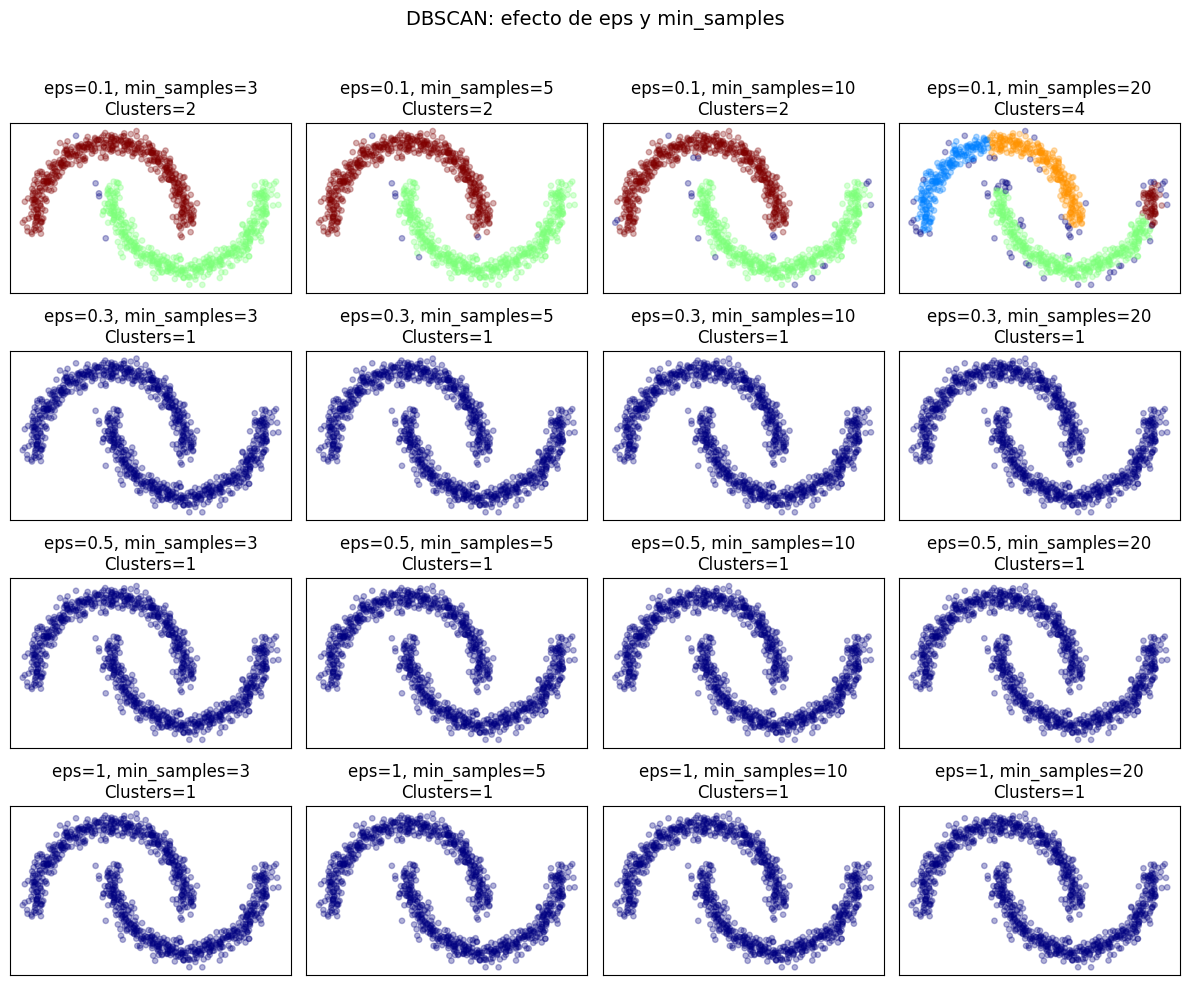

In [11]:
# ==========================================================
# DBSCAN - Dataset Moons
# ==========================================================

# Aplicamos DBSCAN con parámetros personalizados
eps_values = [0.1, 0.3, 0.5, 1]
min_samples_values = [3, 5, 10, 20]

# Ajustar DBSCAN y visualizar el efecto sobre la clusterización en combinaciones de parámetros
fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(12, 10))
fig.suptitle("DBSCAN: efecto de eps y min_samples", fontsize=14)

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        axes[i, j].scatter(X[:, 0], X[:, 1], c=labels, cmap="jet", s=15, alpha=0.3)
        axes[i, j].set_title(f"eps={eps}, min_samples={min_s}\nClusters={n_clusters}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(r'../Visualizaciones/dbscan_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

Con valores bajos de `eps` (0.1), el algoritmo distingue bien las dos lunas principales cuando `min_samples` es pequeño. Sin embargo, al aumentar `min_samples`, algunos puntos dejan de cumplir el criterio de densidad mínima, y DBSCAN empieza a fragmentar las lunas en varias partes, generando más clusters de los esperados.

Cuando incremento `eps` a 0.3 o más, la situación cambia drásticamente: el radio de vecindad se vuelve tan amplio que los dos arcos acaban conectándose. El resultado es que DBSCAN agrupa prácticamente todos los puntos en un solo cluster, sin distinguir las dos lunas. A partir de ese punto, aumentar aún más `eps` o `min_samples` apenas modifica el resultado: el modelo interpreta todo el conjunto como una única región densa.

Este comportamiento evidencia que, en estructuras no convexas, DBSCAN necesita un equilibrio muy fino en sus parámetros. Un `eps` pequeño permite captar la curvatura y separar las lunas, pero corre el riesgo de generar ruido o fragmentación; mientras que un `eps` grande tiende a unir regiones próximas aunque pertenezcan a clusters distintos. En este caso concreto, valores cercanos a `eps = 0.1` y `min_samples` bajos son los que mejor reflejan la verdadera estructura del dataset.

In [12]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Circles.
</div>

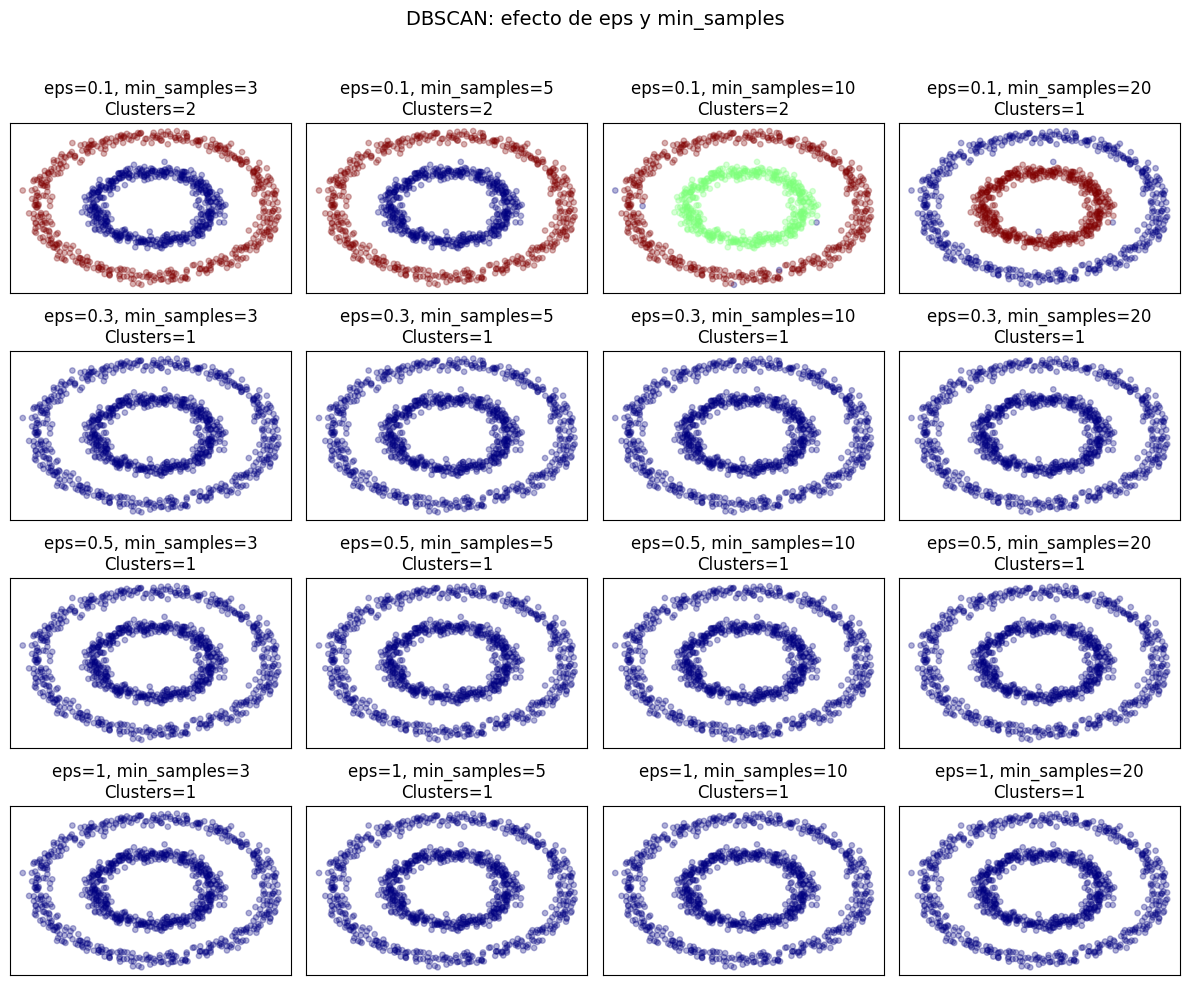

In [13]:
# ==========================================================
# DBSCAN - Dataset Circles
# ==========================================================
# Aplicamos DBSCAN con parámetros personalizados
eps_values = [0.1, 0.3, 0.5, 1]
min_samples_values = [3, 5, 10, 20]

# Ajustar DBSCAN y visualizar el efecto sobre la clusterización en combinaciones de parámetros
fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(12, 10))
fig.suptitle("DBSCAN: efecto de eps y min_samples", fontsize=14)

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        axes[i, j].scatter(X[:, 0], X[:, 1], c=labels, cmap="jet", s=15, alpha=0.3)
        axes[i, j].set_title(f"eps={eps}, min_samples={min_s}\nClusters={n_clusters}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(r'../Visualizaciones/dbscan_circles.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El comportamiento de DBSCAN aquí resulta especialmente sensible al valor de `eps`. Con `eps=0.1`, el radio de vecindad es suficientemente pequeño como para respetar la separación entre los dos círculos, y el algoritmo logra distinguir correctamente ambos clusters cuando el parámetro `min_samples` es bajo. Sin embargo, al aumentar `min_samples`, se exige una mayor densidad de puntos por núcleo, y el resultado es una fragmentación en pequeñas porciones de los anillos, con la aparición de varios clusters secundarios.

Al incrementar `eps` a valores intermedios (0.3–0.5), las regiones de vecindad se solapan cada vez más entre los dos anillos. Esto provoca que DBSCAN los acabe conectando en una sola estructura continua, de modo que prácticamente todo el conjunto se agrupa como un único cluster. A partir de `eps=1`, el efecto se consolida: el modelo ya no distingue ninguna de las formas circulares originales.

En resumen, el experimento muestra que DBSCAN puede identificar correctamente los dos círculos solo con radios de vecindad muy pequeños y un umbral de densidad bajo. 

### 1 c. Algoritmos jerárquicos

En este apartado se pide visualizar mediante un [dendrograma](https://en.wikipedia.org/wiki/Dendrogram) la construcción progresiva de los grupos mediante un algoritmo jerárquico aglomerativo (estrategia *bottom-up*). Con ello se pretende encontrar un método gráfico para entender el comportamiento del algoritmo y encontrar los *clusters* deseados en cada dataset.

In [26]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Blobs.<br>
Puedes importar las librerías necesarias para ello.
</div>

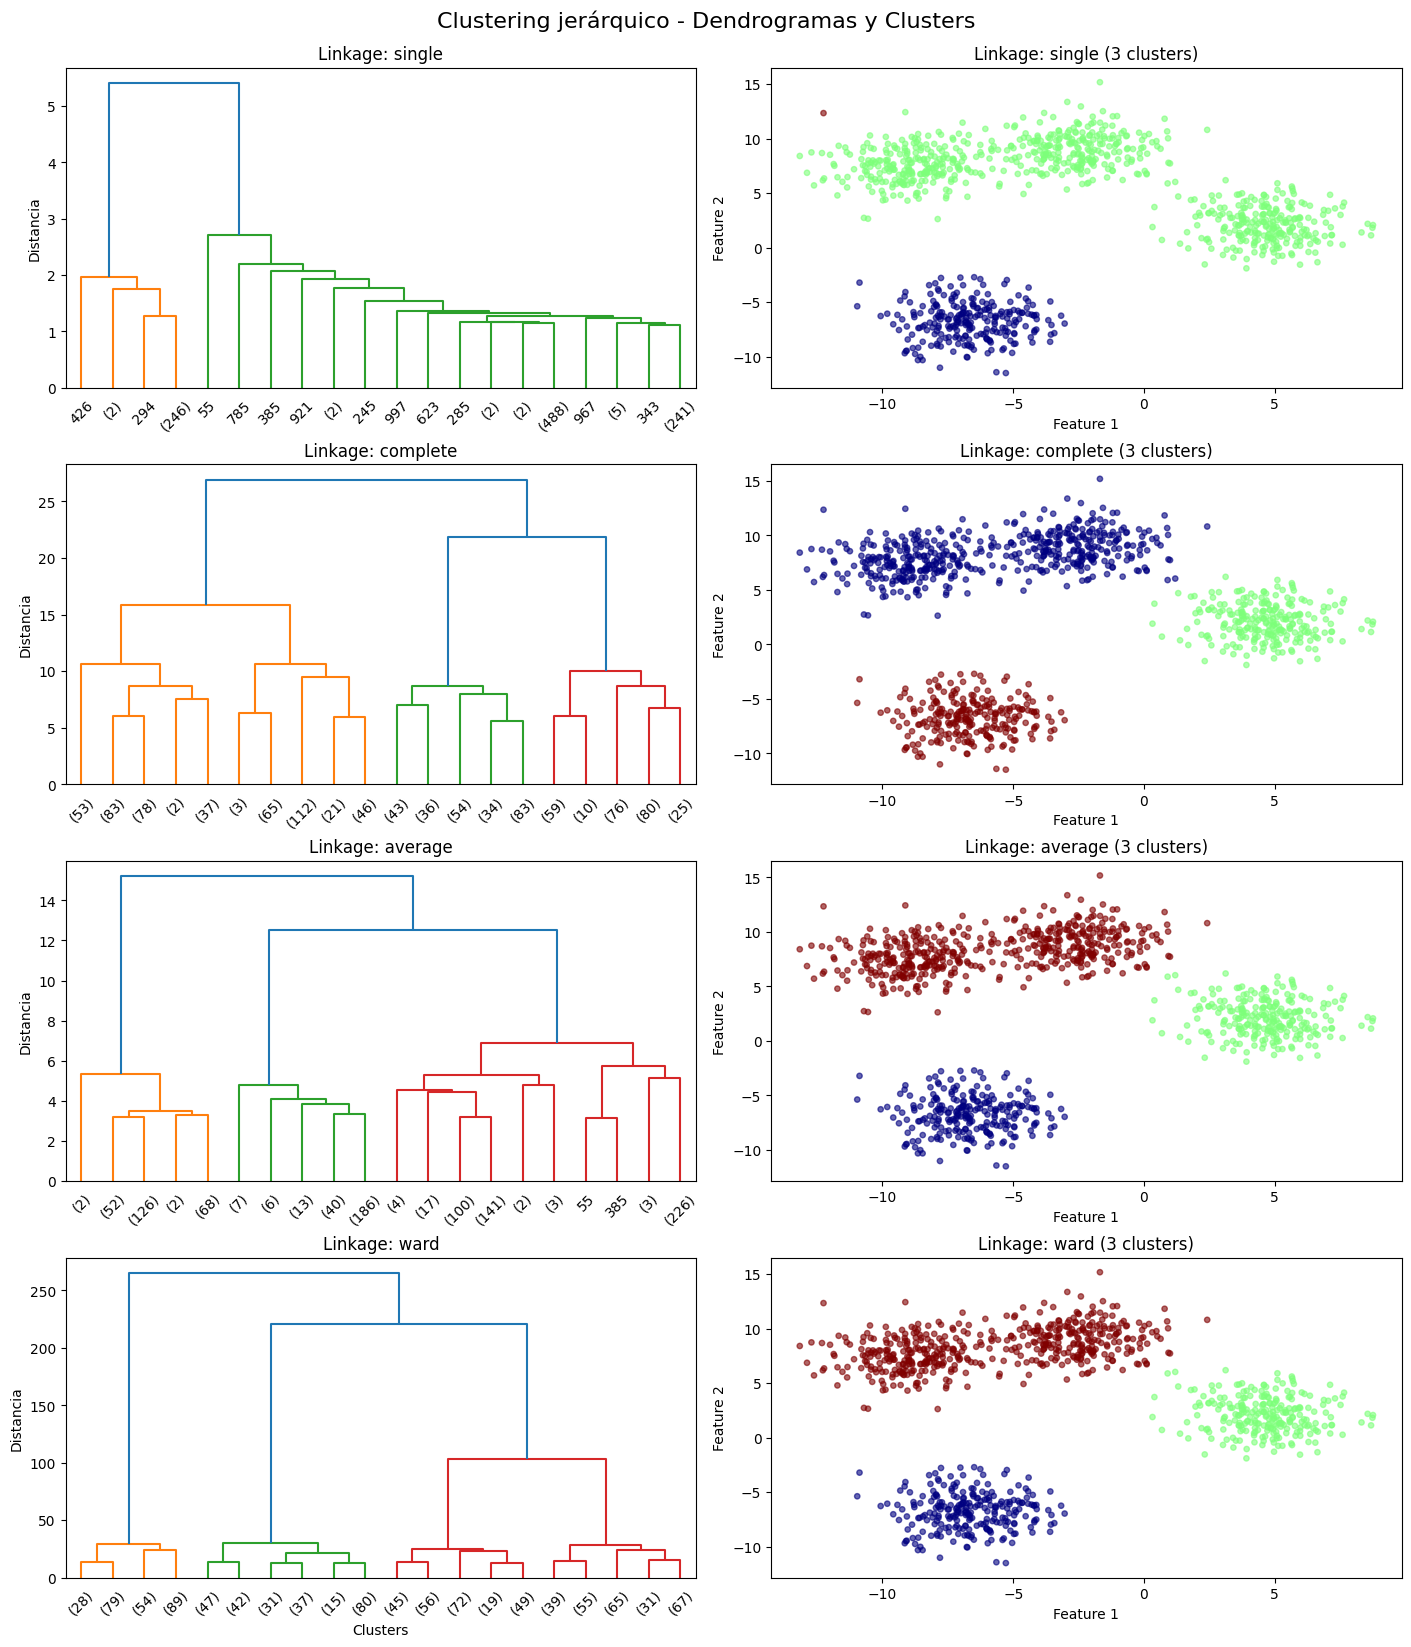

In [27]:
# ==========================================================
# Clustering jerárquico - Dataset Blobs (comparativa conjunta)
# ==========================================================

linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(len(linkage_methods), 2, figsize=(14, 16), constrained_layout=True)
fig.suptitle("Clustering jerárquico - Dendrogramas y Clusters", fontsize=16, y=1.02)

for i, method in enumerate(linkage_methods):
    # --- Dendrograma ---
    Z = linkage(X, method=method)
    dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=10., ax=axes[i, 0])
    axes[i, 0].set_title(f"Linkage: {method}", fontsize=12)
    axes[i, 0].set_ylabel("Distancia")
    if i == len(linkage_methods) - 1:
        axes[i, 0].set_xlabel("Clusters")

    # --- Clusters ---
    clusters = fcluster(Z, 3, criterion="maxclust")
    axes[i, 1].scatter(X[:, 0], X[:, 1], c=clusters, cmap="jet", s=15, alpha=0.6)
    axes[i, 1].set_title(f"Linkage: {method} (3 clusters)", fontsize=12)
    axes[i, 1].set_xlabel("Feature 1")
    axes[i, 1].set_ylabel("Feature 2")

plt.savefig(r'../Visualizaciones/linkage_dendrogramas_y_clusters_blobs.png', dpi=300, bbox_inches='tight')
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

El análisis de los distintos **criterios de enlace (*linkage*)** muestra diferencias claras tanto en la estructura de los dendrogramas como en la calidad de los clusters obtenidos.

- **Average Linkage:**
  - El dendrograma obtenido con *average linkage* muestra una estructura clara y equilibrada, con cuatro ramas principales bien diferenciadas (colores naranja, verde, rojo y azul en los niveles bajos). Las fusiones iniciales se producen a distancias relativamente pequeñas, entre 3 y 5, mientras que la unión de los cuatro grupos principales ocurre a distancias mucho mayores, en torno a 12–15.
Este salto o “gap” entre niveles indica una separación natural en cuatro grupos bien definidos.

- **Complete Linkage:**
  - El dendrograma de *complete linkage* presenta una estructura algo más desbalanceada que la del método anterior. Se observan dos ramas principales que se fusionan a una distancia muy alta (alrededor de 26), y dentro de cada una hay subdivisiones que ocurren a distancias medias (entre 8 y 15).
  Las fusiones finales muestran una mayor dispersión en las alturas del dendrograma, reflejando cierta asimetría en la estructura jerárquica.

- **Single Linkage**

  - En este caso, el dendrograma revela un problema claro: una estructura extremadamente desbalanceada provocada por el conocido *[efecto cadena](https://openaccess.uoc.edu/server/api/core/bitstreams/6a121978-e877-4f5d-a76c-b6ff0138f8d1/content)* (*chaining*). La primera gran fusión ocurre a distancia muy baja (~2), y a partir de ahí aparece una rama azul dominante que crece progresivamente a medida que se van uniendo los puntos. No existe una separación clara en cuatro niveles distintos, y el dendrograma pierde legibilidad.

-  **Ward Linkage**
   - El dendrograma de *Ward linkage* es el más equilibrado y fácil de interpretar. Se observan cuatro ramas principales claramente separadas, con fusiones iniciales a distancias pequeñas (20–30) y un salto muy pronunciado antes de la fusión de los grupos principales, que se produce entre 100 y 250.
   Este gran salto facilita enormemente la identificación del punto de corte óptimo en el dendrograma.

Por lo tanto, **el método que mejor se comporta en este dataset es Ward linkage**. Su dendrograma es el más interpretable, con un salto muy claro entre fusiones internas y externas (20–30 frente a 100–250), lo que permite determinar fácilmente el número óptimo de clusters. Además, este criterio es coherente con la geometría de los datos: los *blobs* son aproximadamente esféricos y están bien separados, justo el tipo de estructura que *Ward* busca al minimizar la varianza interna.

In [20]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Moons.<br>
Puedes importar las librerías necesarias para ello.
</div>

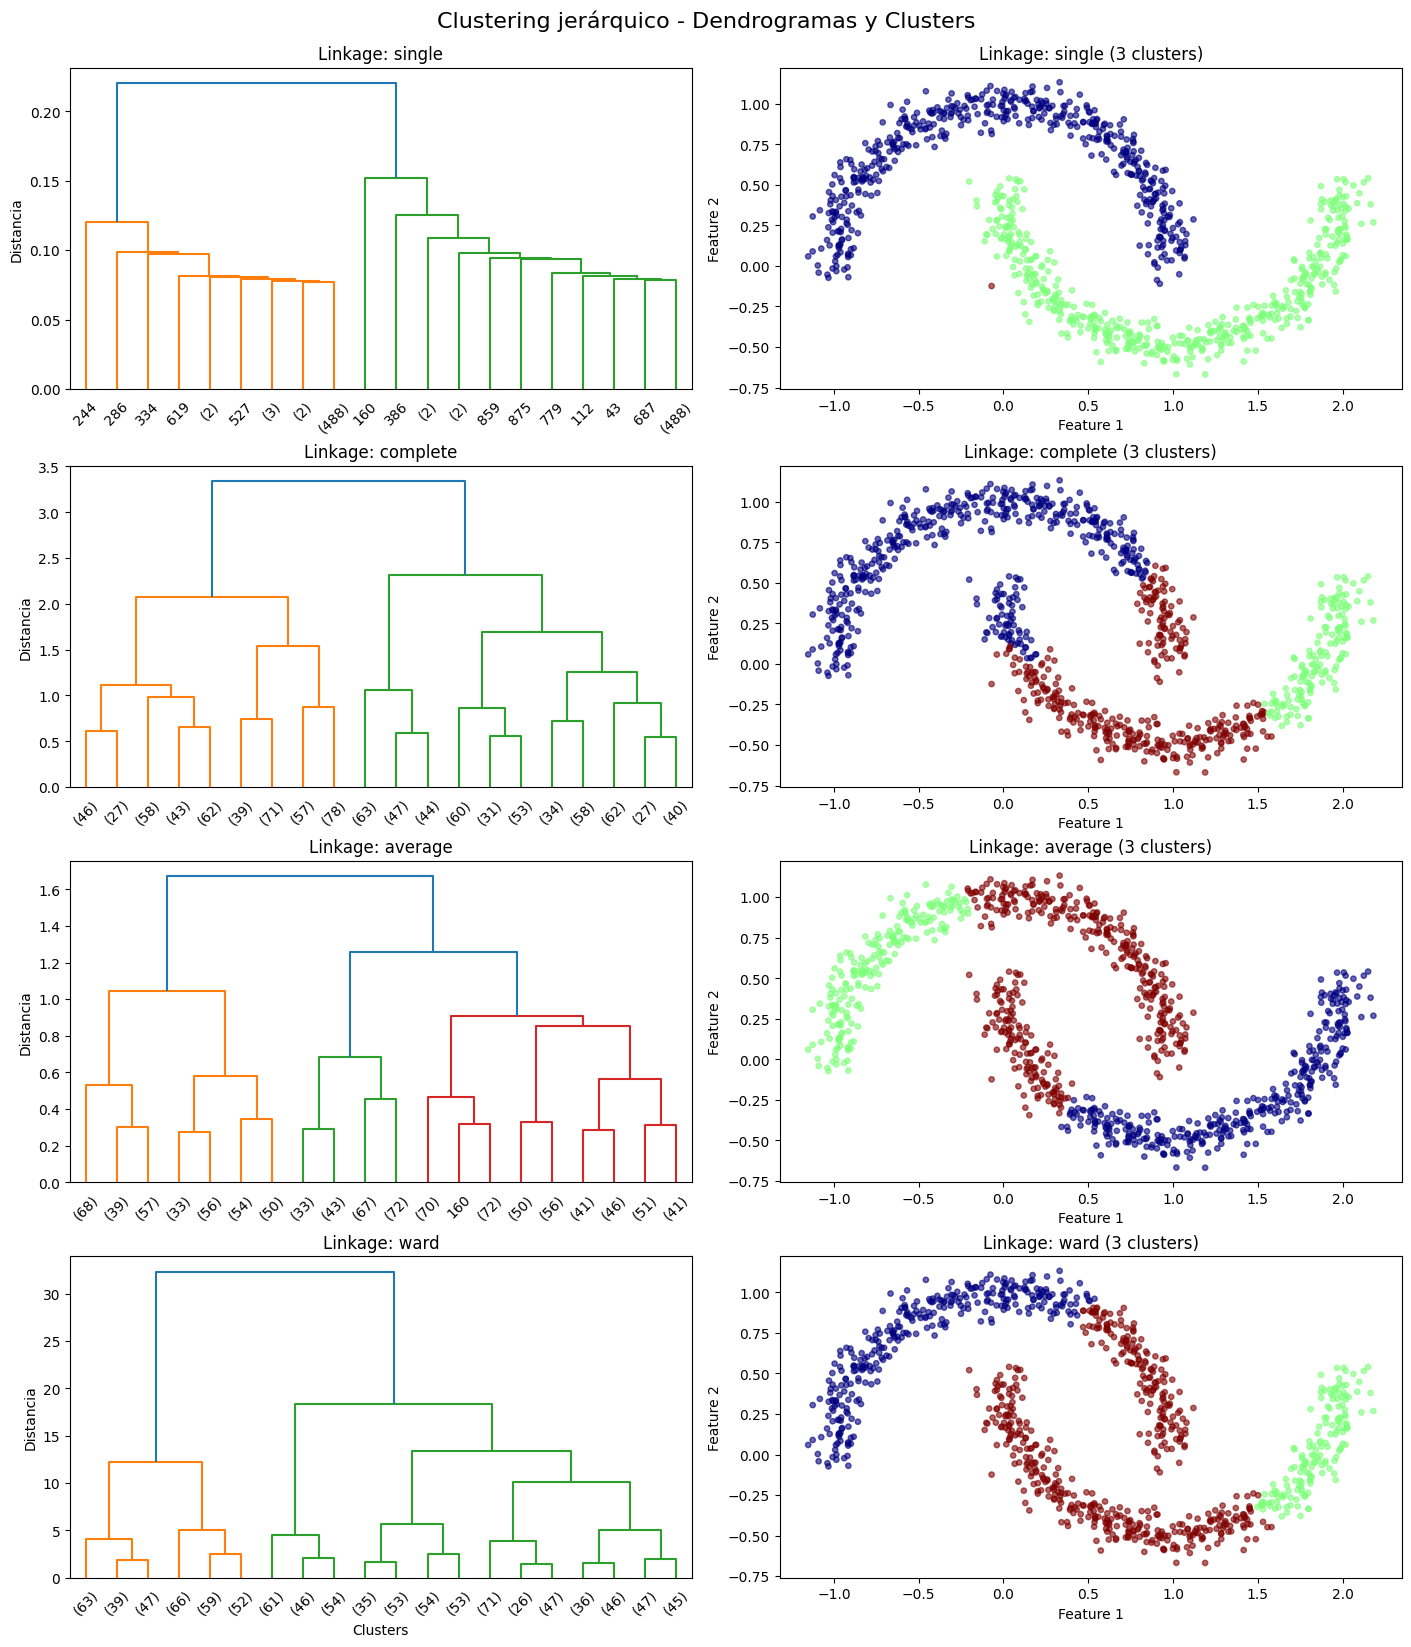

In [21]:
# ==========================================================
# Clustering jerárquico - Dataset moons
# ==========================================================

linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(len(linkage_methods), 2, figsize=(14, 16), constrained_layout=True)
fig.suptitle("Clustering jerárquico - Dendrogramas y Clusters", fontsize=16, y=1.02)

for i, method in enumerate(linkage_methods):
    # --- Dendrograma ---
    Z = linkage(X, method=method)
    dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=10., ax=axes[i, 0])
    axes[i, 0].set_title(f"Linkage: {method}", fontsize=12)
    axes[i, 0].set_ylabel("Distancia")
    if i == len(linkage_methods) - 1:
        axes[i, 0].set_xlabel("Clusters")

    # --- Clusters ---
    clusters = fcluster(Z, 3, criterion="maxclust")
    axes[i, 1].scatter(X[:, 0], X[:, 1], c=clusters, cmap="jet", s=15, alpha=0.6)
    axes[i, 1].set_title(f"Linkage: {method} (3 clusters)", fontsize=12)
    axes[i, 1].set_xlabel("Feature 1")
    axes[i, 1].set_ylabel("Feature 2")

plt.savefig(r'../Visualizaciones/linkage_dendrogramas_y_clusters_moons.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

Al aplicar los distintos criterios de enlace sobre el dataset *Moons*, los resultados muestran comportamientos muy contrastados según la forma de las lunas y la manera en que cada algoritmo calcula las distancias entre clusters.

- **Average Linkage:** 
  - El dendrograma muestra una estructura relativamente equilibrada, con fusiones progresivas desde distancias bajas hasta un salto final moderado. Aun así, el clustering **no logra reflejar correctamente la estructura en forma de lunas**, ya que las divisiones tienden a ser verticales o diagonales, dando lugar a varios grupos pequeños en lugar de las dos medias lunas esperadas. Esto ocurre porque el método **promedia las distancias** entre todos los puntos de los clusters, y en este dataset las lunas están separadas más claramente en dirección horizontal. El algoritmo, al centrarse en distancias promedio, prefiere dividir verticalmente, donde las separaciones medias son mayores, antes que seguir las curvas naturales.

- **Complete Linkage:** 
  - El dendrograma se vuelve más desbalanceado y las fusiones finales ocurren a distancias mucho más altas. Este método es especialmente sensible a la elongación de los grupos ([es sensible a los valores outliers](https://openaccess.uoc.edu/server/api/core/bitstreams/6a121978-e877-4f5d-a76c-b6ff0138f8d1/content)), ya que **se basa en la distancia máxima entre puntos**. Al intentar minimizar el diámetro de los clusters, tiende a cortar el espacio en franjas verticales que atraviesan ambas lunas, produciendo resultados completamente incorrectos. En lugar de identificar las dos formas curvas, el algoritmo crea divisiones artificiales que reducen el tamaño máximo de cada grupo, sacrificando la coherencia estructural.

- **Single Linkage** 
  - Por el contrario *single linkage* muestra un dendrograma extremadamente desbalanceado (efecto *chaining*), pero esta vez ese problema se convierte en una ventaja. Aunque la estructura parece caótica, el clustering resultante es casi perfecto, observando como cada luna queda representada como una cadena continua de puntos conectados. Esto es debido a que se fusionan grupos si existe al menos un par de puntos cercanos, lo que encaja de forma ideal con las lunas, ya que dentro de cada una hay una densa red de vecinos próximos, mientras que entre ellas existe un pequeño pero claro hueco. Así, el algoritmo sigue la conectividad de las curvas y logra una separación natural, con solo unos pocos puntos ambiguos.

- **Ward Linkage:** 
  - Ofrece un resultado algo mejor que *Complete*, pero sigue siendo **inadecuado para este tipo de estructura**. Su dendrograma presenta una gran rama dominante y un salto final muy alto, lo que refleja fusiones tardías y poco coherentes. Al **minimizar la varianza dentro de cada grupo**, *Ward* favorece clusters compactos y aproximadamente esféricos, una suposición que las lunas violan completamente. De modo que como las formas son cóncavas, los centroides caen fuera de las lunas, lo que confunde la asignación de puntos y provoca cortes diagonales que dividen los arcos naturales en segmentos artificiales.

Por lo tanto, el método que mejor se adapta al dataset *Moons* es claramente **Single Linkage**. Su sensibilidad a la conectividad local le permite seguir las formas curvadas sin imponer una estructura convexa ni depender de medidas globales de distancia. Volver a resaltar que, lo que en otros contextos sería una debilidad (la tendencia a encadenar puntos sucesivos) aquí se convierte en la clave para detectar las lunas con precisión. En cambio, *Complete* y *Ward* fallan al intentar imponer geometrías compactas, mientras que *Average* se queda en un punto intermedio..

In [24]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Circles.<br>
Puedes importar las librerías necesarias para ello.
</div>

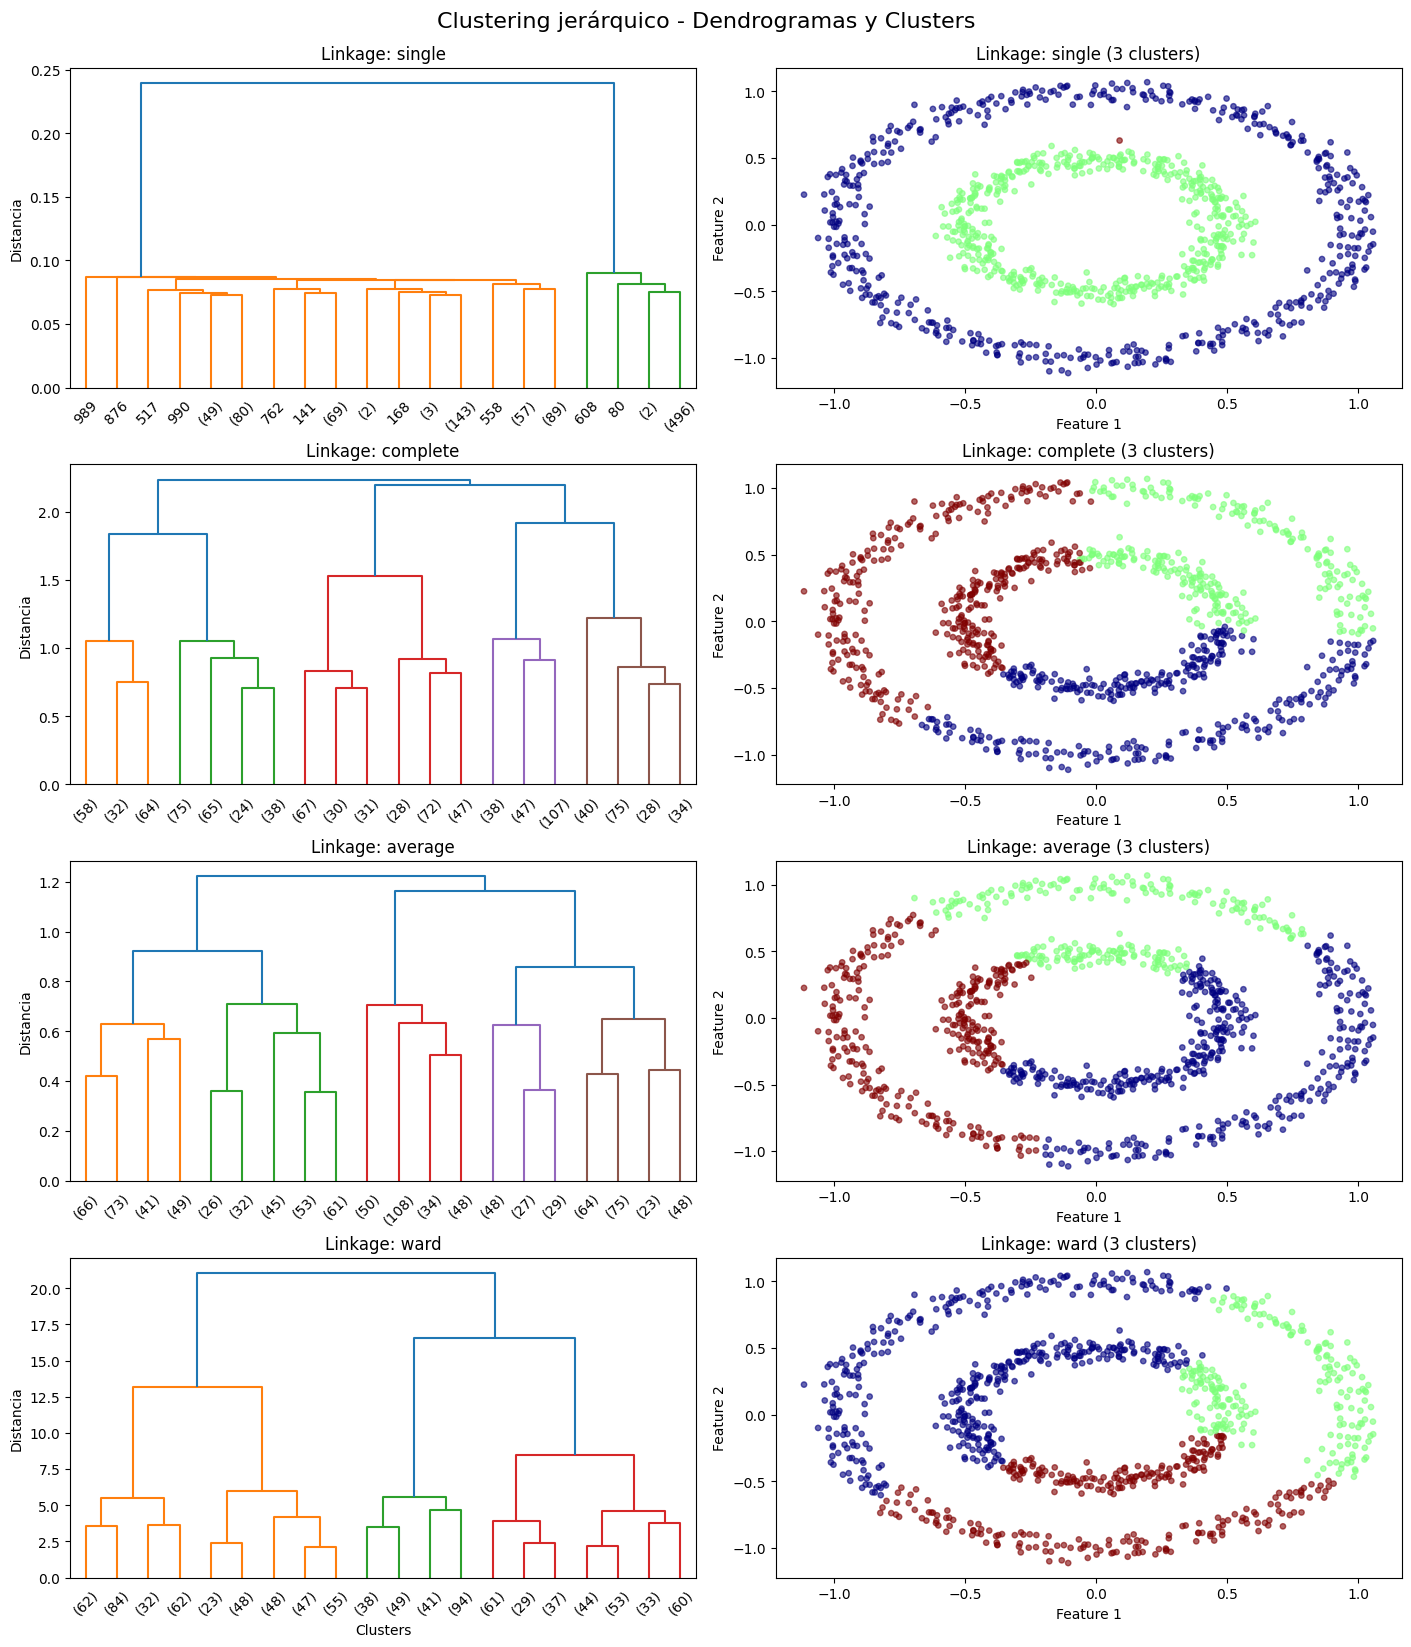

In [25]:
# ==========================================================
# Clustering jerárquico - Dataset Circles
# ==========================================================

linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(len(linkage_methods), 2, figsize=(14, 16), constrained_layout=True)
fig.suptitle("Clustering jerárquico - Dendrogramas y Clusters", fontsize=16, y=1.02)

for i, method in enumerate(linkage_methods):
    # --- Dendrograma ---
    Z = linkage(X, method=method)
    dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=10., ax=axes[i, 0])
    axes[i, 0].set_title(f"Linkage: {method}", fontsize=12)
    axes[i, 0].set_ylabel("Distancia")
    if i == len(linkage_methods) - 1:
        axes[i, 0].set_xlabel("Clusters")

    # --- Clusters ---
    clusters = fcluster(Z, 3, criterion="maxclust")
    axes[i, 1].scatter(X[:, 0], X[:, 1], c=clusters, cmap="jet", s=15, alpha=0.6)
    axes[i, 1].set_title(f"Linkage: {method} (3 clusters)", fontsize=12)
    axes[i, 1].set_xlabel("Feature 1")
    axes[i, 1].set_ylabel("Feature 2")

plt.savefig(r'../Visualizaciones/linkage_dendrogramas_y_clusters_circles.png', dpi=300, bbox_inches='tight')
plt.show()



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

Al aplicar distintos criterios de enlace al dataset *Circles*, los resultados muestran comportamientos muy distintos según la geometría del método y la estructura de los datos.

- **Average Linkage**
  - El dendrograma presenta una estructura compleja y sin saltos claros, pero el clustering con *$k$ = 2* logra separar correctamente el círculo interior y el anillo exterior. Aunque hay algunas asignaciones ambiguas, el método funciona razonablemente bien gracias a que **capta la distancia promedio entre los puntos de cada grupo**, suficiente para distinguir el pequeño hueco que los separa.

- **Complete Linkage**:
  - Produce resultados similares, pero con una separación más limpia y fronteras mejor definidas. Su dendrograma muestra una estructura más equilibrada y un hueco o *gap* moderado entre niveles, lo que refleja que preserva mejor la distancia entre las dos regiones. Al **usar la distancia máxima entre puntos**, evita que se formen “puentes” entre el círculo y el anillo.

- **Single Linkage**:
  - Al contrario, *single linkage* genera un dendrograma muy desbalanceado debido al efecto *chaining*, pero ofrece la mejor clasificación posible, al separar los dos círculos de forma perfecta y sin errores. Aunque el dendrograma parece caótico, **este método detecta conectividad más que compacidad**, lo que encaja perfectamente con la forma circular y continua del dataset. El anillo y el círculo se forman como dos cadenas bien separadas, sin puntos que conecten ambas estructuras.

- **Ward Linkage** 
  - Es el que se comporta peor. Tiende a fusionar grupos prematuramente y produce divisiones incorrectas que cortan el anillo de forma diagonal. Esto ocurre porque ***Ward* minimiza la varianza interna y asume clusters compactos y convexos**, una suposición que el dataset *Circles* no cumple. El anillo, al tener un hueco central, rompe esas condiciones y confunde al algoritmo.

Por lo tanto, el resultado más destacable es que **Single Linkage** se adapta sorprendentemente bien a la geometría circular, mientras que los demás métodos funcionan correctamente pero con limitaciones, y **Ward** falla por completo debido a la forma no convexa de los datos.

## 2. *Clustering* y reducción de dimensionalidad culinaria: (6 puntos)

En este ejercicio exploraremos cómo mediante clustering podemos descubrir patrones ocultos en miles de recetas reales de Food.com. Partiremos de un conjunto de unas 30.000 recetas con su nombre, descripción e ingredientes, y nuestro objetivo será agruparlas por similitud para ver qué tipos de platos emergen sin supervisión: ¿se juntan los postres? ¿los platos con ajo? ¿las recetas mediterráneas?

Probaremos distintas formas de representar las recetas: desde una codificación one-hot basada en los ingredientes, hasta embeddings semánticos generados con modelos de lenguaje (como MiniLM). Con ello veremos cómo cambia la estructura de los datos según el tipo de representación y qué tipo de similitud capturan mejor.

Finalmente aplicaremos técnicas de reducción de dimensionalidad con UMAP y varios métodos de clustering que podrás probar (KMeans, DBSCAN, HDBSCAN, Mean-shift, jerárquico...) para visualizar y analizar los grupos resultantes. Terminaremos interpretando los clusters más grandes a través de sus ingredientes y recetas representativas, comparando qué enfoque refleja mejor la *lógica culinaria* del conjunto.

In [ ]:
### FUNCIONES AUXILIARES ###

def describe_df(data):
    """
    Genera un resumen del DataFrame con información sobre estructura, tipos,
    valores nulos, valores únicos, estadísticas numéricas y rangos de fechas.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame a describir.

    Returns
    -------
    pandas.DataFrame
        Resumen del DataFrame con métricas básicas y estadísticas.
    """
    # Crear base del resumen
    total = len(data)
    summary = pd.DataFrame({
        'Column': data.columns,
        'Data Type': data.dtypes.astype(str),
        'Non-null Count': data.count().values,
        '% Null Values': ((data.isnull().sum() / total) * 100).round(2).values,
        'Unique Values': data.nunique().values
    })

    summary['Shape'] = f"{data.shape[0]} rows, {data.shape[1]} columns"

    # Estadísticas para columnas numéricas
    numeric_cols = data.select_dtypes(include=['number']).columns
    if not numeric_cols.empty:
        describe_stats = data[numeric_cols].describe().T
        describe_stats = describe_stats.rename(columns={'50%': 'median'})[
            ['mean', 'median', 'std', 'min', '25%',  '75%', 'max']
        ]
        describe_stats.reset_index(inplace=True)
        describe_stats.rename(columns={'index': 'Column'}, inplace=True)

        summary = pd.merge(summary, describe_stats, on='Column', how='left')

    # Rango de fechas para columnas datetime
    datetime_cols = data.select_dtypes(include=['datetime', 'datetime64[ns]']).columns
    if not datetime_cols.empty:
        date_ranges = pd.DataFrame({
            'Column': datetime_cols,
            'Min Date': data[datetime_cols].min().values,
            'Max Date': data[datetime_cols].max().values
        })
        summary = pd.merge(summary, date_ranges, on='Column', how='left')

    return summary

def detect_duplicates(df):
    """
    Detecta y devuelve todas las filas duplicadas del DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame en el que buscar duplicados.

    Returns
    -------
    pandas.DataFrame or None
        DataFrame con las filas duplicadas, o None si ocurre un error.
    """
    try:
        return df[df.duplicated(keep=False)]
    except Exception as e:
        print("Error detectando duplicados:", e)
        return None

def unique_df(df):
    """
    Muestra los valores únicos de las columnas categóricas del DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame a analizar.
    """
    categorical_columns = df.select_dtypes(include=['category', 'object']).columns

    if len(categorical_columns) == 0:
        print("No se encontraron columnas categóricas u objeto en el DataFrame.")
        return

    for column in categorical_columns:
        print(f"Resumen para la columna '{column}':\n{df[column].unique()}\n")

def limpiar_dataset_recetas(df):
    """
    Limpia y normaliza un dataset de recetas manteniendo estructura y separadores.
    Limpia texto, rellena nulos y genera una lista de ingredientes procesados.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame con información de recetas.

    Returns
    -------
    pandas.DataFrame
        DataFrame limpio con columna 'ingredientes_limpios'.
    """
    
    # Crear copia para no modificar el original
    df_clean = df.copy()
    
    # 1. Rellenar valores nulos con cadenas vacías
    df_clean = df_clean.fillna("")
    
    # 2. Limpiar columnas SIN QUITAR COMAS de ingredients
    columnas_sin_comas = ["steps", "tags", "search_terms"]
    
    for col in columnas_sin_comas:
        if col in df_clean.columns:
            df_clean[col] = (
                df_clean[col]
                .str.replace("-", " ", regex=False)           # Guiones por espacios
                .str.replace(".", " ", regex=False)           # Puntos por espacios
                .str.replace(r"[\[\]\{\}']", "", regex=True)  # Quitar corchetes, llaves, comillas
                .str.replace(",", " ", regex=False)           # Comas por espacios
                .str.replace(r"\s+", " ", regex=True)         # Espacios múltiples por uno
                .str.strip()                                   # Espacios inicio/final
            )
    
    # 3. Limpiar ingredients MANTENIENDO las comas
    if 'ingredients' in df_clean.columns:
        df_clean['ingredients'] = (
            df_clean['ingredients']
            .str.replace("-", " ", regex=False)           # Guiones por espacios
            .str.replace(".", " ", regex=False)           # Puntos por espacios
            .str.replace(r"[\[\]\{\}']", "", regex=True)  # Quitar corchetes, llaves, comillas
            # NO se quitan las comas
            .str.replace(r"\s+", " ", regex=True)         # Espacios múltiples por uno
            .str.strip()                                   # Espacios inicio/final
        )
        
        # Crear lista estructurada de ingredientes
        df_clean['ingredientes_limpios'] = df_clean['ingredients'].apply(_parsear_ingredientes)
    
    return df_clean


def crear_columna_unificada(df, nombre_columna="full_text"):
    """
    Crea una columna con todo el texto del registro concatenado y normalizado.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame previamente limpiado.
    nombre_columna : str, optional
        Nombre de la columna resultante (default: "full_text").

    Returns
    -------
    pandas.DataFrame
        DataFrame con la columna unificada añadida.
    """
    
    df_copy = df.copy()
    separador = " | "  # Separador fijo
    
    # Concatenar todas las columnas relevantes (ya están limpias)
    df_copy[nombre_columna] = (
        df_copy['name'].str.strip() + separador +
        df_copy['description'].str.strip() + separador +
        df_copy['ingredients'].str.strip() + separador +
        df_copy['steps'].str.strip() + separador +
        df_copy['tags'].str.strip() + separador +
        df_copy['search_terms'].str.strip()
    )
    
    # Limpieza final: eliminar separadores múltiples y espacios extra
    df_copy[nombre_columna] = (
        df_copy[nombre_columna]
        .str.replace(r'\s+', ' ', regex=True)                      # Espacios múltiples
        .str.replace(r'(\|\s*)+', ' | ', regex=True)               # Separadores duplicados
        .str.strip(' |')                                           # Quitar separador en bordes
        .str.strip()                                               # Espacios finales
    )
    
    return df_copy


def _parsear_ingredientes(x):
    """
    Convierte un campo de ingredientes en una lista limpia y normalizada.

    Parameters
    ----------
    x : str or list or NaN
        Ingredientes en texto o lista.

    Returns
    -------
    list
        Lista de ingredientes procesados en minúsculas.
    """

    # Manejar valores nulos o vacíos
    if pd.isna(x) or x == "":
        return []
    
    # Si ya es una lista, procesarla directamente
    if isinstance(x, list):
        return [unquote(str(i)).strip().lower() for i in x if i]
    
    # Intentar evaluar string como lista Python
    try:
        val = ast.literal_eval(x)
        if isinstance(val, (list, set)):
            return [unquote(str(i)).strip().lower() for i in val if i]
    except (ValueError, SyntaxError):
        pass
    
    # Si es un string simple, dividir por comas
    if isinstance(x, str):
        return [unquote(item).strip().lower() for item in x.split(',') if item.strip()]
    
    return []


def analizar_clusters_semanticos(df_original, embeddings, labels, top_k=10, top_recetas=5):
    """
    Analiza los clusters más grandes mostrando tamaño y recetas más representativas
    según distancia al centroide.

    Parameters
    ----------
    df_original : pandas.DataFrame
        DataFrame con información original de recetas.
    embeddings : array-like
        Representaciones vectoriales de las recetas.
    labels : array-like
        Etiquetas de cluster.
    top_k : int, optional
        Número de clusters a mostrar (default: 10).
    top_recetas : int, optional
        Número de recetas representativas por cluster (default: 5).
    """
    
    print("\n" + "="*90)
    print(f"TOP {top_k} CLUSTERS MÁS GRANDES")
    print("="*90)
    
    # Asegurar que embeddings es array
    embeddings = np.array(embeddings)

    # Contar tamaño de cada cluster (excluyendo ruido si hay -1)
    cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
    top_cluster_ids = cluster_sizes.head(top_k).index

    # Calcular centroides de todos los clusters
    centroides = {
        cid: embeddings[labels == cid].mean(axis=0)
        for cid in np.unique(labels[labels != -1])
    }

    for cluster_id in top_cluster_ids:
        mask = labels == cluster_id
        n_recetas = mask.sum()
        pct = (n_recetas / len(labels)) * 100
        
        print(f"\n{'─'*90}")
        print(f" CLUSTER {cluster_id} → {n_recetas} recetas ({pct:.1f}%)")
        print(f"{'─'*90}")
        
        if 'name' in df_original.columns:
            # Calcular distancias al centroide
            distancias = euclidean_distances(embeddings[mask], [centroides[cluster_id]]).flatten()
            idx_min = distancias.argsort()[:top_recetas]
            recetas_cercanas = df_original.loc[mask].iloc[idx_min]['name'].tolist()

            print(f"\nRecetas más cercanas al centroide:")
            for i, receta in enumerate(recetas_cercanas, 1):
                print(f"   {i}. {receta}")
        else:
            print("No se encontró la columna 'name' para mostrar ejemplos de recetas.")



def analizar_clusters_onehot(df_final, df_ingredientes_onehot, embedding, labels,
                             nombre_opcion="Opción A", top_n_clusters=10,
                             top_recetas=5, top_ingredientes=5):
    """
    Analiza los clusters más grandes mostrando recetas representativas e
    ingredientes más frecuentes.

    Parameters
    ----------
    df_final : pandas.DataFrame
        DataFrame con información de recetas.
    df_ingredientes_onehot : pandas.DataFrame
        Matriz one-hot de ingredientes.
    embedding : array-like
        Embedding o representación dimensional reducida.
    labels : array-like
        Etiquetas de cluster.
    nombre_opcion : str, optional
        Nombre identificativo del análisis.
    top_n_clusters : int, optional
        Número de clusters a analizar (default: 10).
    top_recetas : int, optional
        Número de recetas representativas (default: 5).
    top_ingredientes : int, optional
        Número de ingredientes más frecuentes (default: 5).
    """
    
    print("=" * 100)
    print(f"ANÁLISIS DE CLUSTERS - {nombre_opcion}")
    print("=" * 100)
    
    # Contar tamaño de cada cluster (excluyendo ruido -1)
    cluster_counts = pd.Series(labels[labels != -1]).value_counts().sort_values(ascending=False)
    
    # Seleccionar los N clusters más grandes
    top_clusters = cluster_counts.head(top_n_clusters).index.tolist()
    
    print(f"\nAnalizando los {len(top_clusters)} clusters más grandes:")
    print(f"Tamaños: {cluster_counts.head(top_n_clusters).tolist()}\n")
    
    # Analizar cada cluster
    for i, cluster_id in enumerate(top_clusters, 1):
        print("\n" + "=" * 100)
        print(f"CLUSTER {cluster_id} (Ranking #{i}) - Tamaño: {cluster_counts[cluster_id]} recetas")
        print("=" * 100)
        
        # Obtener índices de recetas en este cluster
        cluster_mask = labels == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        # Calcular centroide empírico en el espacio UMAP
        cluster_embedding = embedding[cluster_mask]
        centroide = np.mean(cluster_embedding, axis=0)
        
        # Calcular distancias euclidianas al centroide en espacio UMAP
        distancias = cdist([centroide], cluster_embedding, metric='euclidean')[0]
        
        # Obtener índices de las recetas más cercanas
        indices_cercanos = np.argsort(distancias)[:top_recetas]
        recetas_cercanas_idx = cluster_indices[indices_cercanos]
        
        # Mostrar recetas más cercanas al centroide
        print(f"\nTOP {top_recetas} RECETAS MÁS CERCANAS AL CENTROIDE:")
        print("-" * 100)
        
        for j, idx in enumerate(recetas_cercanas_idx, 1):
            nombre = df_final.iloc[idx]['name']
            distancia = distancias[indices_cercanos[j-1]]
            print(f"{j}. {nombre}")
            print(f"   Distancia al centroide: {distancia:.4f}")
        
        # Análisis de ingredientes más frecuentes
        print(f"\nTOP {top_ingredientes} INGREDIENTES MÁS FRECUENTES:")
        print("-" * 100)
        
        # Obtener matriz one-hot del cluster
        cluster_onehot = df_ingredientes_onehot.iloc[cluster_indices]
        
        # Contar frecuencia de cada ingrediente
        ingredientes_freq = cluster_onehot.sum(axis=0).sort_values(ascending=False)
        top_ing = ingredientes_freq.head(top_ingredientes)
        
        # Calcular frecuencia relativa
        n_recetas_cluster = len(cluster_indices)
        
        for ing, freq in top_ing.items():
            freq_relativa = (freq / n_recetas_cluster) * 100
            print(f"  • {ing}: {int(freq)} recetas ({freq_relativa:.1f}%)")
        
        print()


def evaluar_coherencia_tematica(df_ingredientes_onehot, labels, nombre_opcion):
    """
    Evalúa la coherencia temática midiendo la similitud coseno media dentro
    de cada cluster.

    Parameters
    ----------
    df_ingredientes_onehot : pandas.DataFrame
        Matriz one-hot de ingredientes.
    labels : array-like
        Etiquetas de cluster.
    nombre_opcion : str
        Nombre identificativo del análisis.

    Returns
    -------
    list
        Lista con las coherencias medias por cluster.
    """

    print("\n" + "=" * 100)
    print(f"EVALUACIÓN DE COHERENCIA TEMÁTICA - {nombre_opcion}")
    print("=" * 100)
    
    cluster_ids = [c for c in np.unique(labels) if c != -1]
    coherencias = []
    
    for cluster_id in cluster_ids:
        cluster_mask = labels == cluster_id
        cluster_onehot = df_ingredientes_onehot.iloc[cluster_mask]
        
        # Calcular similitud coseno media intra-cluster
        if len(cluster_onehot) > 1:
            from sklearn.metrics.pairwise import cosine_similarity
            sim_matrix = cosine_similarity(cluster_onehot)
            # Similitud media (excluyendo diagonal)
            n = len(sim_matrix)
            coherencia = (sim_matrix.sum() - n) / (n * (n - 1))
            coherencias.append(coherencia)
    
    print(f"\nCoherencia media (similitud coseno intra-cluster): {np.mean(coherencias):.4f}")
    print(f"Desviación estándar: {np.std(coherencias):.4f}")
    print(f"Rango: [{np.min(coherencias):.4f}, {np.max(coherencias):.4f}]")
    
    return coherencias

In [3]:
# Carga del dataset de recetas
df = pd.read_csv(r'../Data/recipes.csv')

# Visualización de las primeras filas
df.head(3)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms
0,56594,Sun-Dried Tomato Palmiers,"from ""INVITATION TO DINNER"" cookbook","['garlic cloves', 'pesto sauce', 'frozen puff ...","[""2 garlic cloves, peeled and finely min...",1 (675 g),1,"['Preheat the oven to 350 degrees F.', 'Stir t...","['60-minutes-or-less', 'time-to-make', 'course...",{'appetizer'}
1,311362,Char Siu Pork Corn and Bok Choy Stir Fry,Here is another wok recipe I like stir fry's a...,"['peanut oil', 'pork fillets', 'garlic cloves'...","[""2 tablespoons peanut oil"",""600 g p...",1 (364 g),4,['Heat 1 tabelspoon of oil in a wok and cook p...,"['60-minutes-or-less', 'time-to-make', 'course...","{'pork', 'dinner'}"
2,248335,Black Cat Fudge,These adorable fudge peices will be a huge hit...,"['semisweet chocolate', 'butter', 'light corn ...","[""8 ounces semisweet chocolate, coarsely ...",1 (42 g),24,"['Line 11x7 inches pan with foil, extending fo...","['time-to-make', 'course', 'preparation', 'occ...",{'dessert'}


In [5]:
# Resumen del DataFrame
describe_df(df)

,Column,Data Type,Non-null Count,% Null Values,Unique Values,Shape,mean,median,std,min,25%,75%,max
0,id,int64,50000,0.00,50000,"50000 rows, 10 columns",270316.64732,269245.5,154109.531409,41.0,137629.75,403126.5,537804.0
1,name,object,50000,0.00,47154,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,description,object,49053,1.89,48245,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ingredients,object,50000,0.00,49939,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ingredients_raw_str,object,50000,0.00,49984,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,serving_size,object,50000,0.00,2605,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,servings,int64,50000,0.00,89,"50000 rows, 10 columns",6.68870,4.0,8.609285,1.0,4.00,8.0,390.0
7,steps,object,50000,0.00,49967,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,tags,object,50000,0.00,46201,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,search_terms,object,50000,0.00,11451,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Detección de duplicados
detect_duplicates(df)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms


In [7]:
#  Resumen de las categorías únicas para variables categóricas
unique_df(df)

Resumen para la columna 'name':
['Sun-Dried Tomato Palmiers' 'Char Siu Pork Corn and Bok Choy Stir Fry'
 'Black Cat Fudge' ... 'Mexican Dip' 'Thai Basil Shrimp'
 'Roasted Eggplant and Tomato Pizza']

Resumen para la columna 'description':
['from "INVITATION TO DINNER" cookbook'
 "Here is another wok recipe I like stir fry's as they are quick, easy and reasonably priced to prepare and they are a great way to use up your left over vegetables in a nutritious meal. I served as is but it would go well with steamed rice, as I said yesterday we are watching our carb intake at the moment. This again would serve 3 good portions 4 smaller ones as is, or 4 good portions if served with rice.\r\n\r\nNote: Char Siu Sauce also know as chinese BBQ sauce. It is a paste like ingredient that is dark-red-brown in colour and has a sweet and spicy flavour. Made from fermented soy beans, honey and various spices."
 'These adorable fudge peices will be a huge hit with the kids.' ...
 'This is an original sala

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Crea una nueva columna en el <em>DataFrame</em> que contenga, en una sola cadena de texto,
    <strong>toda la información disponible de cada receta</strong>. Concatena, en ese orden:
  <ul>
    <li>Título (<code>name</code>)</li>
    <li>Descripción (<code>description</code>)</li>
    <li>Lista de ingredientes (<code>ingredients</code>)</li>
    <li>Pasos de preparación (<code>steps</code>)</li>
    <li>Etiquetas (<code>tags</code>) y, si existe, términos de búsqueda (<code>search_terms</code>)</li>
  </ul>
  <p>
    Esta columna representará una descripción textual completa de la receta y se usará en el siguiente paso
    para generar sus <strong>embeddings semánticos</strong>.
  </p>
  <p>
    Ten en cuenta:
  </p>
  <ul>
    <li>Convierte listas o conjuntos a texto legible (por ejemplo, separando por comas).</li>
    <li>Gestiona valores nulos para evitar errores de concatenación.</li>
    <li>Verifica que el texto resultante mantiene la información relevante y es coherente.</li>
  </ul>
</div>

Recomiendo reducir los datos mediante un muestreo aleatorio de los datos a 30.000 recetas, ya que el análisis con 50.000 puntos ha sido MUY costoso computacionalmente (pej.: 52 min para el siguiente grafico 'Dendrograma jerárquico de recetas (embeddings originales)' y unos 80 min para el gráfico 'Clusters de recetas con HDBSCAN y visualización UMAP'). Esto se debe a que el algoritmo de clustering jerárquico (función *linkage*) tiene una complejidad cuadrática respecto al número de muestras (O(n^2)). 

Tambien, el dendrograma sin el muestreo aleatorio se vuelve ininterpretable visualmente (se solaparían todas las ramas). Con la reduccion a 30.000 tarda menos de 20 min para completar las ejecuciones de las celdas.

In [4]:
# --- Muestra aleatoria reproducible y segura ---
n_samples = 30000
random_seed = 42  

# Evita error si hay menos filas que n_samples
n_samples = min(n_samples, len(df))

# Muestreo aleatorio
df_sample = (
    df
    .sample(n=n_samples, random_state=random_seed)
    .reset_index(drop=True)
)

# Información resumida de la muestra
print(f"Muestra generada: {n_samples} filas seleccionadas de {len(df)} totales.")

Muestra generada: 30000 filas seleccionadas de 50000 totales.


### 2.1. Limpieza y normalizacion

Algunas columnas vienen con listas codificadas como texto (pej.: "['garlic cloves', 'pesto sauce', 'frozen puff pastry', 'fontina', 'parmigiano-reggiano cheese', 'sun-dried tomato', 'fresh ground black pepper']"). Esto significa que la lista está almacenada como texto, no como lista real de Python.

De modo que para evitar errores las convierto a texto legible, creando la funcion safe_to_text(). Posteriormente construyo la nueva columna con las columnas indicadas en el enunciado, completando los valores nulos (si los hubiera) con un espacio vacio.

In [5]:
# Limpiar el dataset
df_limpio = limpiar_dataset_recetas(df_sample)
    
# Crear columna unificada
df_final = crear_columna_unificada(df_limpio)
    
# Verificar resultados
print("Columnas limpias:")
print(df_limpio[['name', 'ingredients', 'ingredientes_limpios']].head(3))
print("\nTexto unificado:")
print(df_final["full_text"].iloc[0])

Columnas limpias:
                                       name  \
0  Chicken Pizza With Caramelized Red Onion   
1  Veal and Asparagus With Basil Mayonnaise   
2                   Rich Buttermilk Waffles   

                                         ingredients  \
0  boneless skinless chicken breast, canola oil, ...   
1  veal scallops, basil leaves, prosciutto, aspar...   
2  butter, eggs, buttermilk, vanilla extract, all...   

                                ingredientes_limpios  
0  [boneless skinless chicken breast, canola oil,...  
1  [veal scallops, basil leaves, prosciutto, aspa...  
2  [butter, eggs, buttermilk, vanilla extract, al...  

Texto unificado:
Chicken Pizza With Caramelized Red Onion  | This recipe comes from the local newspaper. The combination of flavors on this pizza is like a party in your mouth with every bite!  | boneless skinless chicken breast, canola oil, red onion, brown sugar, balsamic vinegar, minced garlic cloves, dried oregano, dried basil, prepared pizz

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Genera los <strong>embeddings semánticos</strong> de las recetas utilizando el modelo 
    <code>all-MiniLM-L6-v2</code> de la librería <code>sentence-transformers</code>.
    Este modelo es una versión ligera de BERT que transforma frases completas en vectores numéricos
    que capturan su significado.
  <p>
    Usa como entrada la columna con toda la información de la receta (título, descripción, ingredientes, pasos y etiquetas)
    para obtener una representación semántica de cada una.
  </p>
  <p>
    Incrementa el parámetro <code>batch_size</code> en <code>encode()</code> para aprovechar mejor los recursos 
    y activa <code>show_progress_bar=True</code> para visualizar el progreso durante la generación de embeddings.
  </p>
</div>

A continuación genero los [embeddings](https://openwebinars.net/blog/embeddings/) semánticos de las recetas usando el modelo [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) de `sentence-transformers`, tomando como entrada la columna `text_full` que unifique en la celda anterior para generar:
- `embeddings`: tipo array de numpy de forma (n_recetas, 384)   .
- `df[embeddings]`: Columna con cada vector para futuras búsquedas semánticas.

In [7]:
# =============================================================
# Carga del modelo de embeddings semánticos
# =============================================================

# all-MiniLM-L6-v2 es un modelo ligero y eficiente (384 dimensiones)
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- Generación de embeddings a partir del texto unificado ---
# Uso batch_size alto para eficiencia y barra de progreso para seguimiento
embeddings = model.encode(
    df_final['full_text'].tolist(),
    batch_size=512, 
    normalize_embeddings= True,             
    show_progress_bar=True,
    convert_to_numpy=True
)

# --- Almacenamos los embeddings como columna separada o matriz ---
df_final['embedding'] = list(embeddings)

# Verificamos tamaño y forma
print(f"Embeddings generados: {embeddings.shape}")
print(df_final[['name', 'embedding']].head(3))

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Embeddings generados: (30000, 384)
                                       name  \
0  Chicken Pizza With Caramelized Red Onion   
1  Veal and Asparagus With Basil Mayonnaise   
2                   Rich Buttermilk Waffles   

                                           embedding  
0  [-0.07592365, -0.040101856, -0.0098651815, 0.0...  
1  [-0.05300236, -0.04604218, -0.013221178, -0.01...  
2  [0.017974366, -0.024042552, 0.07228446, 0.0180...  


Con el objeto de poder seguir trabajando con el jupyter notebook, sin tener que volver a ejecutar todo lo anterior (que en tiempo es sobre unos 25 minutos), guardo el dataframe junto a la columna de embeddings. De este modo, puedo cargar el dataframes con los embeddings ya generados y seguir desde este punto. 

In [8]:
# Guardamos el DataFrame
with open(r'../Data/df_with_embeddings.pkl', 'wb') as f:
    pickle.dump(df_final, f)

In [7]:
# Cargar el DataFrame con los embeddings
with open(r'../Data/df_with_embeddings.pkl', 'rb') as f:
    df_final = pickle.load(f)

print(df_final.head())
print(df_final['embedding'].iloc[0].shape)  

embeddings = np.vstack(df_final['embedding'].values)
print(f"Embeddings reconstruidos con forma: {embeddings.shape}")

       id                                      name  \
0   72989  Chicken Pizza With Caramelized Red Onion   
1  299542  Veal and Asparagus With Basil Mayonnaise   
2  419258                   Rich Buttermilk Waffles   
3  142430          Chocolate Chip Cookies for Jesse   
4   56542      Lickety Split Chocolate Pudding Mix.   

                                         description  \
0  This recipe comes from the local newspaper. Th...   
1  This meal is quick to make and very light and ...   
2  So often, when you find a recipe, you wonder i...   
3  Yet another recipe developed with love, for my...   
4  This is a handy mix to have in the cupboard. O...   

                                         ingredients  \
0  boneless skinless chicken breast, canola oil, ...   
1  veal scallops, basil leaves, prosciutto, aspar...   
2  butter, eggs, buttermilk, vanilla extract, all...   
3  brown sugar, granulated sugar, margarine, vani...   
4           powdered milk, sugar, flour, cocoa, salt

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Reduce los <strong>embeddings</strong> obtenidos a un espacio de <strong>2 dimensiones</strong> utilizando 
    <code>UMAP</code> (<em>Uniform Manifold Approximation and Projection</em>), una técnica de reducción de dimensionalidad
    que conserva la estructura local de los datos en espacios de alta dimensión.
  <p>
    UMAP busca representar los datos en un espacio más pequeño manteniendo la relación entre puntos similares,
    lo que lo hace ideal para visualizar embeddings en 2D y detectar grupos o patrones de manera intuitiva.
    En comparación con <em>t-SNE</em>, UMAP es más rápido, escalable, permite la proyección de nuevos puntos y preserva mejor la estructura global de los datos.
    Puedes consultar una comparación visual detallada en 
    <a href="https://pair-code.github.io/understanding-umap/" target="_blank">esta página</a>.
  </p>
  <p>
    Aplica UMAP sobre la matriz de embeddings y guarda el resultado en una nueva variable que contenga las coordenadas 2D
    de cada receta para su posterior visualización o análisis.
  </p>
</div>

Una vez obtenidos los embeddings semánticos, se reducen a 2 dimensiones utilizando [`UMAP`](https://pair-code.github.io/understanding-umap/) (*Uniform Manifold Approximation and Projection*) para poder visualizarlos y/o detectar patrones de similitud entre recetas. Esto genera un dataframe con 2 coordenadas 2D (`df['umap_x']` y `df['umap_y']`), listo para graficar.

En esta configuración:

* `n_neighbors=100`: Se consideran 100 vecinos en el espacio original al construir la estructura de proximidad. Un valor relativamente alto como este prioriza la preservación de la **estructura global** de los embeddings, ayudando a que clusters grandes o familias de recetas similares se mantengan agrupadas.
* `min_dist=0.05`: Controla la **distancia mínima entre puntos** en el espacio reducido. Un valor bajo permite que puntos semánticamente cercanos queden bien agrupados, facilitando la identificación de subgrupos compactos de recetas muy similares.
* `n_components=2`: Se reduce a 2 dimensiones para que los embeddings puedan ser **graficados fácilmente** en un plano XY, manteniendo la mayor parte de la información de similitud posible.
* `metric='cosine'`: La métrica de similitud utilizada es **coseno**, adecuada para embeddings de texto (como los generados por `all-MiniLM-L6-v2`), porque compara direcciones en lugar de magnitudes, capturando mejor la similitud semántica entre recetas.
* `random_state=42`: Fija la semilla para asegurar que la reducción de dimensionalidad sea **reproducible**, de modo que los resultados sean consistentes al ejecutar el código varias veces.

Con esta configuración, el objetivo es **respetar tanto la estructura global como los clusters locales de similitud entre recetas**, de manera que recetas relacionadas queden próximas en el espacio 2D y se puedan visualizar patrones semánticos claros.

In [6]:
# =============================================================
# Configuración y aplicación de UMAP
# =============================================================
reducer = umap.UMAP(
    n_neighbors=100, # Vecinos en el espacio original
    min_dist=0.05,    # Distancia mínima entre puntos en el espacio reducido
    n_components=2,  # Reducir a 2 dimensiones
    metric='cosine', # Siguiendo documentacion de all-MiniLM-L6-v2
    random_state=42  # Semilla para reproducibilidad
)

# --- Reducción de dimensionalidad ---
embeddings_2d = reducer.fit_transform(embeddings)

# --- Almaceno las coordenadas 2D en el DataFrame ---
df_final['umap_x'] = embeddings_2d[:, 0] # type: ignore
df_final['umap_y'] = embeddings_2d[:, 1] # type: ignore

# --- Verificación del resultado ---
print("Reducción UMAP completada.")
print(f"Shape del embedding reducido: {embeddings_2d.shape}") # type: ignore
print(df_final[['name', 'umap_x', 'umap_y']].head(3))

Reducción UMAP completada.
Shape del embedding reducido: (30000, 2)
                                       name     umap_x    umap_y
0  Chicken Pizza With Caramelized Red Onion  11.064763  7.320251
1  Veal and Asparagus With Basil Mayonnaise  10.250234  5.504392
2                   Rich Buttermilk Waffles   3.193565  9.420345


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el resultado de la reducción a 2D con <code>UMAP</code> mediante un <strong>scatter plot</strong>.
    Representa cada receta como un punto en el plano y observa si se forman grupos o regiones con mayor densidad.
  <p>
    Para mejorar la legibilidad del gráfico:
  </p>
  <ul>
    <li>
      Ajusta el parámetro <code>alpha</code> para controlar la <strong>transparencia</strong> de los puntos:
      valores más bajos (por ejemplo, 0.3) permiten visualizar mejor las zonas donde los puntos se solapan,
      haciendo más visibles las regiones densas.
    </li>
    <li>
      Reduce el parámetro <code>s</code> (tamaño de los puntos) para evitar que se superpongan en exceso
      y poder distinguir mejor la estructura general del conjunto.
    </li>
  </ul>
</div>

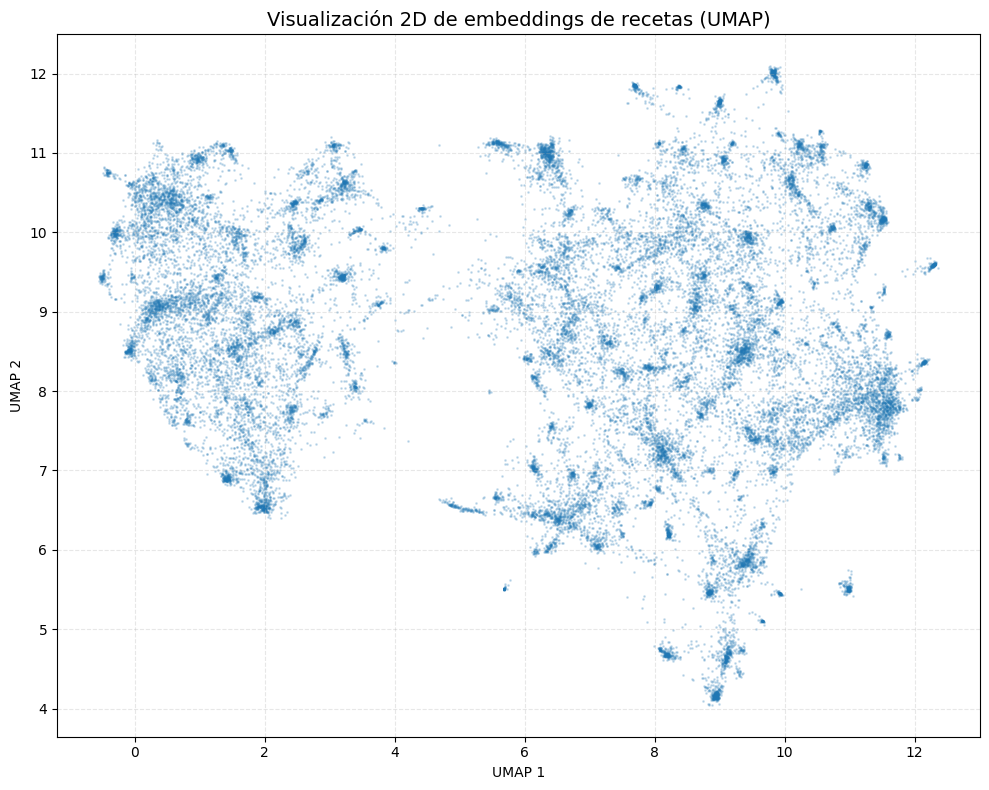

In [8]:
# =============================================================
# Visualización de los embeddings reducidos con UMAP
# =============================================================
plt.figure(figsize=(10, 8))
plt.scatter(
    df_final['umap_x'],
    df_final['umap_y'],
    s=1,         
    alpha=0.2    
)

plt.title("Visualización 2D de embeddings de recetas (UMAP)", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/embeddings_reducidos_con_UMAP.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> <strong>sobre qué datos realizar el clustering</strong>: 
    ¿sobre los datos reducidos en 2D o sobre los embeddings originales en alta dimensionalidad?
  <p>
    Justifica tu elección explicando las posibles consecuencias de aplicar el algoritmo 
    de clustering sobre una representación reducida en comparación con la original.
  </p>
</div>

La **elección correcta para el clustering** es hacerlo sobre los **embeddings originales** de alta dimensionalidad, no sobre la versión reducida en 2D. Esta decisión es clave para obtener un agrupamiento que sea verdaderamente representativo del significado de los textos.

La razón principal radica en la **preservación de la información semántica** y el propósito fundamental de cada técnica:

* **Embeddings Originales (384D):** Contienen la **estructura semántica completa** que el modelo ha aprendido. Al hacer el *clustering* sobre estas 384 dimensiones, el algoritmo (como `K-Means` o `HDBSCAN`) está agrupando los textos basándose en su **significado real** y sus relaciones de similitud precisas. Esto resulta en una **alta precisión** del *clustering*.
* **Embeddings Reducidos por UMAP (2D):** UMAP es una técnica de reducción de dimensionalidad **no lineal** cuyo propósito principal es la **visualización y exploración de patrones**. Aunque es excelente para dibujar los datos, en el proceso **pierde parte de la información global y distorsiona algunas distancias**. Por lo tanto, si se agrupase sobre la versión 2D, el algoritmo estará trabajando con una **proyección aproximada**, lo que puede llevar a límites de clusters distorsionados o incorrectos.

En resumen, para un análisis riguroso y una visualización clara, el flujo de trabajo recomendado es:

1.  **Fase de Clustering:** Utiliza los **embeddings originales (384D)** como entrada para tu algoritmo de clustering.
2.  **Fase de Visualización:** Una vez se tienen las etiquetas del cluster, se proyectan sobre el plano **UMAP 2D** para poder **interpretar y visualizar** los clusters y sus centroides en un gráfico fácil de entender. 

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza las recetas en su <strong>espacio original de alta dimensionalidad</strong> utilizando 
    un <strong>dendrograma</strong>. 
    Esto te permitirá analizar la estructura de los datos y comparar si las agrupaciones observadas 
    coinciden con las que aparecían en la proyección 2D de <code>UMAP</code>.
  <p>
    Comenta qué puedes inferir al observar el dendrograma:
    si existen grupos bien definidos o si las fusiones son graduales,
    y cómo se relaciona esa estructura jerárquica con las regiones que aparecían en la visualización reducida.
  </p>
</div>

El objetivo es observar cómo se agrupan las recetas en su espacio original de 384 dimensiones, sin reducir la dimensionalidad. 

Para ello se ha aplicado un clustering jerárquico aglomerativo, que va uniendo las recetas más parecidas de forma recursiva y genera un árbol jerárquico de fusiones que se puede visualizar mediante un dendrograma.

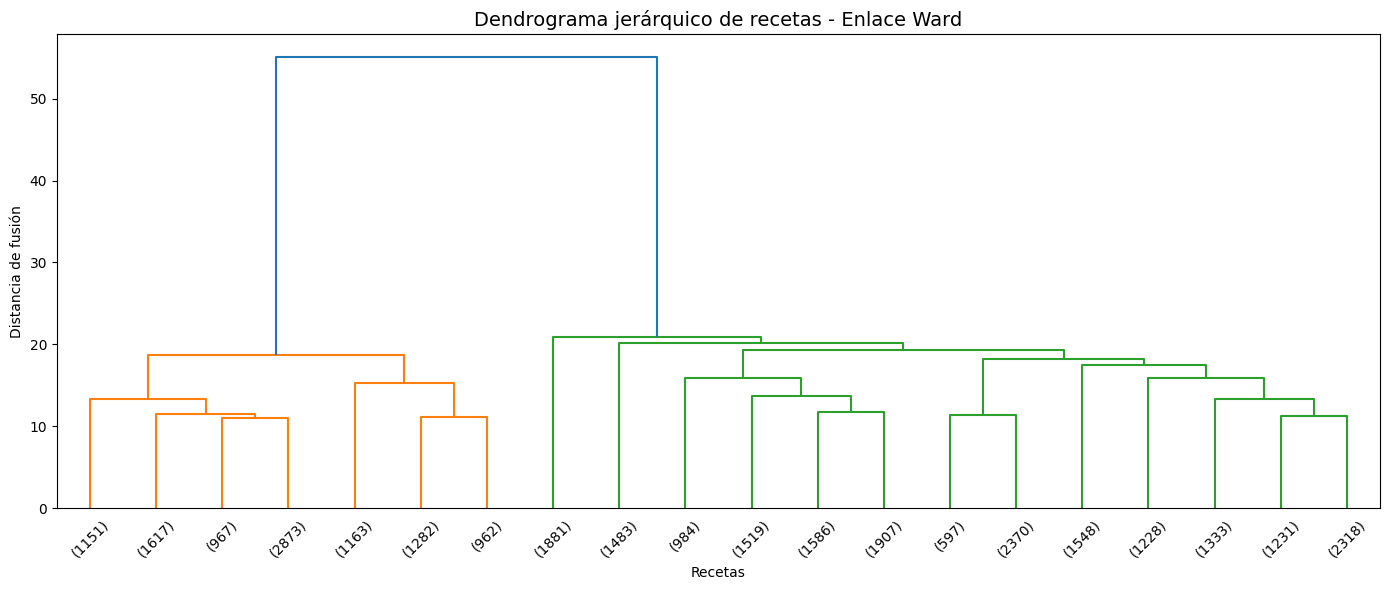

In [7]:
# =============================================================
# Visualización de la estructura jerárquica
# =============================================================
# --- Cálculo de la matriz de enlace (linkage matrix) ---
linkage_matrix = linkage(embeddings, method='ward')

# --- Visualización del dendrograma ---
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',     # muestra solo las fusiones más altas
    p=20,                      # número de grupos visibles
    leaf_rotation=45.,
    leaf_font_size=10.)

plt.title("Dendrograma jerárquico de recetas - Enlace Ward", fontsize=14)
plt.xlabel("Recetas")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dendrograma_recetas.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Dado lo observado en la reducción de dimensionalidad con <code>UMAP</code> y en el dendrograma obtenido,
    decide <strong>qué algoritmo de clustering</strong> utilizarías para identificar los grupos de recetas.
    Explica con qué argumentos lo elegirías y justifica tu respuesta en función de la estructura observada 
    en los datos (densidad, tamaño y forma de los grupos).
</div>

A partir de la observación conjunta del **dendrograma jerárquico** y la **proyección bidimensional obtenida mediante UMAP**, se evidencia que el espacio semántico de las recetas presenta una estructura continua, sin divisiones abruptas ni fronteras claramente definidas entre grupos. El dendrograma muestra fusiones progresivas y homogéneas, sin saltos marcados que indiquen la existencia de jerarquías bien delimitadas; esto sugiere que las similitudes entre recetas varían de manera gradual y que los posibles grupos no están separados por grandes distancias semánticas. Por su parte, el UMAP revela una nube densa y extensa, con áreas localmente más concentradas, pero sin núcleos aislados o regiones vacías entre ellos.

En este contexto, la distribución observada apunta a una organización más cercana a un continuo de recetas que a una segmentación en grupos cerrados. No se aprecia una estructura que responda bien a modelos de densidad irregular o con fronteras difusas, lo que limita la eficacia de algoritmos como `DBSCAN` o `HDBSCAN`, que dependen de contrastes claros entre regiones densas y dispersas. Además, la alta dimensionalidad y el volumen de datos hacen que los métodos basados en densidad resulten computacionalmente costosos, como se ha comprobado con `HDBSCAN` (intenté usarlo y ni reduciendo el numero de muestras completaba la ejecución).

`K-Means`, pese a su simplicidad, se adapta mejor a este tipo de estructura. Al imponer una partición global del espacio y asumir clusters de forma aproximadamente convexa, permite capturar de manera eficiente las grandes tendencias semánticas sin requerir un ajuste fino de parámetros ni un cálculo intensivo de distancias. La elección de un número moderado de clusters ofrece una segmentación estable, equilibrada y fácilmente interpretable, donde cada grupo representa un conjunto de recetas con coherencia temática y proximidad semántica.

Por tanto, considerando la densidad uniforme, la ausencia de fronteras naturales y la necesidad de un método computacionalmente manejable, `K-Means` constituye la opción más adecuada para identificar y analizar los grupos de recetas en este conjunto de datos.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Implementa el algoritmo elegido y analiza sus posibles parámetros para obtener el resultado deseado.
</div>

Para determinar el número óptimo de clusters en nuestro análisis KMeans, evaluamos dos métricas clave: la inercia y el coeficiente de silueta.

La **inercia** mide la compacidad de los clusters, es decir, la suma de las distancias al cuadrado entre cada punto y el centroide de su cluster. Valores más bajos indican clusters más compactos, pero la inercia siempre disminuye al aumentar el número de clusters, por lo que es útil observar cómo cambia entre valores consecutivos de $k$ mediante el método del codo. En nuestro caso, al pasar de 2 a 3 clusters, la inercia baja de 17.081 a 16.698, un cambio relativo significativo, mientras que incrementos posteriores aportan reducciones mucho menores, lo que señala que la mejora en la compacidad se estabiliza rápidamente. Esto sugiere que **dos clusters capturan gran parte de la estructura de los datos**, y añadir más clusters aporta poco beneficio.

Por su parte, el **coeficiente de silueta** evalúa qué tan bien separados están los clusters comparando la distancia media entre puntos del mismo cluster con la distancia media al cluster más cercano. Su valor varía entre -1 y 1, donde valores cercanos a 1 indican clusters bien definidos. En nuestros resultados, el valor máximo se alcanza también en **k=2** (0,094), confirmando que esta partición ofrece la separación relativa más clara, aunque el valor bajo indica que los clusters no están fuertemente definidos.

En resumen, tanto el análisis de la inercia como el de la silueta coinciden en que **k=2** es el número óptimo de clusters para nuestros datos. Sin embargo, la baja puntuación de silueta sugiere que la estructura de los datos es tenue y que los clusters identificados no son completamente distintos. 

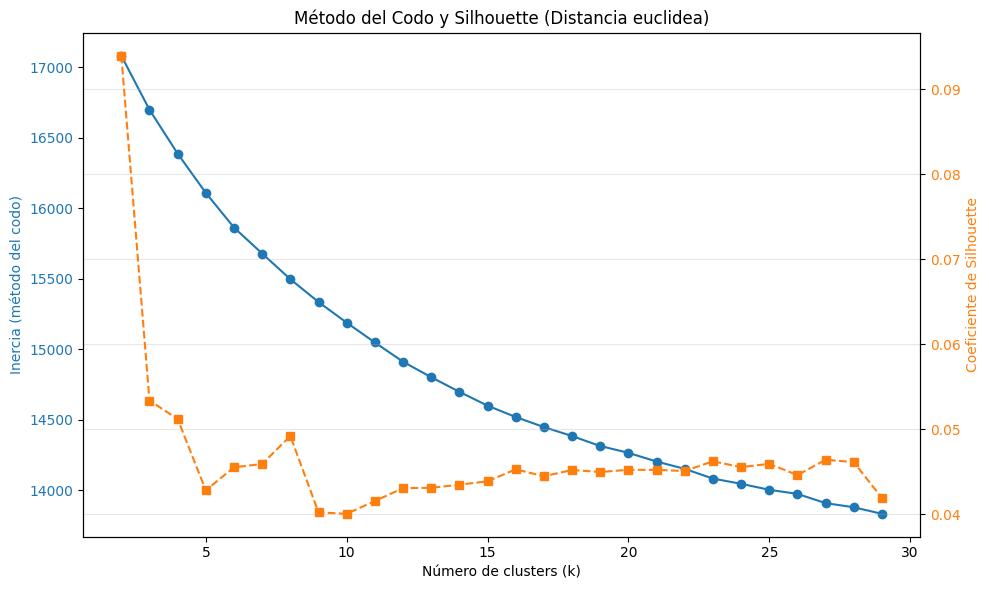

In [ ]:
# ===========================================================================
# Determinación del número óptimo de clusters (K-Means) - MÉTRICA EUCLIDEA
# ===========================================================================
# --- Datos de entrada ---
X = embeddings 

# --- Rango de k a evaluar ---
n_clusters = range(2, 30)  
inertias = []
silhouette_scores = []

# --- Evaluación de KMeans para cada k ---
for k in n_clusters:
    print(f"Evaluando K={k}...", end='\r')
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,       # nº de inicializaciones diferentes
        max_iter=300,    # nº máximo de iteraciones por ejecución
        init='k-means++' # inicialización inteligente de centroides
    )
    
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    
    # Calcular silhouette sólo si hay más de 1 cluster
    silhouette_scores.append(silhouette_score(X, labels))

# =============================================================
# Visualización conjunta
# =============================================================
fig, ax1 = plt.subplots(figsize=(10,6))

color_elbow = 'tab:blue'
color_silhouette = 'tab:orange'

# --- Curva del método del codo (inercia) ---
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (método del codo)', color=color_elbow)
ax1.plot(n_clusters, inertias, 'o-', color=color_elbow, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color_elbow)

# --- Segundo eje para Silhouette ---
ax2 = ax1.twinx()
ax2.set_ylabel('Coeficiente de Silhouette', color=color_silhouette)
ax2.plot(n_clusters, silhouette_scores, 's--', color=color_silhouette, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color_silhouette)

# --- Título y estética ---
plt.title('Método del Codo y Silhouette (Distancia euclidea)')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig(r'../Visualizaciones/regla_del_codo_y_silhouette_embeddings_euclidea.png', dpi=300)
plt.show()

In [ ]:
# Crear DataFrame con los resultados
df_resultados = pd.DataFrame({
    'k': list(range(2, 30)),
    'Inercia': inertias,
    'Silhouette': silhouette_scores
})

# Calcular mejoras relativas (opcional, útil para ver el "codo")
df_resultados['Inercia (%)'] = df_resultados['Inercia'].pct_change().fillna(0) * 100

# Redondear para legibilidad
df_resultados = df_resultados.round({
    'Inercia': 2,
    'Silhouette': 4,
    'Inercia (%)': 2
})

# Mostrar tabla ordenada por k
print("Resumen de resultados por número de clusters (k):\n")
print(df_resultados.to_string(index=False))

# --- Opcional: mostrar el mejor k según cada criterio ---
k_optimo_inercia = df_resultados.loc[df_resultados['Inercia (%)'].abs().idxmin(), 'k']
k_optimo_silhouette = df_resultados.loc[df_resultados['Silhouette'].idxmax(), 'k']

print("\n\tMejor k según método del codo (cambio mínimo en inercia):", k_optimo_inercia)
print("\tMejor k según coeficiente de silueta:", k_optimo_silhouette)


Resumen de resultados por número de clusters (k):

 k  Inercia  Silhouette  Δ Inercia (%)
 2 17081.22      0.0940           0.00
 3 16698.14      0.0534          -2.24
 4 16386.92      0.0512          -1.86
 5 16108.32      0.0428          -1.70
 6 15862.55      0.0455          -1.53
 7 15678.25      0.0459          -1.16
 8 15496.20      0.0492          -1.16
 9 15334.30      0.0402          -1.04
10 15187.81      0.0400          -0.96
11 15047.33      0.0415          -0.92
12 14910.71      0.0431          -0.91
13 14800.98      0.0431          -0.74
14 14697.40      0.0435          -0.70
15 14599.02      0.0439          -0.67
16 14518.53      0.0453          -0.55
17 14447.39      0.0445          -0.49
18 14383.53      0.0452          -0.44
19 14312.91      0.0450          -0.49
20 14264.60      0.0452          -0.34
21 14202.68      0.0452          -0.43
22 14150.81      0.0451          -0.37
23 14081.81      0.0462          -0.49
24 14044.83      0.0455          -0.26
25 14002.49  

Valores de $k$ a comentar:

**$k=2$** 
* Es el mejor según los criterios clásicos, hay señales que invitan a examinar otros valores, sobre todo si buscas una segmentación más fina o interpretativamente útil:

**$k = 6–8$**:
* En esta zona, la inercia sigue disminuyendo de forma moderada, pero la silueta experimenta un pequeño repunte (pasa de 0.045 a 0.0492 en k=8).Esto sugiere que los datos podrían tener subestructuras internas débiles, no captadas con solo 2 clusters.

**$k ≈ 26–27$**:
* Aunque poco común, la silueta muestra un leve aumento en torno a estos valores (0.0464 en k=27), lo cual podría indicar una partición más granular, posiblemente alineada con grupos específicos en los datos (por ejemplo, si provienen de distintas especies, zonas o patrones temporales).

Posteriormente a la determinación del K optimo, se aplicó el algoritmo **K-Means** para agrupar las recetas según sus *embeddings* semánticos obtenidos con el modelo *all-MiniLM-L6-v2*. El modelo se configuró con los parámetros estándar recomendados: **`init='k-means++'`** para una inicialización eficiente de centroides, **`n_init=10`** para garantizar estabilidad en los resultados, **`max_iter=300`** como límite máximo de iteraciones y **`random_state=42`** para asegurar reproducibilidad. La tolerancia por defecto (**`tol=1e-4`**) se mantuvo al ser suficiente para la convergencia del algoritmo.

In [8]:
# =============================================================
# Clustering con K-Means - k = 2 (optimo según análisis previo)
# =============================================================

# --- Selección del número de clusters ---
# Determinado con el método del codo o silhouette.
n_clusters = 2

# --- Inicialización y entrenamiento ---
kmeans = KMeans(
        n_clusters=n_clusters,    # número de clusters elegido
        random_state=42,          # semilla para reproducibilidad
        n_init=10,                # nº de inicializaciones diferentes
        max_iter=300,             # nº máximo de iteraciones por ejecución
        init='k-means++',         # inicialización inteligente de centroides
        tol=1e-4                  # tolerancia para convergencia
)

labels_k2 = kmeans.fit_predict(embeddings)

print(f"Clusters encontrados: {n_clusters}")
print(f"Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).")

Clusters encontrados: 2
Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).


In [9]:
# =============================================================
# Clustering con K-Means - k = 8 (subida de silhouette secundaria)
# =============================================================

# --- Selección del número de clusters ---
# Determinado con el método del codo o silhouette.
n_clusters = 8

# --- Inicialización y entrenamiento ---
kmeans = KMeans(
        n_clusters=n_clusters,    # número de clusters elegido
        random_state=42,          # semilla para reproducibilidad
        n_init=10,                # nº de inicializaciones diferentes
        max_iter=300,             # nº máximo de iteraciones por ejecución
        init='k-means++',         # inicialización inteligente de centroides
        tol=1e-4                  # tolerancia para convergencia
)

labels_k8 = kmeans.fit_predict(embeddings)

print(f"Clusters encontrados: {n_clusters}")
print(f"Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).")

Clusters encontrados: 8
Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).


In [10]:
# =============================================================
# Clustering con K-Means sobre la muestra
# =============================================================

# --- Selección del número de clusters ---
# Determinado con el método del codo o silhouette.
n_clusters = 26   

# --- Inicialización y entrenamiento ---
kmeans = KMeans(
        n_clusters=n_clusters,    # número de clusters elegido
        random_state=42,          # semilla para reproducibilidad
        n_init=10,                # nº de inicializaciones diferentes
        max_iter=300,             # nº máximo de iteraciones por ejecución
        init='k-means++',         # inicialización inteligente de centroides
        tol=1e-4                  # tolerancia para convergencia
)

labels_k26 = kmeans.fit_predict(embeddings)

print(f"Clusters encontrados: {n_clusters}")
print(f"Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).")

Clusters encontrados: 26
Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Representa en un <strong>scatter plot</strong> la proyección 2D (UMAP) coloreando cada punto según su
    <code>cluster</code>. Usa una paleta cualitativa rica en colores (como <code>tab20</code>). Si hay más clusters que colores disponibles, reutiliza colores
    aplicando el índice del cluster <em>módulo</em> el número de colores de la paleta.
</div>

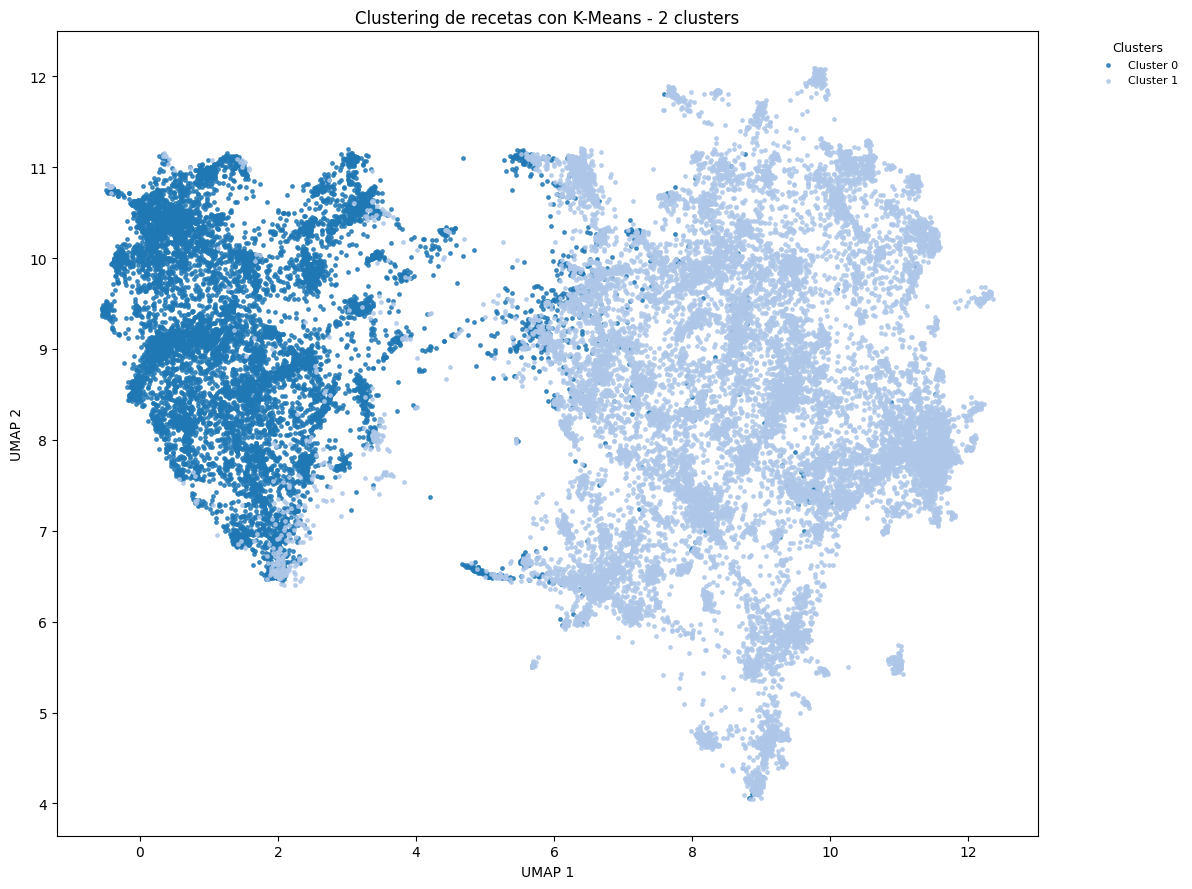

In [41]:
# =============================================================
# Visualización de los clusters (UMAP) con leyenda
# =============================================================
n_clusters = 2

# --- Colores de clusters ---
palette = sns.color_palette('tab20', n_colors=n_clusters)
colors = [palette[int(label % len(palette))] for label in labels_k2]

plt.figure(figsize=(12, 9))

# --- Dibujar cada cluster por separado para poder etiquetar ---
for cluster_id in range(n_clusters):
    mask = labels_k2 == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        s=6,
        color=palette[cluster_id % len(palette)],
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

# --- Títulos y etiquetas ---
plt.title(f"Clustering de recetas con K-Means - {n_clusters} clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# --- Leyenda fuera del área del gráfico ---
plt.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_k-2_clusters_umap_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()

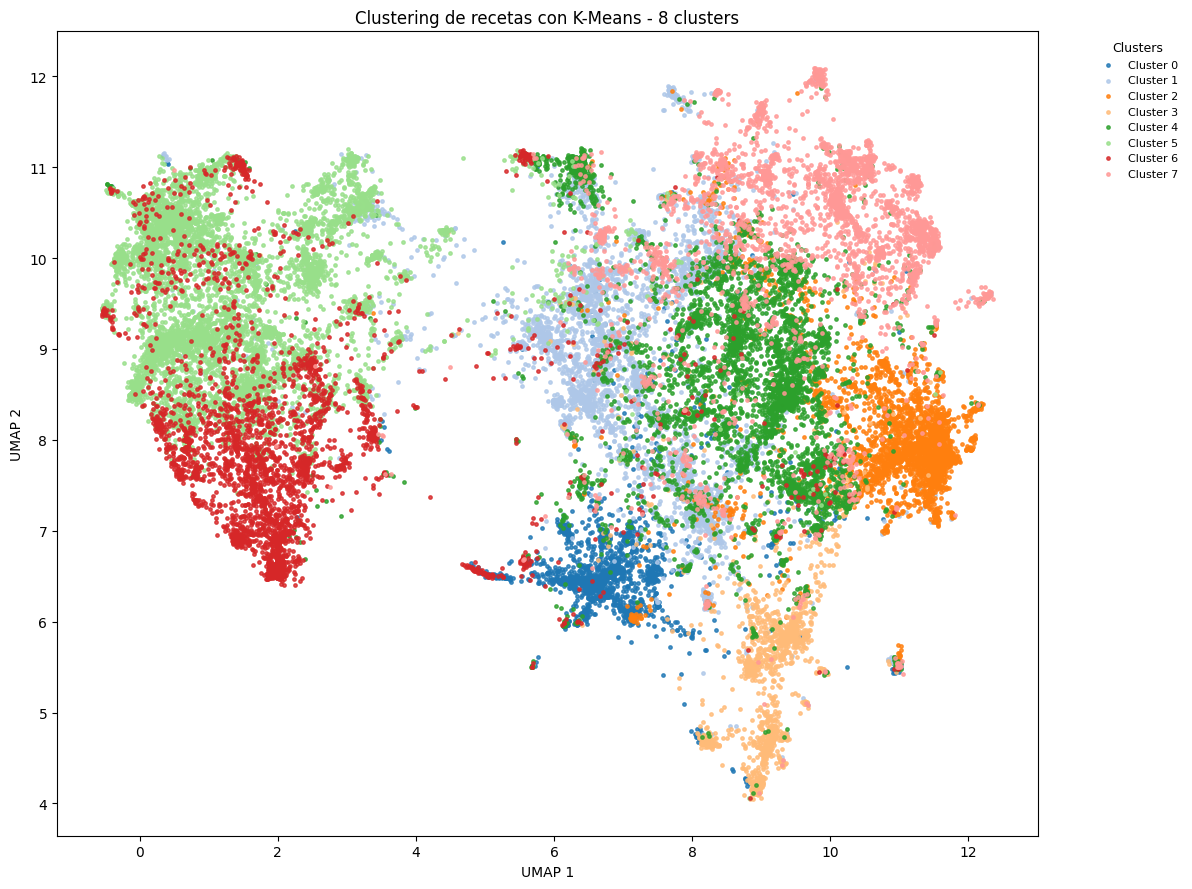

In [43]:
# =============================================================
# Visualización de los clusters (UMAP) con leyenda
# =============================================================
n_clusters = 8

# --- Colores de clusters ---
palette = sns.color_palette('tab20', n_colors=n_clusters)
colors = [palette[int(label % len(palette))] for label in labels_k8]

plt.figure(figsize=(12, 9))

# --- Dibujar cada cluster por separado para poder etiquetar ---
for cluster_id in range(n_clusters):
    mask = labels_k8 == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        s=6,
        color=palette[cluster_id % len(palette)],
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

# --- Títulos y etiquetas ---
plt.title(f"Clustering de recetas con K-Means - {n_clusters} clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# --- Leyenda fuera del área del gráfico ---
plt.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_k-8_clusters_umap_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()


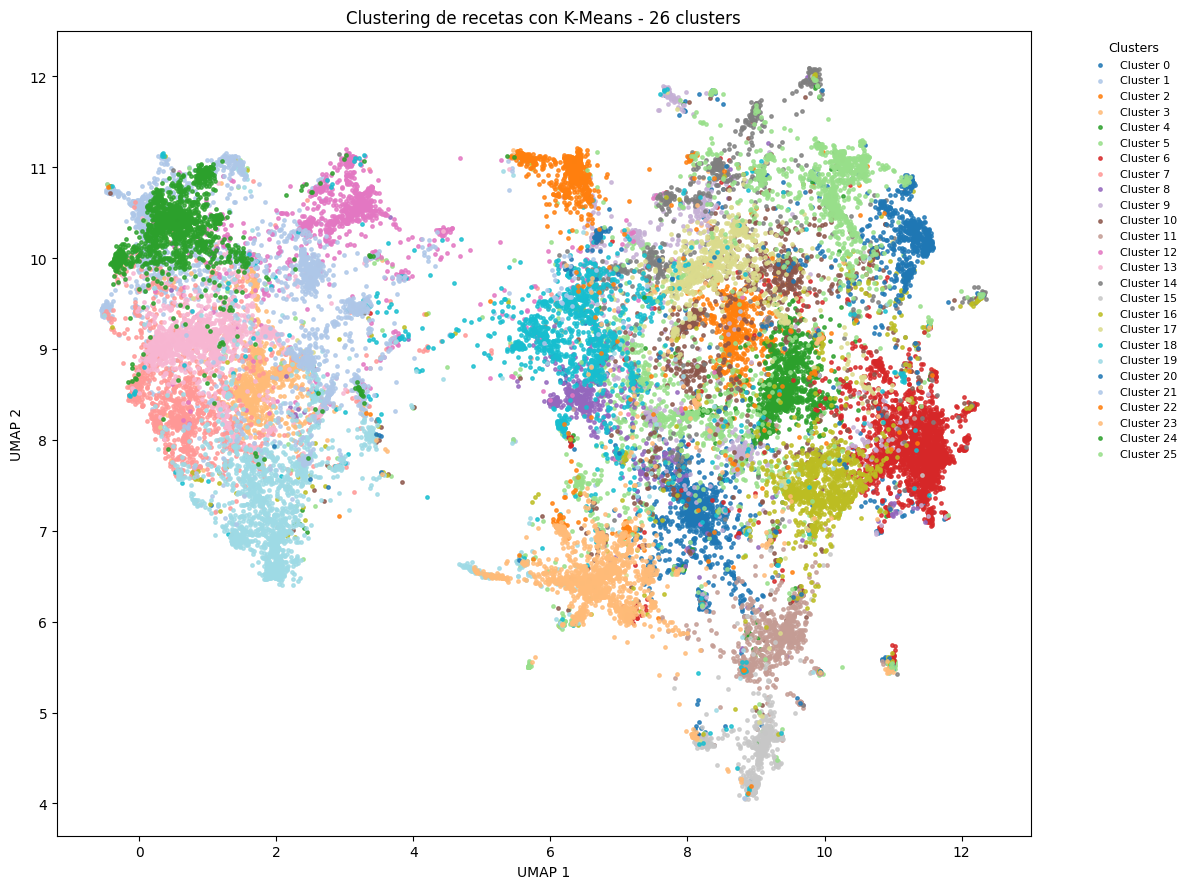

In [45]:
# =============================================================
# Visualización de los clusters (UMAP) con leyenda
# =============================================================
n_clusters = 26 

# --- Colores de clusters ---
palette = sns.color_palette('tab20', n_colors=n_clusters)
colors = [palette[int(label % len(palette))] for label in labels_k26]

plt.figure(figsize=(12, 9))

# --- Dibujar cada cluster por separado para poder etiquetar ---
for cluster_id in range(n_clusters):
    mask = labels_k26 == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        s=6,
        color=palette[cluster_id % len(palette)],
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

# --- Títulos y etiquetas ---
plt.title(f"Clustering de recetas con K-Means - {n_clusters} clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# --- Leyenda fuera del área del gráfico ---
plt.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_k-26_clusters_umap_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y validar su coherencia, selecciona los <strong>10 grupos</strong> con mayor tamaño y muestra,
    para cada uno, las <strong>5 recetas más cercanas al centroide</strong> (si el método lo define).
</div>

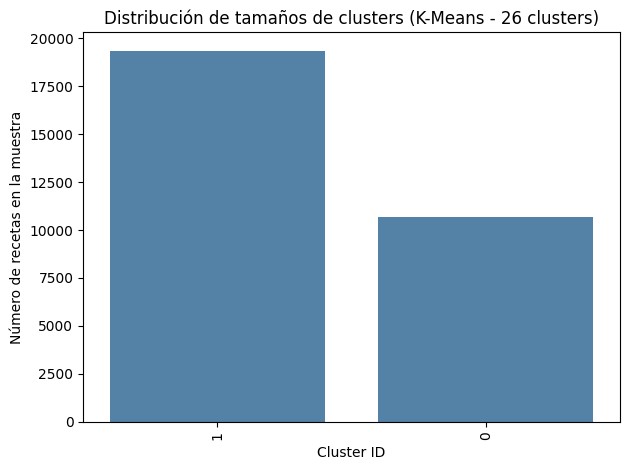


TOP 10 CLUSTERS MÁS GRANDES

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 1 → 19340 recetas (64.5%)
──────────────────────────────────────────────────────────────────────────────────────────

Recetas más cercanas al centroide:
   1. Anything Goes Stir-Fry
   2. Pork and Brown Rice Green Chile Casserole
   3. Garlic Sauce
   4. 30 Minute Dinner
   5. Chicken &amp; Rice Chili

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 0 → 10660 recetas (35.5%)
──────────────────────────────────────────────────────────────────────────────────────────

Recetas más cercanas al centroide:
   1. Confectioner's Sugar Cookies
   2. Pumpkin Bars With Cream Cheese Frosting
   3. Sugar Cookies
   4. Everything Cookies
   5. Soft &quot;n&quot; Chewy Creamsicle Cookies


In [ ]:
# =============================================================
# Análisis de los clusters obtenidos (muestra)
# =============================================================
sns.countplot(
    x=labels_k2,
    order=pd.Series(labels_k2).value_counts().index,
    color='steelblue'
)
plt.title(f"Distribución de tamaños de clusters (K-Means - {n_clusters} clusters)")
plt.xlabel("Cluster ID")
plt.ylabel("Número de recetas en la muestra")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_k-2_tamano_clusters_embeddings.png', dpi=300)
plt.show()

# =============================================================
# Recetas representativas por cluster (en la muestra)
# =============================================================

reps = analizar_clusters_semanticos(df_final, embeddings, labels_k2)


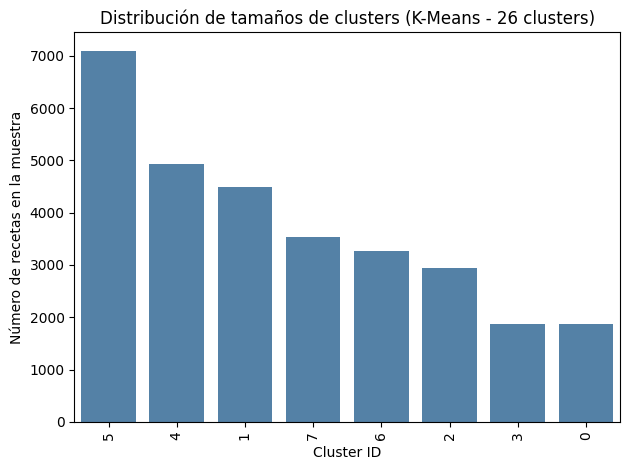


TOP 10 CLUSTERS MÁS GRANDES

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 5 → 7094 recetas (23.6%)
──────────────────────────────────────────────────────────────────────────────────────────

Recetas más cercanas al centroide:
   1. Confectioner's Sugar Cookies
   2. Sugar Cookies
   3. Everything Cookies
   4. (I Just Made the Best) Chocolate Chip Cookies!
   5. Butterscotch Bars

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 4 → 4936 recetas (16.5%)
──────────────────────────────────────────────────────────────────────────────────────────

Recetas más cercanas al centroide:
   1. Anything Goes Stir-Fry
   2. Mexican Black Bean and Corn Soup
   3. Insanely Easy Vegetarian Chili
   4. White Bean Chili
   5. Spicy Garden Chili

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 1 → 4483 recetas (14.9%)
─────────────────────────────

In [ ]:
# =============================================================
# Análisis de los clusters obtenidos (muestra)
# =============================================================
sns.countplot(
    x=labels_k8,
    order=pd.Series(labels_k8).value_counts().index,
    color='steelblue'
)
plt.title(f"Distribución de tamaños de clusters (K-Means - {n_clusters} clusters)")
plt.xlabel("Cluster ID")
plt.ylabel("Número de recetas en la muestra")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_k-8_tamano_clusters_embeddings.png', dpi=300)
plt.show()

# =============================================================
# Recetas representativas por cluster (en la muestra)
# =============================================================

reps = analizar_clusters_semanticos(df_final, embeddings, labels_k8)


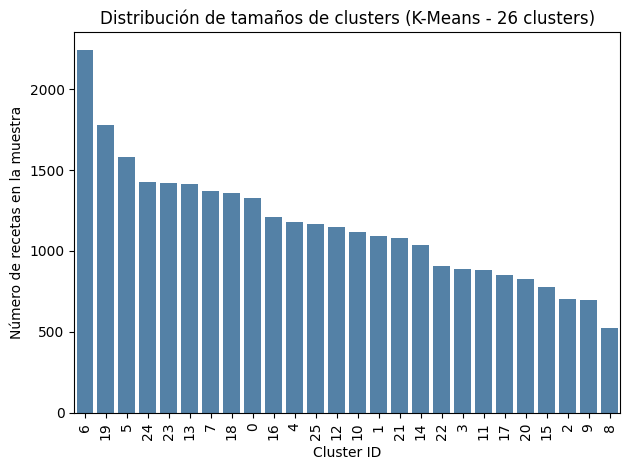


TOP 10 CLUSTERS MÁS GRANDES

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 6 → 2238 recetas (7.5%)
──────────────────────────────────────────────────────────────────────────────────────────

Recetas más cercanas al centroide:
   1. Chicken in a Packet
   2. Company Garlic Chicken
   3. Lemon Pepper Chicken
   4. Chicken Provencal With Potatoes and Carrots
   5. Chicken Breasts in Lemon Cream Sauce

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 19 → 1778 recetas (5.9%)
──────────────────────────────────────────────────────────────────────────────────────────

Recetas más cercanas al centroide:
   1. Easy 'n Elegant Fruit Cocktail
   2. All-American Fruit Smoothies
   3. Tropical Shake
   4. A Summer Treat
   5. Creamy Pineapple Citrus Shake

──────────────────────────────────────────────────────────────────────────────────────────
 CLUSTER 5 → 1579 recetas (5.3%)
────────────────

In [ ]:
# =============================================================
# Análisis de los clusters obtenidos (muestra)
# =============================================================
sns.countplot(
    x=labels_k26,
    order=pd.Series(labels_k26).value_counts().index,
    color='steelblue'
)
plt.title(f"Distribución de tamaños de clusters (K-Means - {n_clusters} clusters)")
plt.xlabel("Cluster ID")
plt.ylabel("Número de recetas en la muestra")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_k-26_tamano_clusters_embeddings.png', dpi=300)
plt.show()

# =============================================================
# Recetas representativas por cluster (en la muestra)
# =============================================================

reps = analizar_clusters_semanticos(df_final, embeddings, labels_k26)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Observa los resultados del clustering e interpreta si los grupos obtenidos <strong>tienen sentido</strong> desde un punto de vista culinario. 
    Observa si las recetas dentro de un mismo cluster comparten ingredientes, estilo de preparación o tipo de plato 
    (por ejemplo, salsas, postres, carnes, ensaladas...). 
    Explica brevemente por qué crees que los clusters son o no coherentes.
</div>

Analizando los resultados del clustering desde una perspectiva culinaria, encuentro que **los grupos obtenidos tienen bastante sentido y coherencia**, aunque el nivel óptimo de granularidad depende del propósito del análisis.

#### **$k=2$: Separación fundamental pero limitada**
La división básica separa claramente:
- **Cluster 0 (35.5%)**: Postres y repostería (*cookies*, *bars* con *frosting*).
- **Cluster 1 (64.5%)**: Platos salados (*stir-fries*, casseroles, carnes, arroces).

> **Coherencia**: Alta. Esta es la división más natural en cocina (dulce vs salado), pero demasiado general para ser útil.

#### **$k=8$: Balance óptimo** 
Los clusters muestran categorías culinarias muy reconocibles:

- **Cluster 0**: Ensaladas (*salads* con vegetales frescos).
- **Cluster 1**: Pasta y huevos (casseroles con queso, desayunos)
- **Cluster 2**: Pollo preparado (*chicken dishes*).
- **Cluster 3**: Mariscos (*shrimp*, *fish* con arroz/pasta).
- **Cluster 4**: Vegetarianos/legumbres (chili vegetariano, frijoles).
- **Cluster 5**: Cookies y galletas dulces.
- **Cluster 6**: Smoothies y bebidas frías.
- **Cluster 7**: Carnes rojas (*beef stew*, *salisbury steak*).

> **Coherencia**: Excelente. Cada cluster representa una categoría culinaria distinta con ingredientes y técnicas de preparación específicas.

#### **$k=26$: Excesiva fragmentación**
Con 26 clusters, aparecen grupos muy pequeños y especializados. Observo clusters de:
- Pasta con salsa de tomate (Cluster 0).
- Pasteles específicos (Cluster 13).
- Platos asiáticos con arroz (Cluster 16).
- Diferentes tipos de chicken preparations.

> **Coherencia**: Media-alta pero poco práctica. Los grupos son demasiado específicos y algunos podrían fusionarse (ej: varios tipos de chicken dishes separados).

### **¿Por qué los clusters SÍ tienen sentido?**

1. **Ingredientes principales comunes**: Las recetas en cada cluster comparten proteínas base (pollo, mariscos, carne) o ingredientes clave (vegetales, lácteos, chocolate)

2. **Técnicas de preparación similares**: 
   - Cluster de *smoothies*: todos licuados/batidos.
   - Cluster de *stir-fry*: todos salteados.
   - Cluster de *cookies*: todos horneados similares.

3. **Categorías gastronómicas reconocibles**: Los nombres de las recetas cercanas al centroide revelan patrones claros (todas ensaladas, todos postres, etc.).

4. **Separación dulce/salado respetada**: Incluso en k=8, los postres y platos principales permanecen claramente separados.

En resumen, el **$k$ optimo sería 8** por que mantiene una alta coherencia culinaria, coincide aproximadamente con el codo en la gráfica de inercia y los clusters resultantes se alinean con categorias culinarias.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Vamos a crear una nueva representación de las recetas utilizando únicamente sus <strong>ingredientes</strong>. 
    Para ello, genera una matriz <em>one-hot</em> donde cada fila representa una receta y cada columna un ingrediente distinto.
    En esta matriz, el valor será <code>1</code> si la receta contiene ese ingrediente y <code>0</code> en caso contrario.
  <p>
    Puedes utilizar la clase <code>MultiLabelBinarizer</code> de <code>sklearn.preprocessing</code> 
    para transformar automáticamente las listas de ingredientes en vectores binarios.
  </p>
  <ul>
    <li>Usa la columna de ingredientes ya procesada (listas limpias y sin valores nulos).</li>
    <li>Guarda el resultado en una nueva variable o DataFrame y asegúrate de que el número de columnas coincide con el número total de ingredientes únicos.</li>
    <li>Esta representación servirá como nueva base para aplicar técnicas de reducción de dimensionalidad y clustering.</li>
  </ul>
</div>

In [6]:
#--- Inicializamos el binarizador ---
mlb = MultiLabelBinarizer()

# --- Ajustamos y transformamos ---
ingredientes_onehot = mlb.fit_transform(df_final['ingredientes_limpios'])

# --- Convertimos a DataFrame ---
df_ingredientes_onehot = pd.DataFrame(
    ingredientes_onehot,
    columns=mlb.classes_,
    index=df_final.index
)

print(f"Número total de ingredientes únicos: {df_ingredientes_onehot.shape[1]}")
print(f"Número total de recetas: {df_ingredientes_onehot.shape[0]}")
print(f"Sparsity (% de ceros): {(df_ingredientes_onehot == 0).sum().sum() / (df_ingredientes_onehot.shape[0] * df_ingredientes_onehot.shape[1]) * 100:.2f}%")

# Ver ejemplo de las primeras filas
df_ingredientes_onehot.head()

Número total de ingredientes únicos: 8721
Número total de recetas: 30000
Sparsity (% de ceros): 99.89%


,(8 8 oz) pouch precooked basmati rice,1% fat buttermilk,1% fat cottage cheese,1% low fat milk,10 bean soup mix,10 inch baked pie shell,10 inch baked pie shells,10 inch flour tortilla,10 inch flour tortillas,10 inch whole wheat tortillas,...,zatarain cajun seasoning,zatarain's jambalaya mix,zatarain's® spanish rice,zinfandel,ziploc bag,ziploc bags,ziti pasta,ziti rigati,zucchini,zwieback toast crumbs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Aplica nuevamente <code>UMAP</code> para reducir la nueva representación <strong>one-hot de ingredientes</strong> 
    a un espacio de <strong>2 dimensiones</strong>. Esta reducción te permitirá visualizar las recetas en función de 
    la similitud de sus ingredientes y detectar posibles agrupaciones o patrones culinarios.
  <ul>
    <li>Usa los mismos parámetros de <code>UMAP</code> que antes para poder comparar visualmente ambas proyecciones.</li>
    <li>Guarda el resultado en una nueva variable con las coordenadas 2D de cada receta.</li>
  </ul>
</div>

In [ ]:
# =============================================================
# Reducción de dimensionalidad con UMAP (ingredientes one-hot)
# =============================================================
n_neighbors = 15
min_dist = 0.1
metric = 'cosine'
random_state = 42

# --- Definición del modelo UMAP con los mismos parámetros usados antes ---
reducer_ingredientes = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=2,
    metric=metric,
    random_state=random_state,
    n_jobs=-1            # Usar todos los procesadores
)

# --- Aplicamos UMAP sobre la matriz binaria ---
ingredientes_2d = reducer_ingredientes.fit_transform(df_ingredientes_onehot)

# --- Guardamos las coordenadas resultantes en un nuevo DataFrame ---
df_umap_ingredientes = pd.DataFrame(
    ingredientes_2d,
    columns=['UMAP_1', 'UMAP_2'],
    index=df_ingredientes_onehot.index
)


# --- Verificación del resultado ---
print("Reducción completada.")
print(f"Forma de la nueva representación: {df_umap_ingredientes.shape}")
print(df_umap_ingredientes.head(3))

Reducción completada.
Forma de la nueva representación: (30000, 2)
     UMAP_1     UMAP_2
0  8.787438  10.844979
1  8.798397  11.259060
2  0.456532  10.903685


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza en un <strong>scatter plot</strong> la nueva proyección en 2D obtenida al aplicar 
    <code>UMAP</code> sobre la representación <strong>one-hot</strong> de los ingredientes. 
    Cada punto debe representar una receta, posicionada según la similitud de sus ingredientes.
</div>

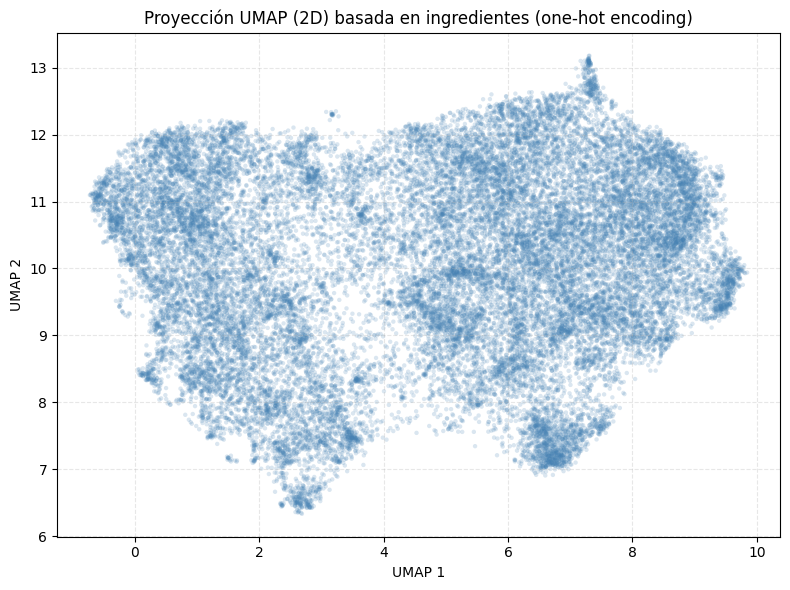

In [54]:
# =============================================================
# Visualización UMAP basada en ingredientes (one-hot)
# =============================================================

plt.figure(figsize=(8, 6))
plt.scatter(
    df_umap_ingredientes['UMAP_1'], 
    df_umap_ingredientes['UMAP_2'],
    s=10, 
    alpha=0.2, 
    color='steelblue',
    edgecolors='none'
)

plt.title("Proyección UMAP (2D) basada en ingredientes (one-hot encoding)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/one_hot_ingredients_con_UMAP.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara la visualización obtenida con los <strong>embeddings semánticos</strong> (generados con MiniLM) 
    y la nueva proyección obtenida a partir de la <strong>representación one-hot</strong> de los ingredientes.
    Describe las principales diferencias que observes entre ambas.
  </p>
  <p>
    Justifica tu respuesta planteando una <strong>hipótesis</strong> sobre por qué los puntos se organizan de forma distinta 
    en cada caso. Puedes reflexionar sobre qué tipo de información captura cada representación y cómo eso afecta a la estructura 
    de los grupos observados.
  </p>
</div>

Las dos visualizaciones revelan diferencias fundamentales en cómo cada representación captura la información de las recetas.

**La proyección con embeddings semánticos** muestra una estructura fragmentada en múltiples clusters bien diferenciados, separados por espacios vacíos significativos. Los puntos forman "islas" distintas que sugieren agrupaciones naturales por tipos de cocina o categorías culinarias. Esta distribución refleja cómo MiniLM captura relaciones de significado: entiende que "mozzarella" y "parmesano" son conceptualmente similares, que ciertos ingredientes definen tradiciones culinarias específicas, y que existe una jerarquía semántica entre los alimentos. Los clusters probablemente, como se vio en apartados anteriores, corresponden a cocina italiana, asiática, postres y otras categorías, mientras que los espacios vacíos representan las brechas conceptuales entre estos dominios culinarios.

En contraste, **la proyección one-hot** produce una masa compacta y prácticamente circular, con densidad uniforme y sin separaciones claras. Esta representación solo codifica presencia o ausencia de ingredientes, tratando "sal" y "azúcar" como elementos tan diferentes entre sí como "sal" y "chocolate". Sin información semántica, la similitud se reduce a mera coocurrencia estadística. La continuidad del espacio surge porque la mayoría de recetas comparten ingredientes básicos comunes (pej.,sal, aceite, agua) creando transiciones graduales donde todas las recetas están "algo relacionadas" sin estructura significativa.

Por lo tanto, podriamos observando ambas visualizaciones evidenciar que la diferencia esencial es que los embeddings semánticos revelan la arquitectura conceptual subyacente de la gastronomía, mientras que el one-hot encoding solo detecta patrones superficiales de ingredientes compartidos, incapaz de distinguir entre similitudes culinarias verdaderas y coincidencias estadísticas.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> A partir de la nueva representación <strong>one-hot de ingredientes</strong>, decide qué 
    <strong>algoritmo de clustering</strong> utilizarías para agrupar las recetas. 
    Explica si mantendrías el mismo algoritmo usado en el caso anterior o si elegirías otro, 
    justificando tu decisión en función de la estructura observada en los datos.
  </p>
  <p>
    Si el algoritmo elegido requiere una <strong>métrica de similitud o distancia</strong>, 
    indica cuál utilizarías (por ejemplo, <em>Jaccard</em>, <em>coseno</em> o <em>euclídea</em>) 
    y argumenta por qué resulta más adecuada para este tipo de datos binarios.
  </p>
</div>

En esta situación la métrica euclídea es **inapropiada** para estos datos. Trata la "co-presencia" (dos recetas tienen un ingrediente, 1-1) y la "co-ausencia" (ninguna tiene el ingrediente, 0-0) con la misma importancia. Dado que los datos son 99.89% ceros, la similitud estaría dominada por la abrumadora e irrelevante cantidad de ingredientes que dos recetas *no usan*, ocultando la verdadera señal. Por lo tanto, para datos binarios asimétricos, se debe usar una métrica que ignore las co-ausencias 0-0. He evaluado las dos siguientes:
    * La **Distancia Jaccard** es ideal, ya que está diseñada para comparar conjuntos (mide la intersección sobre la unión de los ingredientes presentes).
    * La **Distancia Coseno** también es excelente (y muy usada en minería de texto, un problema análogo), ya que al normalizar los vectores, ignora eficazmente los 0-0.

Ambas, Coseno y Jaccard, son candidatas viables, y por ello se incluyeron en la búsqueda de hiperparámetros para determinar cuál generaba una mejor estructura para el clustering.

Con respecto al algoritmo de clustering, en este caso no se utilizaría un algoritmo de clustering (como K-Means o DBSCAN) *directamente* sobre la matriz *one-hot* de 8.721 dimensiones. Hacerlo sufriría la "maldición de la dimensionalidad", siendo computacionalmente intratable y produciendo resultados pobres. En su lugar, se propone el siguiente **flujo de trabajo** pero optimizado para el clustering:

1.  **Reducción de Dimensión (UMAP):** Primero, se aplica UMAP a la matriz *one-hot*. La ventaja clave es que podemos configurar UMAP para que use una métrica de distancia apropiada (como `cosine` o `jaccard`) al construir su representación de baja dimensión (N-D). Esto "comprime" las 8.721 dimensiones en un espacio N-D denso, preservando las relaciones de similitud que nos interesan.
2.  **Clustering (HDBSCAN):** Segundo, se aplica **HDBSCAN** al *embedding* N-D resultante de UMAP. Se mantiene HDBSCAN (y no se cambia a K-Means, por ejemplo) porque es el ["compañero" ideal para UMAP](https://medium.com/@ps.deeplearning.training/hdbscan-clustering-and-umap-visualisation-f31e653f7218). Las proyecciones de UMAP crean clústeres de densidad variable y formas complejas, y HDBSCAN es el algoritmo más robusto para identificar estos grupos y, crucialmente, para **identificar el ruido** (recetas que no pertenecen a ningún grupo claro).

> **Nota sobre métricas:** La métrica (`cosine`/`jaccard`) se usa en el Paso 1 (UMAP, sobre los datos *one-hot*). La métrica para el Paso 2 (HDBSCAN, sobre el *embedding* denso) es la **euclídea**, ya que en este nuevo espacio N-D, la distancia "normal" ya es significativa.

Para decidir la combinación óptima, se realicé una búsqueda de hiperparámetros anidada, probando las métricas (`cosine`, `jaccard`), el número de componentes de UMAP (10, 20, 30, 50, 70, 100) y varios parámetros de HDBSCAN (`min_cluster_size`, `min_samples`).

De la tabla comparativa del analisis de resultados se observan 3 puntos principales:

1.  **Hallazgo 1: Los "Mega-Clústeres"**. Los resultados estadísticamente "mejores" (con menor ruido, 5%-25%) agrupan los datos en solo **2 o 3 clústeres gigantes**. La métrica `jaccard` es especialmente efectiva en encontrar esta estructura principal (ej., `jaccard`, 50 componentes, `mcs=200`, `ms=50` produce 2 clústeres con solo 5.31% de ruido).
2.  **Problema de Interpretabilidad**. Aunque estadísticamente robustos, estos 2-3 clústeres (probablemente "Recetas Dulces" vs. "Recetas Saladas") no son útiles para el objetivo de agrupar distintos tipos de recetas.
3.  **Hallazgo 2: El "Punto Dulce" (*Sweet Spot*)**. Se debe descartar intencionalmente el ruido más bajo y buscar el "punto dulce". Es decir, identificar la combinación que ofrezca un número interpretable de clústeres (ej. 10-15) con el *siguiente* nivel de ruido más bajo.

Comparando los mejores candidatos "útiles", he optado por los dos siguientes:

* **Opción A (Coseno):** `umap_metric='cosine'`, `umap_components=30`, `mcs=200`, `ms=50`.
    * **Resultado:** **12 clústeres** con **42.87% de ruido**.
* **Opción B (Jaccard):** `umap_metric='jaccard'`, `umap_components=10`, `mcs=200`, `ms=50`.
    * **Resultado:** 13 clústeres con 48.70% de ruido.

In [7]:
# --- PASO 1: Definir los parámetros fijos de UMAP ---
# (Estos son los que ya habías validado y funcionaban bien)
NEIGHBORS = 15
MIN_DIST = 0.1
RANDOM_STATE = 42

# --- PASO 2: Definir las parrillas de parámetros a probar ---

# Parrilla de MÉTRICAS UMAP (Bucle exterior)
umap_metric_list = ['cosine', 'jaccard']

# Parrilla de Componentes de UMAP (el nuevo bucle exterior)
# Probemos con 10, 20, 30 y 50 componentes.
umap_components_list = [10, 20, 30, 50, 70, 100]

# Parrilla de Parámetros de HDBSCAN (el bucle interior)
hdbscan_param_grid = [
    (20, 10), (30, 10), (50, 10), (80, 10),
    (30, 15), (50, 15), (80, 15), (100, 15),
    (50, 20), (80, 20), (100, 20), (150, 20),
    (100, 30), (200, 50)
]

# --- PASO 3: Ejecutar la búsqueda anidada ---

# Lista para guardar TODOS los resultados de todas las combinaciones
all_results = []
total_recetas = len(df_ingredientes_onehot)

print("Iniciando búsqueda anidada (UMAP n_components + HDBSCAN params)...")
print(f"Total de recetas a clusterizar: {total_recetas}\n")

print(f"Iniciando búsqueda anidada sobre {total_recetas} recetas...")

# ---- BUCLE EXTERIOR: MÉTRICA UMAP ----
for metric in umap_metric_list:

    # ---- BUCLE MEDIO: COMPONENTES UMAP ----
    for n_comp in umap_components_list:
        
        print(f"\n=====================================================================")
        print(f"GENERANDO EMBEDDING UMAP (Métrica: '{metric}', Componentes: {n_comp})")
        print(f"=======================================================================")
        
        # 1. Instanciar y aplicar UMAP
        reducer_nd = umap.UMAP(
            n_components=n_comp,
            metric=metric,
            n_neighbors=NEIGHBORS,
            min_dist=MIN_DIST,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        
        # Aplicamos la transformación a la MUESTRA DENSA
        start_umap = time.time()
        # Esta línea ahora usa el DataFrame muestreado
        embedding_nd = reducer_nd.fit_transform(df_ingredientes_onehot) 
        end_umap = time.time()
        
        print(f"Representación {n_comp}-D ('{metric}') creada. Forma: {embedding_nd.shape} (Tardó {end_umap - start_umap:.2f}s)")
        print(f"Iniciando la prueba de {len(hdbscan_param_grid)} combinaciones de HDBSCAN...")

        # ---- BUCLE INTERNO: HDBSCAN ----
        for mcs, ms in hdbscan_param_grid:
            
            print(f"  --- Probando UMAP('{metric}', {n_comp}) + HDBSCAN(mcs={mcs}, ms={ms}) ---")
            start_hdbscan = time.time()
            
            # 2. Configurar el clusterer
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric='euclidean',
                cluster_selection_method='eom',
                core_dist_n_jobs=-1
            )
            
            # 3. Ajustar y predecir
            cluster_labels = clusterer.fit_predict(embedding_nd)
            
            end_hdbscan = time.time()
            
            # 4. Calcular métricas
            n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
            n_noise = list(cluster_labels).count(-1)
            percent_noise = (n_noise / total_recetas) * 100 # Se usa total_recetas (SAMPLE_SIZE)
            duration_hdbscan = end_hdbscan - start_hdbscan
            
            # 5. Guardar resultados
            all_results.append({
                'umap_metric': metric,
                'umap_components': n_comp,
                'min_cluster_size': mcs,
                'min_samples': ms,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'percent_noise': percent_noise,
                'duration_hdbscan_sec': duration_hdbscan
            })
            
            print(f"      Resultado: {n_clusters} clústeres, {n_noise} puntos de ruido ({percent_noise:.2f}%)")

print("\n--- Pruebas completadas. ---")

# --- PASO 4: Crear la tabla comparativa final ---

df_results = pd.DataFrame(all_results)

# Ordenamos por el mejor candidato
# Criterio: 1. Menor ruido, 2. Más clústeres (manejables), 3. Menos componentes UMAP
df_results = df_results.sort_values(
    by=['percent_noise', 'n_clusters', 'umap_components'],
    ascending=[True, False, True]
)

# Formateamos para legibilidad
df_results['percent_noise'] = df_results['percent_noise'].map('{:.2f}%'.format)
df_results['duration_hdbscan_sec'] = df_results['duration_hdbscan_sec'].map('{:.2f}s'.format)

print("\n### Tabla Comparativa de Resultados (Ordenada por mejor candidato) ###")
pd.set_option('display.max_rows', None) # Para que muestre todas las filas
pd.set_option('display.width', 1000)    # Para que la tabla se vea ancha
print(df_results)

Iniciando búsqueda anidada (UMAP n_components + HDBSCAN params)...
Total de recetas a clusterizar: 30000

Iniciando búsqueda anidada sobre 30000 recetas...

GENERANDO EMBEDDING UMAP (Métrica: 'cosine', Componentes: 10)
Representación 10-D ('cosine') creada. Forma: (30000, 10) (Tardó 125.21s)
Iniciando la prueba de 14 combinaciones de HDBSCAN...
  --- Probando UMAP('cosine', 10) + HDBSCAN(mcs=20, ms=10) ---
      Resultado: 86 clústeres, 18243 puntos de ruido (60.81%)
  --- Probando UMAP('cosine', 10) + HDBSCAN(mcs=30, ms=10) ---
      Resultado: 66 clústeres, 18434 puntos de ruido (61.45%)
  --- Probando UMAP('cosine', 10) + HDBSCAN(mcs=50, ms=10) ---
      Resultado: 2 clústeres, 3614 puntos de ruido (12.05%)
  --- Probando UMAP('cosine', 10) + HDBSCAN(mcs=80, ms=10) ---
      Resultado: 2 clústeres, 3614 puntos de ruido (12.05%)
  --- Probando UMAP('cosine', 10) + HDBSCAN(mcs=30, ms=15) ---
      Resultado: 64 clústeres, 18595 puntos de ruido (61.98%)
  --- Probando UMAP('cosine', 10

In [7]:
# ============================================================================
# OPCIÓN A: cosine, 30 componentes, min_cluster_size=200, min_samples=50
# Resultado esperado: 12 clústeres, 42.87% de ruido
# ============================================================================

print("=" * 80)
print("OPCIÓN A: UMAP(cosine, 30) + HDBSCAN(mcs=200, ms=50)")
print("=" * 80)

# Reducción dimensional con UMAP
umap_model_a = umap.UMAP(
    n_components=30,
    metric='cosine',
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    verbose=False
)

embedding_a = umap_model_a.fit_transform(df_ingredientes_onehot)

# Clustering con HDBSCAN
clusterer_a = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=50,
    metric='euclidean',
    cluster_selection_method='eom',
    core_dist_n_jobs=-1
)

labels_a = clusterer_a.fit_predict(embedding_a)

# Métricas
n_clusters_a = len(set(labels_a)) - (1 if -1 in labels_a else 0)
n_noise_a = list(labels_a).count(-1)
percent_noise_a = (n_noise_a / len(labels_a)) * 100
n_clustered_a = len(labels_a) - n_noise_a

print("\nRESULTADOS OPCIÓN A:")
print(f"Número de clústeres: {n_clusters_a}")
print(f"Puntos clusterizados: {n_clustered_a} ({100 - percent_noise_a:.2f}%)")
print(f"Puntos de ruido: {n_noise_a} ({percent_noise_a:.2f}%)")

# Agregar resultados al DataFrame
df_final['cluster_opcionA'] = labels_a

# ============================================================================
# OPCIÓN B: jaccard, 10 componentes, min_cluster_size=200, min_samples=50
# Resultado esperado: 13 clústeres, 48.70% de ruido
# ============================================================================

print("\n" + "=" * 80)
print("OPCIÓN B: UMAP(jaccard, 10) + HDBSCAN(mcs=200, ms=50)")
print("=" * 80)

# Reducción dimensional con UMAP
umap_model_b = umap.UMAP(
    n_components=10,
    metric='jaccard',
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    verbose=False
)

embedding_b = umap_model_b.fit_transform(df_ingredientes_onehot)

# Clustering con HDBSCAN
clusterer_b = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=50,
    metric='euclidean',
    cluster_selection_method='eom',
    core_dist_n_jobs=-1
)

labels_b = clusterer_b.fit_predict(embedding_b)

# Métricas
n_clusters_b = len(set(labels_b)) - (1 if -1 in labels_b else 0)
n_noise_b = list(labels_b).count(-1)
percent_noise_b = (n_noise_b / len(labels_b)) * 100
n_clustered_b = len(labels_b) - n_noise_b

print("\nRESULTADOS OPCIÓN B:")
print(f"Número de clústeres: {n_clusters_b}")
print(f"Puntos clusterizados: {n_clustered_b} ({100 - percent_noise_b:.2f}%)")
print(f"Puntos de ruido: {n_noise_b} ({percent_noise_b:.2f}%)")

# Agregar resultados al DataFrame
df_final['cluster_opcionB'] = labels_b


# ============================================================================
# RESUMEN COMPARATIVO
# ============================================================================

print("\n" + "=" * 80)
print("RESUMEN COMPARATIVO")
print("=" * 80)

resumen = pd.DataFrame({
    'Opción': ['Opción A', 'Opción B'],
    'Métrica UMAP': ['cosine', 'jaccard'],
    'Componentes': [30, 10],
    'N° Clusters': [n_clusters_a, n_clusters_b],
    'Recetas Clusterizadas': [n_clustered_a, n_clustered_b],
    'Ruido (%)': [f"{percent_noise_a:.2f}%", f"{percent_noise_b:.2f}%"]
})

print("\n", resumen.to_string(index=False))

OPCIÓN A: UMAP(cosine, 30) + HDBSCAN(mcs=200, ms=50)

RESULTADOS OPCIÓN A:
Número de clústeres: 12
Puntos clusterizados: 17140 (57.13%)
Puntos de ruido: 12860 (42.87%)

OPCIÓN B: UMAP(jaccard, 10) + HDBSCAN(mcs=200, ms=50)

RESULTADOS OPCIÓN B:
Número de clústeres: 13
Puntos clusterizados: 15389 (51.30%)
Puntos de ruido: 14611 (48.70%)

RESUMEN COMPARATIVO

   Opción Métrica UMAP  Componentes  N° Clusters  Recetas Clusterizadas Ruido (%)
Opción A       cosine           30           12                  17140    42.87%
Opción B      jaccard           10           13                  15389    48.70%


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el conjunto de datos original (la proyección 2D obtenida con <code>UMAP</code>) 
    coloreando cada punto según el <strong>cluster</strong> al que pertenece. 
</div>

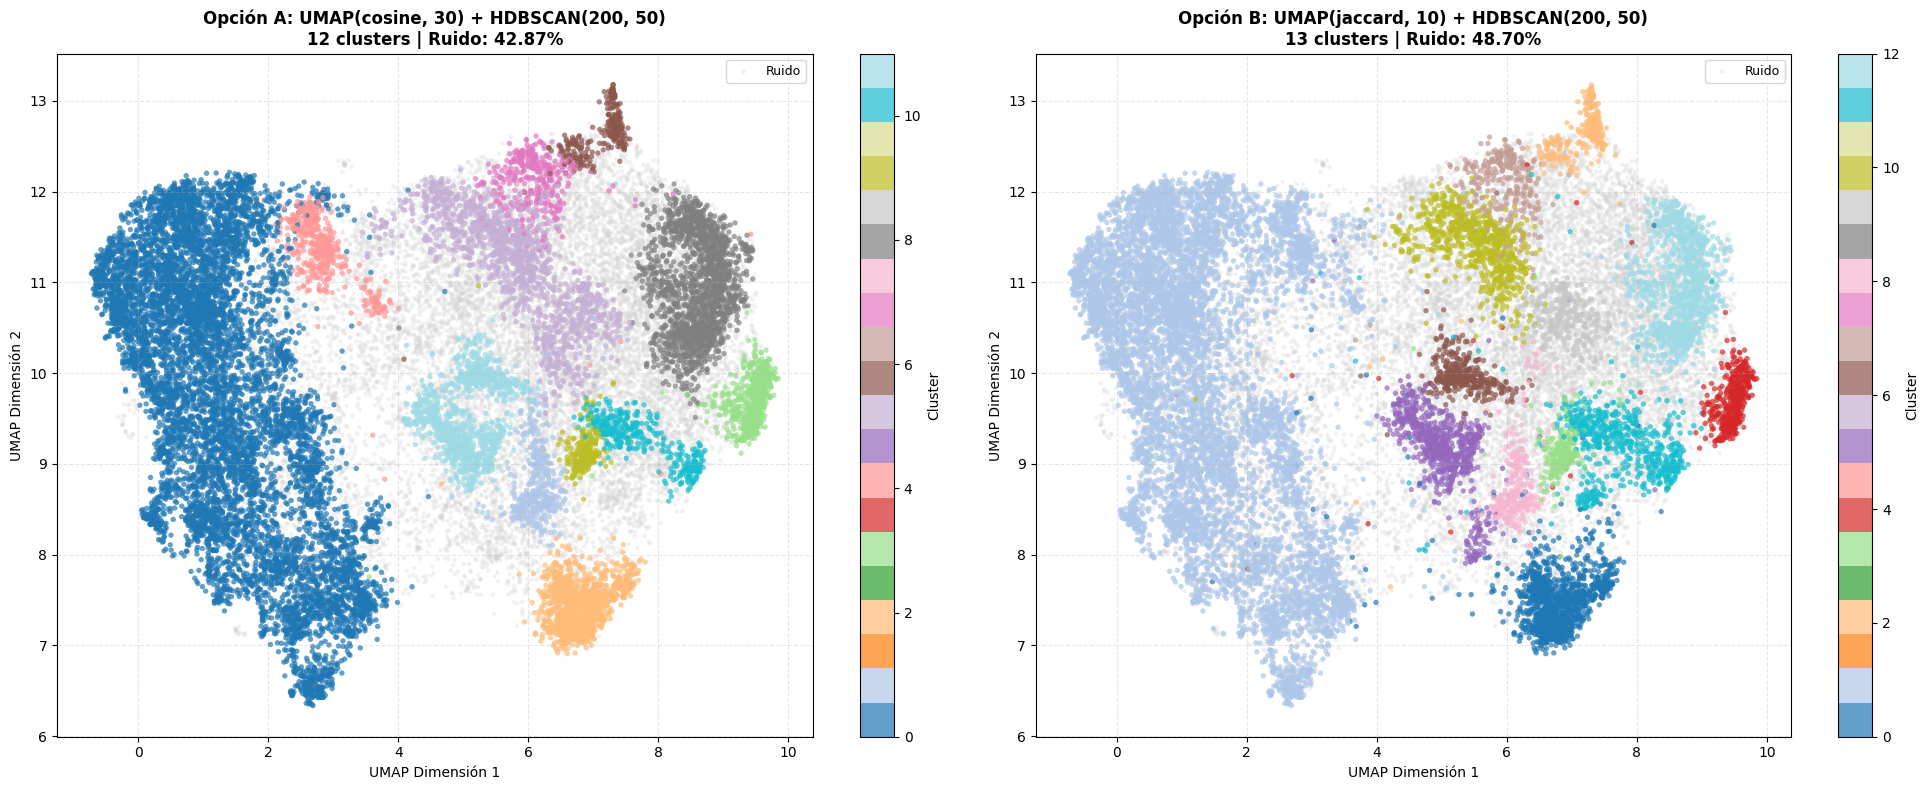

In [ ]:
# ============================================================================
# GENERAR PROYECCIÓN 2D CON UMAP
# ============================================================================

umap_2d = umap.UMAP(
    n_components=2,
    metric='cosine',
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    verbose=False
)

embedding_2d = umap_2d.fit_transform(df_ingredientes_onehot)

# ============================================================================
# VISUALIZACIÓN COMPARATIVA (OPCIÓN A Y OPCIÓN B)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- OPCIÓN A ---
ax1 = axes[0]

labels_a = df_final['cluster_opcionA'].values
noise_mask_a = labels_a == -1
clustered_mask_a = ~noise_mask_a

# Ruido
if noise_mask_a.sum() > 0:
    ax1.scatter(
        embedding_2d[noise_mask_a, 0],
        embedding_2d[noise_mask_a, 1],
        c='lightgray',
        s=10,
        alpha=0.3,
        label='Ruido',
        edgecolors='none'
    )

# Clusters
if clustered_mask_a.sum() > 0:
    scatter1 = ax1.scatter(
        embedding_2d[clustered_mask_a, 0],
        embedding_2d[clustered_mask_a, 1],
        c=labels_a[clustered_mask_a],
        cmap='tab20',
        s=15,
        alpha=0.7,
        edgecolors='none'
    )
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Cluster', fontsize=10)

n_clusters_a = len(set(labels_a)) - (1 if -1 in labels_a else 0)
n_noise_a = (labels_a == -1).sum()
percent_noise_a = (n_noise_a / len(labels_a)) * 100

ax1.set_title(
    f'Opción A: UMAP(cosine, 30) + HDBSCAN(200, 50)\n'
    f'{n_clusters_a} clusters | Ruido: {percent_noise_a:.2f}%',
    fontsize=12,
    fontweight='bold'
)
ax1.set_xlabel('UMAP Dimensión 1', fontsize=10)
ax1.set_ylabel('UMAP Dimensión 2', fontsize=10)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')


# --- OPCIÓN B ---
ax2 = axes[1]

labels_b = df_final['cluster_opcionB'].values
noise_mask_b = labels_b == -1
clustered_mask_b = ~noise_mask_b

# Ruido
if noise_mask_b.sum() > 0:
    ax2.scatter(
        embedding_2d[noise_mask_b, 0],
        embedding_2d[noise_mask_b, 1],
        c='lightgray',
        s=10,
        alpha=0.3,
        label='Ruido',
        edgecolors='none'
    )

# Clusters
if clustered_mask_b.sum() > 0:
    scatter2 = ax2.scatter(
        embedding_2d[clustered_mask_b, 0],
        embedding_2d[clustered_mask_b, 1],
        c=labels_b[clustered_mask_b],
        cmap='tab20',
        s=15,
        alpha=0.7,
        edgecolors='none'
    )
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Cluster', fontsize=10)

n_clusters_b = len(set(labels_b)) - (1 if -1 in labels_b else 0)
n_noise_b = (labels_b == -1).sum()
percent_noise_b = (n_noise_b / len(labels_b)) * 100

ax2.set_title(
    f'Opción B: UMAP(jaccard, 10) + HDBSCAN(200, 50)\n'
    f'{n_clusters_b} clusters | Ruido: {percent_noise_b:.2f}%',
    fontsize=12,
    fontweight='bold'
)
ax2.set_xlabel('UMAP Dimensión 1', fontsize=10)
ax2.set_ylabel('UMAP Dimensión 2', fontsize=10)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(r'../Visualizaciones/OpcionAyB_UMAP_HDBSCAN.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y comprobar su coherencia, selecciona los <strong>10 clusters</strong> más grandes y muestra, para cada uno:
  <ol>
    <li>
      Las <strong>5 recetas más cercanas al centroide</strong> del cluster (si el método lo define). 
      Si no hay centroide, usa el <em>centroide empírico</em> (media del vector del cluster) o el <em>medoide</em> 
      (receta con menor distancia media al resto). Emplea una métrica adecuada a la representación.
    </li>
    <li>
      También, para cada cluster, muestra los <strong>ingredientes más repetidos</strong> del cluster (por ejemplo, top-3 o top-5), opcionalmente puedes indicar su frecuencia relativa
      para caracterizar el “tema” del grupo. Puedes agrupar y contar con utilidades tipo 
      <code>Counter</code> o transformaciones previas del one-hot.
    </li>
  </ol>
</div>

In [ ]:
# ============================================================================
# ANÁLISIS PARA OPCIÓN A
# ============================================================================

print("\n\n")
analizar_clusters_onehot(
    df_final=df_final,
    df_ingredientes_onehot=df_ingredientes_onehot,
    embedding=embedding_a,
    labels=labels_a,
    nombre_opcion="OPCIÓN A: UMAP(cosine, 30) + HDBSCAN",
    top_n_clusters=10,
    top_recetas=5,
    top_ingredientes=5
)

# ============================================================================
# ANÁLISIS PARA OPCIÓN B
# ============================================================================

print("\n\n")
analizar_clusters_onehot(
    df_final=df_final,
    df_ingredientes_onehot=df_ingredientes_onehot,
    embedding=embedding_b,
    labels=labels_b,
    nombre_opcion="OPCIÓN B: UMAP(jaccard, 10) + HDBSCAN",
    top_n_clusters=10,
    top_recetas=5,
    top_ingredientes=5
)

# ============================================================================
# COMPARACIÓN DE COHERENCIA TEMÁTICA
# ============================================================================

coherencias_a = evaluar_coherencia_tematica(df_ingredientes_onehot, labels_a, "OPCIÓN A")
coherencias_b = evaluar_coherencia_tematica(df_ingredientes_onehot, labels_b, "OPCIÓN B")

# ============================================================================
# RESUMEN FINAL
# ============================================================================

print("\n\n" + "=" * 100)
print("RESUMEN EJECUTIVO")
print("=" * 100)

print(f"""
OPCIÓN A (UMAP cosine, 30 componentes):
  • {n_clusters_a} clusters identificados
  • {n_clustered_a} recetas clusterizadas ({100 - percent_noise_a:.2f}%)
  • Coherencia temática media: {np.mean(coherencias_a):.4f}

OPCIÓN B (UMAP jaccard, 10 componentes):
  • {n_clusters_b} clusters identificados
  • {n_clustered_b} recetas clusterizadas ({100 - percent_noise_b:.2f}%)
  • Coherencia temática media: {np.mean(coherencias_b):.4f}

RECOMENDACIÓN:
{'OPCIÓN A' if np.mean(coherencias_a) > np.mean(coherencias_b) else 'OPCIÓN B'} muestra mejor coherencia temática intra-cluster.
{'OPCIÓN A' if n_clustered_a > n_clustered_b else 'OPCIÓN B'} captura más recetas en clusters significativos.
""")




ANÁLISIS DE CLUSTERS - OPCIÓN A: UMAP(cosine, 30) + HDBSCAN

Analizando los 10 clusters más grandes:
Tamaños: [8959, 1767, 1495, 1135, 1061, 569, 494, 420, 377, 358]


CLUSTER 0 (Ranking #1) - Tamaño: 8959 recetas

📋 TOP 5 RECETAS MÁS CERCANAS AL CENTROIDE:
----------------------------------------------------------------------------------------------------
1. Praline Graham Crackers
   Distancia al centroide: 0.3148
2. Lavender Nougat
   Distancia al centroide: 0.3949
3. New England Hot Chocolate
   Distancia al centroide: 0.4019
4. Crown Sundae
   Distancia al centroide: 0.4195
5. Apple Meringue Pie
   Distancia al centroide: 0.4205

🥘 TOP 5 INGREDIENTES MÁS FRECUENTES:
----------------------------------------------------------------------------------------------------
  • sugar: 3932 recetas (43.9%)
  • salt: 3423 recetas (38.2%)
  • butter: 3192 recetas (35.6%)
  • eggs: 2965 recetas (33.1%)
  • baking powder: 2199 recetas (24.5%)


CLUSTER 8 (Ranking #2) - Tamaño: 1767 recetas



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Analiza los resultados del clustering y valora si los <strong>clusters obtenidos tienen sentido</strong> 
    desde un punto de vista culinario. Observa los ingredientes más frecuentes y las recetas prototipo 
    de cada grupo, e identifica si existe un patrón claro que relacione los platos entre sí.
</div>

Los resultados del clustering son realmente satisfactorios desde una perspectiva gastronómica. Ambas opciones han logrado identificar grupos de recetas que tienen mucho sentido culinario, con patrones claros que relacionan los platos entre sí.

* **Intepretación de la Opción A**

El cluster más grande, con casi 9,000 recetas, agrupa toda la repostería y horneados occidentales. Esto se confirma perfectamente al ver que el 44% de las recetas contienen azúcar, 36% mantequilla, 33% huevos y 25% levadura química. Las recetas más representativas como Praline Graham Crackers y Apple Meringue Pie lo confirman: estamos ante el universo de galletas, pasteles y postres horneados.

Pero lo interesante viene cuando vemos los otros clusters. Hay uno de 1,767 recetas donde el aceite de oliva aparece en el 94% de ellas, acompañado de ajo en la mitad. Las recetas prototipo incluyen ensalada de atún, gratinados mediterráneos y bacalao con pesto. Es claramente cocina mediterránea, y el aceite de oliva funciona como marcador inequívoco.

El algoritmo también identificó un cluster de cocina asiática impecable: 1,135 recetas donde la salsa de soja aparece en el 63%, junto con aceite de sésamo y jengibre fresco. Las recetas de chow mein, sopa de ostras china y salteados lo confirman. La separación es limpia y coherente.

Hay clusters más específicos que demuestran la sensibilidad del algoritmo. Uno agrupa 494 recetas de panes artesanales, donde el 87% contiene sal, 63% agua y 24% levadura activa. Se distingue perfectamente de la repostería dulce: aquí están los panes de masa madre, los de trigo integral, los artesanales. La separación entre panadería dulce y salada es cristalina.

Otro cluster fascinante agrupa 420 recetas con una tríada característica: ketchup (64%), azúcar moreno (56%) y salsa worcestershire (53%). Son todas las salsas barbacoa americanas y carnes glaseadas. Las albóndigas con arándanos y costillas con salsa BBQ son sus representantes perfectos.

El cluster tex-mex también es notable: 377 recetas donde el chile en polvo aparece en el 62% y el comino en el 30%. Chicken chili, frijoles mexicanos, todo tiene sentido. Las especias delatan inmediatamente la categoría culinaria.

* **Intepretación de la Opción B**

La Opción B mantiene categorías similares pero con una diferencia crucial: logra separar la cocina mexicana en dos clusters distintos. Por un lado está el cluster tradicional con chile en polvo y comino (685 recetas), y por otro aparece un cluster específico de 385 recetas dedicado a tacos y comida tex-mex rápida, donde dominan la crema agria (39%), salsa (37%), carne molida (30%) y queso cheddar (30%).

Esta distinción es valiosa porque refleja una diferencia real en la cocina: una cosa son los guisos y chilis mexicanos tradicionales, y otra los tacos y enchiladas de preparación rápida con sus ingredientes característicos. La Opción B captura esta granularidad.

Además, el cluster de dips y ensaladas cremosas está mejor definido aquí: la mayonesa aparece en el 65% de las recetas versus el 45% en la Opción A. Los clusters son más "puros" temáticamente.


* **Comparativa entre opciones**

Ambas opciones funcionan excepcionalmente bien desde el punto de vista culinario. No hay clusters incoherentes ni mezclas extrañas de categorías. Los ingredientes más frecuentes siempre tienen sentido para las recetas representativas de cada grupo.

Por lo tanto, dependiendo del objetivo usaría uno u otro: 

- Si el objetivo es construir un sistema de recomendación o una aplicación práctica, la Opción A es más conveniente porque captura más recetas en clusters útiles. Perder un 2% de coherencia a cambio de tener un 6% más de recetas categorizadas es un trade-off razonable.
- Si el objetivo es investigación gastronómica o análisis culinario detallado, la Opción B ofrece mayor precisión y granularidad. La distinción entre cocina mexicana tradicional y tex-mex rápida es valiosa para entender subcategorías culinarias.

Sin embargo, para la mayoría de casos prácticos, recomendaría la Opción A por su mejor balance entre cobertura y coherencia. Pero ambas opciones demuestran que el clustering ha funcionado: los grupos obtenidos tienen sentido culinario real, los ingredientes definen claramente las categorías, y las recetas prototipo confirman la coherencia temática de cada cluster.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara los resultados obtenidos en este apartado (basados en la representación <strong>one-hot de ingredientes</strong>)
    con los del primer apartado (embeddings semánticos generados con <strong>MiniLM</strong>).
    Analiza si los grupos que aparecen son similares o diferentes, reflexiona sobre cómo influye el tipo de representación y explica las principales diferencias observadas.
</div>

El presente análisis examina las diferencias conceptuales y operativas entre dos enfoques de clustering aplicados al dataset de recetas:

1. **Embeddings semánticos mediante MiniLM combinados con K-Means**, y
2. **Representación one-hot de ingredientes reducida con UMAP y agrupada con HDBSCAN**.

Ambos métodos generan particiones válidas, pero cada uno refleja una concepción distinta de la similitud entre recetas, lo que conduce a estructuras de clusters claramente diferenciadas.

**1. Clustering basado en embeddings MiniLM: organización semántica**

El uso de embeddings MiniLM permite modelizar cada receta como un vector denso de características que capturan información contextual y semántica presente en los textos asociados (descripción, instrucciones, ingredientes, etc.).
Esta representación facilita que el algoritmo de clustering identifique **relaciones de significado más amplias**, no limitadas a la co-ocurrencia de ingredientes.

Los clusters generados por este enfoque presentan las siguientes características:

* Agrupan recetas según **categorías culinarias conceptuales**, tales como repostería, platos con pollo, preparaciones vegetales, pastas, guisos o ensaladas.
* Integran elementos diversos que comparten función, estilo o propósito culinario, aun cuando difieran en su composición exacta de ingredientes.
* Presentan mayor **coherencia temática** y un nivel de generalización similar al que realizaría un experto humano.

Así, recetas como *cookies*, *brownies* o *bars* suelen quedar agregadas en un mismo cluster, pese a variaciones sustanciales en las combinaciones de ingredientes, debido a su proximidad semántica y funcional.

**2. Clustering basado en One-Hot + UMAP + HDBSCAN: estructuras basadas en perfiles de ingredientes**

El enfoque alternativo utiliza una representación estrictamente binaria de los ingredientes, ignorando información textual o contextual. Posteriormente, UMAP reduce la dimensionalidad preservando relaciones locales, y HDBSCAN identifica densidades de co-ocurrencia.

Los clusters derivados presentan un comportamiento complementario:

* Se organizan alrededor de **firmas de ingredientes** dominantes, como combinaciones recurrentes de mantequilla–harina–azúcar, aceite de oliva–ajo, soja–jengibre, entre otras.
* Diferencian con precisión familias de preparaciones basadas en componentes característicos (p. ej., dips con queso crema y mayonesa, marinados con salsa de soja).
* Muestran alta especificidad: recetas semánticamente diversas pueden agruparse si comparten ingredientes clave.

En este caso, los clusters representan **patrones composicionales**, lo que proporciona una visión más “química” o estructural del mundo culinario.

**3. Correspondencia entre clusters: baja equivalencia estructural**

A pesar de algunas coincidencias superficiales (por ejemplo, la presencia de un macrogrupo relacionado con la repostería), la correspondencia entre clusters generados por ambos métodos es, en general, limitada.

* **En MiniLM:**

  * Los grupos son amplios, semánticos y temáticos.
  * Se basan en el significado funcional y estilístico de las recetas.

* **En One-Hot + UMAP + HDBSCAN:**

  * Los grupos son más estrechos y definidos por combinaciones concretas de ingredientes.
  * Ignoran la semántica del plato y privilegian la estructura composicional.

Consecuentemente, los clusters no son equivalentes, ya que cada enfoque enfatiza una dimensión distinta de la similitud.

**4. Influencia del tipo de representación sobre la estructura de clusters**

La divergencia entre ambos métodos puede explicarse por las propiedades intrínsecas de las representaciones empleadas:

* **Embeddings MiniLM**

  * Capturan **significados**, estilos culinarios y funciones gastronómicas.
  * Permiten agrupar recetas heterogéneas que comparten un rol culinario.
  * Son robustos ante variaciones en los ingredientes o proporciones.
  * Producen clusters amplios y conceptualmente homogéneos.

* **One-Hot + UMAP + HDBSCAN**

  * Capturan únicamente **patrones de co-ocurrencia de ingredientes**.
  * Identifican agrupaciones basadas en composiciones recurrentes.
  * Son sensibles al uso o ausencia de ingredientes específicos.
  * Producen clusters densos y muy específicos.

Ambas estrategias resultan complementarias: una ofrece una visión semántica global y la otra revela estructuras composicionales detalladas.

**5. Conclusión**

Los resultados muestran que **los embeddings MiniLM y la representación one-hot reducida con UMAP conducen a conceptualizaciones distintas del espacio culinario**.
Mientras los embeddings permiten identificar categorías temáticas y funcionales coherentes, las representaciones basadas en ingredientes destacan patrones de co-ocurrencia que no siempre se corresponden con categorías gastronómicas tradicionales.

Lejos de ser contradictorios, ambos enfoques proporcionan perspectivas complementarias. Combinarlos puede enriquecer el análisis y ofrecer una caracterización más completa del dominio culinario, integrando tanto el significado semántico de las recetas como su composición material.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Reflexiona sobre los posibles <strong>casos de uso</strong> de los dos enfoques de clustering aplicados:
  <ul>
    <li>
      ¿Para qué tipo de problema o aplicación sería más útil el clustering basado en los 
      <strong>embeddings semánticos</strong> (MiniLM)?
    </li>
    <li>
      ¿Y en qué tipo de situación resultaría más adecuado el clustering obtenido con la 
      <strong>representación one-hot de ingredientes</strong>?
    </li>
  </ul>
</div>

**1. Embeddings semánticos (MiniLM) - Similitud conceptual**

**Útil cuando interesa el *significado* de la receta**, no solo sus ingredientes si no para agrupar recetas por *intención, estilo y categoría gastronómica*.

Casos de uso:

* **Recomendadores culinarios** (“recetas parecidas a esta”, “alternativas saludables”).
* **Clasificación temática** (postres, platos asiáticos, comida rápida, brunch…).
* **Búsqueda semántica** (“platos reconfortantes”, “recetas frescas de verano”).
* **Organización de grandes colecciones** por estilo o función culinaria.
* **Análisis de tendencias y patrones culturales** en gastronomía.

**2. One-hot + UMAP + HDBSCAN - Similitud composicional**

**Útil cuando interesa la *composición* de la receta**, es decir, las combinaciones de ingredientes.

Casos de uso:

* **Identificar patrones reales de co-ocurrencia** de ingredientes.
* **Desarrollo de nuevos productos alimentarios** (bases comunes, marinados, salsas…).
* **Ingeniería de menús e inventarios** (recetas que comparten ingredientes clave).
* **Detección de recetas atípicas o inconsistencias** (HDBSCAN resalta anomalías).
* **Sugerencia o predicción de ingredientes faltantes** en una receta.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Piensa en <strong>otras maneras de generar una representación</strong> de las recetas, distintas de las vistas en la práctica 
    (como los embeddings semánticos o los vectores one-hot de ingredientes). 
    Describe brevemente cómo construirías esa nueva representación y qué tipo de información capturaría.
</div>

**1. Representación basada en procedimientos culinarios**

Este enfoque se centra en **cómo** se prepara la receta, no en qué contiene.
Consiste en transformar los pasos de elaboración en una representación estructurada que capture **acciones, técnicas y orden temporal**.

Pasos para su construccion:

A. **Procesamiento del texto** de los pasos de la receta (NLP clásico).
B. **Extracción de verbos de acción** mediante técnicas de *POS-tagging* (por ejemplo, con SpaCy).
   Ejemplos: *cortar, sofreír, hervir, amasar, marinar, batir...*
C. **Normalización de acciones** agrupando sinónimos (*freír/saltear*, *hervir/cocer*).
D. Crear:
   * **Un vector de frecuencias** de técnicas (bag-of-actions), o
   * **Una secuencia de acciones** que puede usarse con modelos de tipo *Doc2Seq* o *Transformer*.

Tipo de información a tener en cuenta:

* Estilo culinario: *salteado asiático*, *horneado europeo*, *guiso tradicional*.
* Complejidad del plato: número y variedad de procedimientos.
* Similitudes estructurales entre recetas que comparten técnicas, aunque tengan ingredientes distintos.
* Comportamientos temporales: recetas rápidas vs. elaboraciones largas.

Aplicaciones:

* Clasificación automática por **tipo de cocina** basada en técnicas.
* Sistemas de recomendación que sugieren recetas según el **nivel de habilidad** o las **herramientas disponibles**.
* Descubrimiento de estilos culinarios “emergentes” basados en procedimientos.

Bibliografía:

* **Yamakata et al. (2020)** – "*Cooking Procedure Generation with Variational Transformers*"
* **Jermsurawong & Habash (2015)** – "*Predicting the Structure of Cooking Recipes*"
* **Mori et al. (2014)** – "*Cooking Recipe Recommendation Based on Multiple Procedural Texts*".

---

**2. Representación basada en grafos (Graph Embeddings)**

Aquí las recetas se modelan como un **grafo de relaciones culinarias**, normalmente entre ingredientes, aunque también puede incluir técnicas o utensilios.

Pasos para su construccion:
A. Definir un grafo donde:

   * **Nodos** = ingredientes.
   * **Aristas** = relaciones (co-ocurrencia en una misma receta, uso conjunto recurrente, compatibilidad culinaria).

B. Asignar pesos a las aristas:

   * Frecuencia de co-ocurrencia.
   * Medidas como PMI (*Pointwise Mutual Information*).

C. Aprender embeddings con métodos como:

   * **Node2Vec** (Grover & Leskovec, 2016).
   * **DeepWalk**.
   * **GraphSAGE** (Hamilton et al., 2017).
   * Incluso **Graph Neural Networks** para modelos más avanzados.

D. Para representar una receta completa:

   * Agregar (por media, suma o atención) los embeddings de sus ingredientes; o
   * Tratar la receta como un subgrafo y generar un embedding de subgrafo.

Tipo de información a tener en cuenta:

* Patrones culinarios de co-ocurrencia (combinaciones clásicas).
* Comunidades de ingredientes (*cítricos*, *hierbas aromáticas*, *bases de sofrito*, *marinados*…).
* Compatibilidad sabor-aroma que no aparece explícita en one-hot.
* Conexiones indirectas: ingredientes que nunca co-ocurren, pero están próximos en el grafo porque comparten “vecinos”.

Aplicaciones:

* Sistemas de recomendación que sugieren **ingredientes compatibles** para completar una receta.
* Descubrimiento de **nuevas combinaciones culinarias** mediante análisis de proximidad en el grafo.
* Identificación de **ingredientes centrales** de una cocina concreta (nodos con alta centralidad).
* Clustering profundo de recetas según **estructura relacional** de sus ingredientes.

Bibliografía:

* **Ahn et al. (2011)** – "*Flavor network and the principles of food pairing*" (Science Reports).
* **Grover & Leskovec (2016)** – "*node2vec: Scalable Feature Learning for Networks*".
* **Hamilton et al. (2017)** – "*Inductive Representation Learning on Large Graphs (GraphSAGE)*".
* **Jain et al. (2015)** – "*Recipe Recommendation Using Ingredient Networks*".


---
---

# Anexo 1. Pruebas sobre datos binarios

He dedicado varios días a probar distintas combinaciones de parámetros, distancias y algoritmos. Aunque finalmente opté por la combinación UMAP + HDBSCAN y esta información no se utiliza de forma activa, considero valioso conservarla. He explorado otras alternativas y quería reflejarlas de algún modo en el documento.

## Prueba con Kmeans con distancia Jaccard

Aunque he evaluado K-Means sobre mis datos binarios utilizando tanto distancia Jaccard como métricas adicionales como Silhouette, los resultados muestran que este algoritmo **no es el método más adecuado para esta situación**. La inercia apenas cambia al incrementar *k*, el coeficiente Silhouette se mantiene en valores muy bajos y empiezan a surgir clusters diminutos a partir de ciertos valores; todo ello indica que K-Means no consigue identificar una estructura clara en un espacio tan disperso y binario. Esto es coherente con la naturaleza del algoritmo, que asume centroides basados en medias y una geometría euclídea que no representa bien la relación entre vectores one-hot.

En consecuencia, aunque es posible forzar su uso y obtener una partición, el comportamiento observado sugiere que **la forma en la que K-Means define los centroides y calcula distancias no encaja con la lógica de datos puramente categóricos o presencia-ausencia**. Para este tipo de información, algoritmos basados directamente en distancias como **DBSCAN** o **clustering jerárquico con Jaccard/Hamming** suelen capturar mejor la estructura real del dataset.

Evaluación completada.                     
     k  inertia_jaccard  silhouette  min_cluster_size  max_cluster_size  \
0    2     29968.411077    0.043202             11215             18785   
1    3     29968.411077    0.043133              4985             17299   
2    4     29968.411077    0.035685              4644             14563   
3    5     29968.411077    0.030702              4011             12861   
4    6     29968.403911    0.024329              1925             12478   
5    7     29968.407476    0.018312              1828             11221   
6    8     29968.111707    0.014090              1552              9148   
7    9     29968.403911    0.016586              1775              9698   
8   10     29968.189084    0.013688               890              8938   
9   11     29968.062882    0.010854              1476              8404   
10  12     29968.389344    0.014009              1088              8562   
11  13     29968.396628    0.010925              1002   

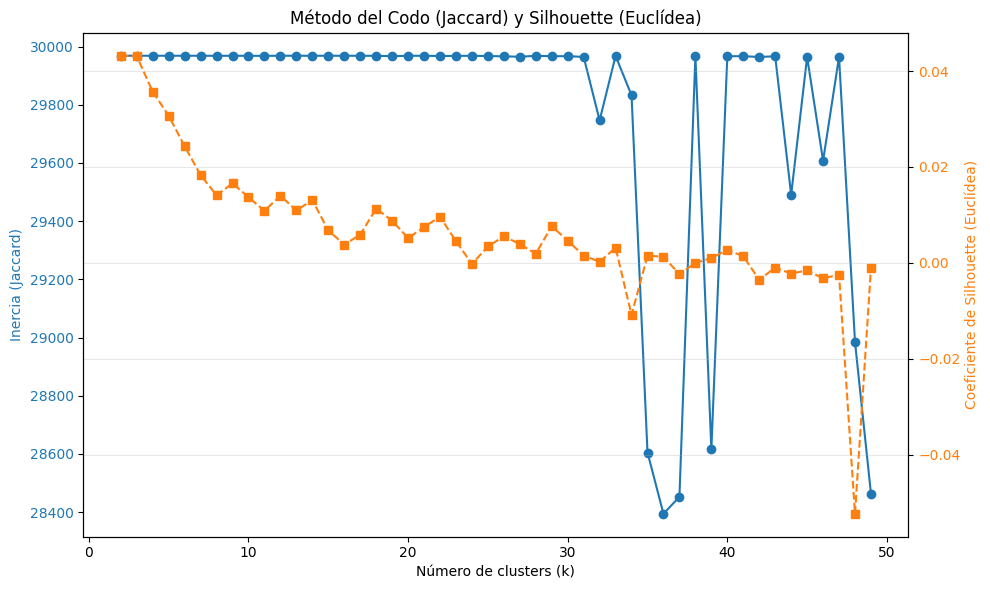

In [7]:
# =============================================================================
# Determinación del número óptimo de clusters (K-Means) con métrica Jaccard
# (Silhouette optimizado usando Euclídea)
# =============================================================================

# --- Datos de entrada ---
X = df_ingredientes_onehot.values

# --- Rango de k a evaluar ---
n_clusters = range(2, 50)

# --- Listas para guardar métricas ---
inertias = []
silhouette_scores = []
min_cluster_sizes = []
max_cluster_sizes = []
mean_cluster_sizes = []

# --- Evaluación de KMeans para cada k ---
for k in n_clusters:
    print(f"Evaluando K={k}...", end='\r')

    # Modelo KMeans
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300,
        init='k-means++'
    )

    labels = kmeans.fit_predict(X)

    # -------------------------------
    # Inercia usando distancia Jaccard
    # -------------------------------
    centers = kmeans.cluster_centers_
    distances = cdist(X, centers, metric='jaccard')
    inertia_jaccard = np.sum(np.min(distances, axis=1))
    inertias.append(inertia_jaccard)

    # -----------------------------------------
    # Silhouette optimizado (distancia euclídea)
    # -----------------------------------------
    silhouette = silhouette_score(X, labels, metric='euclidean')
    silhouette_scores.append(silhouette)

    # -----------------------------------------
    # Tamaño de clusters
    # -----------------------------------------
    cluster_sizes = np.bincount(labels)
    min_cluster_sizes.append(cluster_sizes.min())
    max_cluster_sizes.append(cluster_sizes.max())
    mean_cluster_sizes.append(cluster_sizes.mean())

print("Evaluación completada.                     ")

# --- Crear DataFrame con todas las métricas ---
df_metricas = pd.DataFrame({
    'k': list(n_clusters),
    'inertia_jaccard': inertias,
    'silhouette': silhouette_scores,
    'min_cluster_size': min_cluster_sizes,
    'max_cluster_size': max_cluster_sizes,
    'mean_cluster_size': mean_cluster_sizes
})

print(df_metricas)

# =============================================================================
# Visualización conjunta Inercia (Jaccard) y Silhouette (Euclídea)
# =============================================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Curva del método del codo
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (Jaccard)', color='tab:blue')
ax1.plot(df_metricas['k'], df_metricas['inertia_jaccard'], 'o-', color='tab:blue', label='Inercia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Segundo eje para Silhouette
ax2 = ax1.twinx()
ax2.set_ylabel('Coeficiente de Silhouette (Euclídea)', color='tab:orange')
ax2.plot(df_metricas['k'], df_metricas['silhouette'], 's--', color='tab:orange', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Método del Codo (Jaccard) y Silhouette (Euclídea)')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


## Prueba con DBSCAN con distancia Jaccard

In [15]:

# ======================================================================
# EXPLORACIÓN DE PARÁMETROS DBSCAN
# ======================================================================
# Datos de entrada
X = df_ingredientes_onehot.values

# Listas de parámetros a explorar
eps_list = [0.2, 0.3, 0.4, 0.5]
min_samples_list = [3, 5, 10]
metric = "jaccard"

resultados = []

total = len(eps_list) * len(min_samples_list)
counter = 0

for eps in eps_list:
    for min_samples in min_samples_list:
        counter += 1
        print(f"\n[{counter}/{total}] Probando eps={eps}, min_samples={min_samples}...")
        # ==============================================================
        # ENTRENAMIENTO DE DBSCAN
        # ==============================================================
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric=metric,
            n_jobs=-1
        )
        labels = db.fit_predict(X)

        # ==============================================================
        # MÉTRICAS
        # ==============================================================
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        # Silhouette solo si tiene sentido
        if n_clusters >= 2 and n_noise < len(labels):
            X_no_noise = X[labels != -1]
            labels_no_noise = labels[labels != -1]
            silhouette = silhouette_score(
                X_no_noise, labels_no_noise, metric=metric
            )
        else:
            silhouette = np.nan

        # Guardar resultados
        resultados.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "ruido": n_noise,
            "ruido_%": 100 * n_noise / len(labels),
            "silhouette": silhouette
        })

        # ==============================================================
        # SALIDA RESUMIDA PARA ESTE PARÁMETRO
        # ==============================================================
        print("-"*80)
        print(f"eps              = {eps}")
        print(f"min_samples      = {min_samples}")
        print(f"Nº de clusters   = {n_clusters}")
        print(f"Puntos de ruido  = {n_noise} ({100*n_noise/len(labels):.2f}%)")
        print(f"Silhouette Score = {silhouette:.4f}")
        print("-"*80)

# Convertir a tabla final
df_resultados = pd.DataFrame(resultados)

print("\n" + "="*80)
print("RESUMEN FINAL DE TODAS LAS COMBINACIONES")
print("="*80)
print(df_resultados.to_string(index=False))


[1/12] Probando eps=0.2, min_samples=3...
--------------------------------------------------------------------------------
eps              = 0.2
min_samples      = 3
Nº de clusters   = 31
Puntos de ruido  = 29839 (99.46%)
Silhouette Score = 0.4028
--------------------------------------------------------------------------------

[2/12] Probando eps=0.2, min_samples=5...
--------------------------------------------------------------------------------
eps              = 0.2
min_samples      = 5
Nº de clusters   = 5
Puntos de ruido  = 29935 (99.78%)
Silhouette Score = 0.3932
--------------------------------------------------------------------------------

[3/12] Probando eps=0.2, min_samples=10...
--------------------------------------------------------------------------------
eps              = 0.2
min_samples      = 10
Nº de clusters   = 1
Puntos de ruido  = 29982 (99.94%)
Silhouette Score = nan
--------------------------------------------------------------------------------

[4/12] Pr